# C1 — ConvNeXt V2-T Reader-Aligned EDL/HAAL

In [2]:
# Colab environment
import os, sys, math, json, time, random, hashlib, gc, warnings, copy, contextlib
from pathlib import Path
from datetime import datetime

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
except Exception:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
import timm
import yaml

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    f1_score, confusion_matrix, roc_auc_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
from scipy.stats import spearmanr

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("timm:", timm.__version__)


Python: 3.13.15
PyTorch: 2.11.0+cu130
timm: 1.0.30


In [3]:
EXPERIMENT_ID = "C1_ConvNeXtV2T_ReaderAligned_EDL"

CONFIG = {
    "drive_root": "/content/drive/MyDrive/Thesis_Work/LIDC_Thesis",
    "metadata_file": "LIDC/processed/metadata/detailed_nodule_metadata.csv",
    "fold_assignments_file": "LIDC/processed/metadata/fold_assignments.csv",
    "fold_hash_file": "LIDC/processed/metadata/fold_assignments.sha256",
    "dataset_summary_file": "LIDC/processed/metadata/dataset_summary.json",
    "preprocessing_config_file": "LIDC/preprocessing/configs/preprocessing_config.yaml",
    "images_npy": "LIDC/processed/arrays/images.npy",

    "num_classes": 3,
    "image_size": 224,
    "n_folds": 5,
    "seed": 42,
    "val_fraction": 0.10,
    "pilot_max_patients": None,  # MUST match preprocessing summary

    "batch_size": 32,
    "num_workers": 2,
    "epochs": 50,
    "early_stop_patience": 10,
    "lr_init": 1e-4,
    "lr_min": 1e-6,
    "weight_decay": 0.01,
    "pretrained": True,
    "convnext_model_name": "convnextv2_tiny.fcmae_ft_in1k",

    # C1 corrected disagreement search
    "lambda_grid": [0.1, 0.5, 1.0, 5.0],
    "warmup_grid": [0, 5, 10],
    "prior_c": 1.0,

    # T5b: C-consistent evidence-strength control for soft reader targets.
    "evidence_reg_max": 0.01,  # T5b: non-zero C-consistent KL; verifier-style S-growth guard below
    "evidence_reg_warmup": 10,
    "tuning_fold": 1,  # stored folds are 1..5
    "run_hyperparameter_search": True,
    "ablation_epochs": 50,
    "ablation_patience": 10,

    # lambda=0 is a separate ablation
    "run_lambda_zero_ablation": True,

    # Main corrected objective. Legacy scalar V-HAAL is available only as ablation.
    "objective_mode": "reader_distribution",
    "run_legacy_v_haal_ablation": True,

    "ece_bins": 15,
    "rejection_report_coverages": np.linspace(0.10, 1.00, 10).tolist(),  # reporting grid only; AUC uses every sample (B1/B3)
    "epsilon": 1e-8,
    "xai_enabled": True,
    "xai_fold": 1,
    "xai_max_cases": 200,          # None = all test nodules of xai_fold
    "xai_steps": 20,
    "xai_random_offset_px": 40,    # A4: random nodule offset for Pointing Game
    "masks_npy": None,             # optional bool (N,224,224) aligned with array_index, from preprocessing

    # Ablations / verification
    "run_hard_label_edl_ablation": True,
    "run_verification_suite": True,       # V2,V3,V4,V9 before the search; V5/V6 afterwards
    "verification_halt_on_fail": True,
    "verification_localisation_gate": True,   # True = also require Grad-CAM peak on the disk (needs a finer feature map)
    "m3_allow_missing_b4": False,
    "verification_epochs": 15,
    "verification_overfit_epochs": 100,
    "verification_max_train": 256,
    "planted_radii": [4, 8, 12],
    "planted_per_fold": 120,

    # M3 / A3
    "b4_fold_metrics_file": "experiments/B4_ConvNeXtV2T_Vanilla_EDL_KL/metrics/classification/fold_metrics.csv",
    "b4_predictions_glob": "experiments/B4_ConvNeXtV2T_Vanilla_EDL_KL/predictions/*_predictions.csv",
    "m3_min_brier_margin": 0.0,    # PRE-REGISTER before the full run (A3)
    "bootstrap_n": 2000,
}

MYDRIVE=Path("/content/drive/MyDrive")
ROOT_CANDIDATES=[MYDRIVE/"Thesis_Work/LIDC_Thesis", MYDRIVE/"LIDC_Thesis"]
ROOT=next((p for p in ROOT_CANDIDATES if (p/CONFIG["metadata_file"]).exists()),ROOT_CANDIDATES[0])
CONFIG["drive_root"]=str(ROOT)
EXP_ROOT = ROOT / "experiments" / EXPERIMENT_ID
DIRS = {
    "configs": EXP_ROOT/"configs",
    "splits": EXP_ROOT/"splits",
    "checkpoints": EXP_ROOT/"checkpoints",
    "predictions": EXP_ROOT/"predictions",
    "metrics": EXP_ROOT/"metrics",
    "metrics_haal": EXP_ROOT/"metrics"/"haal",
    "metrics_xai": EXP_ROOT/"metrics"/"xai",
    "plots": EXP_ROOT/"plots",
    "logs": EXP_ROOT/"logs",
    "reports": EXP_ROOT/"reports",
}
for d in DIRS.values(): d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIG["device"] = str(DEVICE)

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try: torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception: pass
set_seed(CONFIG["seed"])
print("Device:", DEVICE)


Device: cuda


## 1. Load and verify the authoritative preprocessing contract

In [4]:
def ap(rel): return ROOT / rel

required = [
    CONFIG["metadata_file"], CONFIG["fold_assignments_file"], CONFIG["fold_hash_file"],
    CONFIG["dataset_summary_file"], CONFIG["preprocessing_config_file"], CONFIG["images_npy"]
]
missing=[str(ap(x)) for x in required if not ap(x).exists()]
if missing:
    raise FileNotFoundError(
        "Corrected preprocessing artifacts are required before C1 can run:\n" + "\n".join(missing)
    )

meta = pd.read_csv(ap(CONFIG["metadata_file"]))
folds = pd.read_csv(ap(CONFIG["fold_assignments_file"]))
images = np.load(ap(CONFIG["images_npy"]), mmap_mode="r", allow_pickle=False)

with open(ap(CONFIG["dataset_summary_file"])) as f: dataset_summary=json.load(f)
with open(ap(CONFIG["preprocessing_config_file"])) as f: preproc=yaml.safe_load(f)

# B1: verify the exact fold file hash.
actual_hash = hashlib.sha256(ap(CONFIG["fold_assignments_file"]).read_bytes()).hexdigest()
expected_hash = ap(CONFIG["fold_hash_file"]).read_text().strip().split()[0]
assert actual_hash == expected_hash, "fold_assignments.csv hash mismatch"

# Merge preprocessing folds as the sole authority.
# Correct contract: fold_assignments.csv contains ONE ROW PER PATIENT.
for c in ["patient_id","fold"]:
    if c not in folds.columns:
        raise RuntimeError(
            f"fold_assignments.csv missing required column {c!r}; available={list(folds.columns)}"
        )
if folds["patient_id"].duplicated().any():
    raise RuntimeError("fold_assignments.csv must contain exactly one row per patient")

folds["patient_id"]=folds["patient_id"].astype(str)
meta["patient_id"]=meta["patient_id"].astype(str)

# Verify any metadata fold before replacing it with the authoritative patient fold.
if "fold" in meta.columns:
    chk=meta[["patient_id","fold"]].merge(
        folds[["patient_id","fold"]],on="patient_id",how="left",validate="many_to_one",
        suffixes=("_metadata","_authoritative")
    )
    if chk["fold_authoritative"].isna().any():
        raise RuntimeError("Some metadata patients are absent from fold_assignments.csv")
    bad=chk["fold_metadata"].astype(int)!=chk["fold_authoritative"].astype(int)
    if bad.any():
        raise RuntimeError(
            f"Metadata fold disagrees with authoritative fold file for {int(bad.sum())} nodule rows"
        )
    meta=meta.drop(columns=["fold"])

meta=meta.merge(folds[["patient_id","fold"]],on="patient_id",how="left",validate="many_to_one")
if meta["fold"].isna().any():
    missing_patients=meta.loc[meta["fold"].isna(),"patient_id"].unique()[:10]
    raise RuntimeError(f"Patients missing from fold_assignments.csv: {missing_patients.tolist()}")
meta["fold"]=meta["fold"].astype(int)
assert sorted(meta["fold"].unique().tolist()) == [1,2,3,4,5]
assert (meta.groupby("patient_id")["fold"].nunique()==1).all()

# Preprocessing is the single source of truth for full mode.
preproc_pilot=dataset_summary.get("pilot_max_patients",dataset_summary.get("PILOT_MAX_PATIENTS",None))
CONFIG["pilot_max_patients"]=preproc_pilot
IS_PILOT=preproc_pilot is not None
if IS_PILOT and CONFIG["run_hyperparameter_search"]:
    raise RuntimeError("Review: do not use pilot data for hyperparameter selection.")

assert len(meta)==len(images), f"metadata/images length mismatch: {len(meta)} vs {len(images)}"
meta=meta.reset_index(drop=True)
if "array_index" not in meta.columns:
    raise ValueError("Corrected preprocessing metadata must contain explicit array_index; C1 will not invent it.")
meta["array_index"]=meta["array_index"].astype(int)
assert meta["array_index"].is_unique, "array_index must be one-to-one"
assert meta["array_index"].min()==0 and meta["array_index"].max()==len(images)-1
assert np.array_equal(np.sort(meta["array_index"].to_numpy()),np.arange(len(images))), "array_index must cover images.npy exactly once"
assert tuple(images.shape[1:])==(224,224), f"Unexpected images.npy shape: {images.shape}"
assert np.isfinite(np.asarray(images[0])).all(), "images.npy contains non-finite values in first integrity probe"

# Cross-check consolidated images against per-patch authoritative files for deterministic probes.
probe_ix=sorted(set([0,len(meta)//2,len(meta)-1]))
for j in probe_ix:
    r=meta.iloc[j]; ai=int(r.array_index)
    if "patch_path" in meta.columns:
        pp=Path(str(r.patch_path))
        if not pp.exists(): raise FileNotFoundError(f"Missing authoritative patch_path: {pp}")
        disk=np.load(pp,allow_pickle=False)
        if disk.shape!=(224,224) or not np.allclose(np.asarray(images[ai]),disk,rtol=0,atol=1e-6):
            raise RuntimeError(f"images.npy row {ai} disagrees with patch_path for nodule {r.nodule_id}")

required_cols=["nodule_id","patient_id","label_id","malignancy_scores","variance_normalized","alignment_mask","fold"]
missing_cols=[c for c in required_cols if c not in meta.columns]
if missing_cols: raise ValueError(f"Metadata missing required columns: {missing_cols}")

_probe=np.asarray(images[:min(256,len(images))],dtype=np.float32)
IMAGE_RANGE=(float(_probe.min()),float(_probe.max()))
if IMAGE_RANGE[0]<-1e-3 or IMAGE_RANGE[1]>1.0+1e-3:
    warnings.warn(f"images.npy range {IMAGE_RANGE} is outside [0,1]; ImageNet normalisation in the Dataset assumes [0,1].")

print("Fold hash:", actual_hash)
print("Image range probe:", IMAGE_RANGE)
print("Pilot:", IS_PILOT)
print("N nodules:", len(meta), "patients:", meta.patient_id.nunique())


Fold hash: 6579bbae4001911dbeb74213340e7846c3dcc2d03f915ed501c0ec339446a060
Image range probe: (0.0, 1.0)
Pilot: False
N nodules: 48 patients: 21


## 2. Build the corrected reader-vote disagreement target

In [5]:
def parse_reader_scores(value):
    if pd.isna(value): return []
    if isinstance(value, (list,tuple,np.ndarray)): xs=value
    else:
        # Preserve the preprocessing contract, but tolerate common CSV/list formatting.
        s=str(value).strip()
        s=s.strip("[]()")
        s=s.replace(",", "|").replace(";", "|")
        xs=[x.strip().strip("'\"") for x in s.split("|") if x.strip()]
    out=[]
    for x in xs:
        v=float(x)
        if not (1 <= v <= 5): raise ValueError(f"Invalid malignancy score {v}")
        out.append(v)
    return out

def score_to_class(score):
    # K=3 reader-level mapping: 1-2 benign, 3 indeterminate, 4-5 malignant.
    if score <= 2: return 0
    if score == 3: return 1
    return 2

def vote_distribution(scores, K=3):
    if len(scores)==0: raise ValueError("No reader scores")
    counts=np.bincount([score_to_class(x) for x in scores], minlength=K).astype(np.float64)
    return counts/counts.sum()

def normalized_reader_entropy_from_q(q, eps=1e-8):
    # H(q)/ln(K), exactly matching the K=3 reader-distribution objective.
    q=np.asarray(q,dtype=np.float64)
    if q.ndim==1: q=q[None,:]
    if q.shape[1] != CONFIG["num_classes"]:
        raise ValueError(f"Expected q with {CONFIG['num_classes']} classes, got {q.shape}")
    if not np.isfinite(q).all():
        raise ValueError("Reader-vote distribution q contains NaN/Inf")
    if not np.allclose(q.sum(1),1.0,atol=1e-6):
        raise ValueError("Reader-vote distribution q does not sum to 1")
    h=-(q*np.log(q+eps)).sum(1)/math.log(CONFIG["num_classes"])
    return h.astype(np.float32)

qs=[]
for s in meta["malignancy_scores"]:
    qs.append(vote_distribution(parse_reader_scores(s), CONFIG["num_classes"]))

q_arr=np.asarray(qs,dtype=np.float32)
meta[["q_benign","q_indeterminate","q_malignant"]]=q_arr
meta["reader_vote_entropy_normalized"]=normalized_reader_entropy_from_q(q_arr, CONFIG["epsilon"])

assert np.allclose(q_arr.sum(1),1.0)
assert np.isfinite(q_arr).all()
assert np.isfinite(meta["reader_vote_entropy_normalized"].to_numpy()).all()

# Diagnostic only: do NOT alter targets/configuration to manufacture a correlation.
_hq = meta["reader_vote_entropy_normalized"].to_numpy(dtype=float)
print("Reader entropy diagnostic:",
      {"n":len(_hq),
       "n_finite":int(np.isfinite(_hq).sum()),
       "n_unique":int(np.unique(_hq[np.isfinite(_hq)]).size),
       "std":float(np.std(_hq[np.isfinite(_hq)])),
       "min":float(np.min(_hq[np.isfinite(_hq)])),
       "max":float(np.max(_hq[np.isfinite(_hq)])),
       "nonzero_fraction":float(np.mean(_hq>0))})

if np.unique(_hq[np.isfinite(_hq)]).size < 2:
    warnings.warn(
        "reader_vote_entropy_normalized is constant. Spearman(H_al,H(q)) is mathematically "
        "undefined and must remain NaN. Check whether malignancy_scores preserves all reader "
        "ratings rather than a single/consensus score."
    )

meta.to_csv(DIRS["configs"]/"c1_metadata_with_reader_targets.csv",index=False)
print(meta[["malignancy_scores","label_id","q_benign","q_indeterminate","q_malignant",
            "variance_normalized","reader_vote_entropy_normalized"]].head(10).to_string(index=False))


Reader entropy diagnostic: {'n': 48, 'n_finite': 48, 'n_unique': 5, 'std': 0.2849778293195241, 'min': -9.102391729243209e-09, 'max': 0.9463946223258972, 'nonzero_fraction': 0.8541666666666666}
malignancy_scores  label_id  q_benign  q_indeterminate  q_malignant  variance_normalized  reader_vote_entropy_normalized
          5|5|5|4         2  0.000000         0.000000         1.00             0.046875                   -9.102392e-09
          5|5|3|4         2  0.000000         0.250000         0.75             0.171875                    5.118595e-01
          4|4|3|2         1  0.250000         0.250000         0.50             0.171875                    9.463946e-01
          4|5|3|2         1  0.250000         0.250000         0.50             0.312500                    9.463946e-01
          2|1|1|1         0  1.000000         0.000000         0.00             0.046875                   -9.102392e-09
          3|3|3|2         1  0.250000         0.750000         0.00             0

## 3. Shared patient-level folds and deterministic validation split

In [6]:
def stratified_group_validation(trainval_df, val_fraction, seed):
    # Search deterministic SGKF candidates and choose the split closest to requested validation fraction.
    n_splits=max(2, int(round(1.0/val_fraction)))
    sgkf=StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    candidates=[]
    X=np.zeros(len(trainval_df))
    y=trainval_df["label_id"].to_numpy()
    g=trainval_df["patient_id"].astype(str).to_numpy()
    for _,vi in sgkf.split(X,y,g):
        frac=len(vi)/len(trainval_df)
        candidates.append((abs(frac-val_fraction),vi))
    vi=min(candidates,key=lambda x:x[0])[1]
    mask=np.ones(len(trainval_df),dtype=bool); mask[vi]=False
    return trainval_df.iloc[np.where(mask)[0]].copy(), trainval_df.iloc[vi].copy()

def fold_frames(test_fold):
    test=meta[meta.fold.astype(int)==test_fold].copy()
    trainval=meta[meta.fold.astype(int)!=test_fold].copy()
    train,val=stratified_group_validation(trainval, CONFIG["val_fraction"], CONFIG["seed"]+test_fold)
    A,B,C=set(train.patient_id),set(val.patient_id),set(test.patient_id)
    assert A.isdisjoint(B) and A.isdisjoint(C) and B.isdisjoint(C)
    return {"train":train,"validation":val,"test":test}

FOLDS={f:fold_frames(f) for f in range(1,6)}
pd.DataFrame([{
    "fold":f,"n_train":len(x["train"]),"n_validation":len(x["validation"]),"n_test":len(x["test"]),
    "train_patients":x["train"].patient_id.nunique(),
    "validation_patients":x["validation"].patient_id.nunique(),
    "test_patients":x["test"].patient_id.nunique()
} for f,x in FOLDS.items()]).to_csv(DIRS["splits"]/"all_folds_summary.csv",index=False)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(


## 4. Shared augmentation and dataset

In [7]:
IMAGENET_MEAN=torch.tensor([0.485,0.456,0.406],dtype=torch.float32).view(3,1,1)
IMAGENET_STD=torch.tensor([0.229,0.224,0.225],dtype=torch.float32).view(3,1,1)

class LIDCC1Dataset(Dataset):
    def __init__(self, df, augment=False):
        self.df=df.reset_index(drop=True)
        self.images=np.load(ap(CONFIG["images_npy"]),mmap_mode="r",allow_pickle=False)
        self.aug=v2.Compose([
            v2.RandomHorizontalFlip(p=.5),
            v2.RandomVerticalFlip(p=.5),
            v2.RandomRotation(15),
            v2.RandomAffine(degrees=0,translate=(.10,.10)),
        ]) if augment else None
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]; ai=int(r.array_index)
        gray=torch.from_numpy(np.asarray(self.images[ai],dtype=np.float32).copy()).unsqueeze(0)
        x=gray.repeat(3,1,1)
        if self.aug is not None: x=self.aug(x)
        x=(x-IMAGENET_MEAN)/IMAGENET_STD
        q=torch.tensor([r.q_benign,r.q_indeterminate,r.q_malignant],dtype=torch.float32)
        return (x, int(r.label_id), q, float(r.variance_normalized),
                float(r.reader_vote_entropy_normalized), float(r.alignment_mask), ai)

def loader(df,train=False,augment=None):
    augment=train if augment is None else augment
    return DataLoader(LIDCC1Dataset(df,augment=augment),
        batch_size=min(CONFIG["batch_size"],max(1,len(df))), shuffle=train,
        num_workers=CONFIG["num_workers"], pin_memory=torch.cuda.is_available(),
        drop_last=(train and len(df)>CONFIG["batch_size"]))

## 5. ConvNeXt V2-T evidential model and corrected C1 loss

In [8]:
class C1Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone=timm.create_model(CONFIG["convnext_model_name"],pretrained=CONFIG["pretrained"],num_classes=0)
        self.head=nn.Linear(self.backbone.num_features,CONFIG["num_classes"])
    def forward(self,x): return self.head(self.backbone(x))

def edl(logits,C=1.0,eps=1e-8):
    evidence=F.softplus(logits)
    alpha=evidence+float(C)
    S=alpha.sum(1,keepdim=True)
    p=alpha/S
    u=CONFIG["num_classes"]*float(C)/S.squeeze(1)
    H=-(p*torch.log(p+eps)).sum(1)/math.log(CONFIG["num_classes"])
    return evidence,alpha,S,p,u,H

def expected_dirichlet_ce(alpha,S,target):
    # Works for one-hot or soft reader-distribution q targets.
    return (target*(torch.digamma(S)-torch.digamma(alpha))).sum(1)

def kl_q_to_p(q,p,eps=1e-8):
    return (q*(torch.log(q+eps)-torch.log(p+eps))).sum(1)

def dirichlet_kl(alpha,beta):
    """KL[Dir(alpha) || Dir(beta)], returned per sample."""
    Sa=alpha.sum(dim=1,keepdim=True)
    Sb=beta.sum(dim=1,keepdim=True)
    log_B_a=torch.lgamma(alpha).sum(dim=1)-torch.lgamma(Sa).squeeze(1)
    log_B_b=torch.lgamma(beta).sum(dim=1)-torch.lgamma(Sb).squeeze(1)
    return (log_B_b-log_B_a + ((alpha-beta)*(torch.digamma(alpha)-torch.digamma(Sa))).sum(dim=1))

def soft_target_c_consistent_kl(alpha,target,C):
    """C-consistent evidence regularizer for a one-hot OR soft target.

        alpha_tilde = target*C + (1-target)*alpha ;  beta = [C,...,C]

    One-hot target -> exactly the B3/Sensoy adjusted Dirichlet, but KL to Dir(C) (fixes B5).
    Fractional target -> fractional protection of that class's evidence.
    """
    C=float(C)
    alpha_tilde=target*C + (1.0-target)*alpha
    beta=torch.full_like(alpha_tilde,C)
    return dirichlet_kl(alpha_tilde,beta)

OBJECTIVE_MODES=("reader_distribution","reader_entropy","legacy_v_haal","hard_label_edl")

def c1_loss(logits,q,V,Hq,mask,epoch,lambda_max,t_warmup,mode="reader_distribution",y_onehot=None):
    """
    reader_distribution : soft-q expected CE + lambda*KL(q||p) + reg*KL_evidence   (MAIN C1)
    reader_entropy      : soft-q expected CE + lambda*(H_al - H(q)/ln3)^2 + reg*KL_evidence   (ablation)
    legacy_v_haal       : ORIGINAL HAAL = one-hot expected CE + lambda*mask*(H_al - V)^2, no KL   (baseline)
    hard_label_edl      : one-hot expected CE + reg*KL_evidence, no alignment (B4-style loss isolation)
    """
    if mode not in OBJECTIVE_MODES: raise ValueError(mode)
    _,alpha,S,p,u,Hp=edl(logits,CONFIG["prior_c"],CONFIG["epsilon"])
    hard_target = mode in ("legacy_v_haal","hard_label_edl")
    if hard_target:
        if y_onehot is None: raise ValueError(f"mode={mode!r} requires y_onehot")
        target=y_onehot
    else:
        target=q
    L_cls=expected_dirichlet_ce(alpha,S,target).mean()
    lam=float(lambda_max) if int(t_warmup)==0 else float(lambda_max)*min(1.0,epoch/float(t_warmup))

    if mode=="reader_distribution":
        L_align=kl_q_to_p(q,p,CONFIG["epsilon"]).mean()
    elif mode=="reader_entropy":
        L_align=((Hp-Hq)**2).mean()
    elif mode=="legacy_v_haal":
        L_align=(mask*(Hp-V)**2).sum()/(mask.sum()+CONFIG["epsilon"])
    else:  # hard_label_edl
        L_align=torch.zeros((),dtype=L_cls.dtype,device=L_cls.device); lam=0.0

    # Evidence-strength control (annealed). The ORIGINAL HAAL had no KL term -> weight 0 in legacy mode.
    reg_max=float(CONFIG.get("evidence_reg_max",0.01))
    if mode=="legacy_v_haal": reg_max=0.0
    reg_warm=int(CONFIG.get("evidence_reg_warmup",10))
    reg_t=reg_max if reg_warm==0 else reg_max*min(1.0,epoch/float(reg_warm))
    L_evidence=soft_target_c_consistent_kl(alpha,target,CONFIG["prior_c"]).mean()

    total=L_cls + lam*L_align + reg_t*L_evidence
    return total, {
        "classification":float(L_cls.detach()),
        "alignment":float(L_align.detach()),
        "evidence_kl":float(L_evidence.detach()),
        "lambda_t":lam,
        "evidence_reg_t":reg_t,
        "mean_strength":float(S.detach().mean()),
        "mean_vacuity":float(u.detach().mean()),
        "tv_q_p":float((0.5*(p.detach()-q).abs().sum(1)).mean()),
    }


## 6. Metrics — identical definitions for C1/B4 comparisons

In [9]:
_trapz = getattr(np, "trapezoid", None) or getattr(np, "trapz")

def ece_score(probs,y,n_bins=15):
    probs=np.asarray(probs); y=np.asarray(y,dtype=int)
    conf=probs.max(1); pred=probs.argmax(1); ok=(pred==y).astype(float)
    edges=np.linspace(0,1,n_bins+1); ece=0.; rows=[]
    for b in range(n_bins):
        lo,hi=edges[b:b+2]
        m=(conf>=lo)&(conf<=hi) if b==0 else (conf>lo)&(conf<=hi)
        if not m.any():
            rows.append({"bin":b,"n":0,"accuracy":np.nan,"confidence":np.nan}); continue
        a=ok[m].mean(); c=conf[m].mean(); ece += m.mean()*abs(a-c)
        rows.append({"bin":b,"n":int(m.sum()),"accuracy":float(a),"confidence":float(c)})
    return float(ece),pd.DataFrame(rows)

def safe_macro_auroc(y_true, probs):
    """T7-safe macro OvR AUROC shared by B1, B3, and C1."""
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(probs, dtype=float)
    yb = label_binarize(y, classes=[0, 1, 2])

    aucs = []
    for k in range(3):
        # AUROC is undefined if this one-vs-rest target has only one value.
        if len(np.unique(yb[:, k])) < 2:
            continue
        aucs.append(float(roc_auc_score(yb[:, k], p[:, k])))

    return float(np.mean(aucs)) if aucs else np.nan

def metrics(y,probs):
    y=np.asarray(y,dtype=int); probs=np.asarray(probs)
    pred=probs.argmax(1); yoh=np.eye(3)[y]
    ece,_=ece_score(probs,y,CONFIG["ece_bins"])
    return {
        "accuracy":float(accuracy_score(y,pred)),
        "f1_macro":float(f1_score(y,pred,average="macro",labels=[0,1,2],zero_division=0)),
        "brier_score":float(np.mean(np.sum((probs-yoh)**2,axis=1))),
        "nll":float(-np.mean(np.log(np.clip(probs[np.arange(len(y)),y],CONFIG["epsilon"],1.0)))),
        "ece_15":ece,
        "auroc_macro_ovr":safe_macro_auroc(y,probs),
    }

def tv_distance(p,q):
    """Per-sample total-variation distance between predicted p_hat and reader-vote q."""
    return 0.5*np.abs(np.asarray(p)-np.asarray(q)).sum(1)

# ---- Rejection curve: SAME definition as B1/B3 (B4): retain the r lowest-u samples for EVERY r=1..n ----
def rejection_curve(y,probs,u):
    y=np.asarray(y,dtype=int); probs=np.asarray(probs); u=np.asarray(u)
    n=len(y); order=np.argsort(u)                      # identical call to B1/B3
    correct=(probs.argmax(1)==y)[order].astype(np.float64)
    r=np.arange(1,n+1)
    return pd.DataFrame({"coverage":r/n,"n_retained":r,"accuracy":np.cumsum(correct)/r})

def rejection_auc(curve_df):
    d=curve_df.sort_values("coverage")
    return float(_trapz(d["accuracy"].to_numpy(),d["coverage"].to_numpy()))

def rejection_f1_table(y,probs,u,coverages):
    """Reporting table only (macro-F1 at a coarse coverage grid). NOT used for the AUC."""
    y=np.asarray(y,dtype=int); probs=np.asarray(probs); order=np.argsort(np.asarray(u)); rows=[]
    for cov in coverages:
        n=max(1,min(len(y),int(math.ceil(float(cov)*len(y))))); ix=order[:n]; pred=probs[ix].argmax(1)
        rows.append({"coverage":float(cov),"n_retained":int(n),
                     "accuracy":float(accuracy_score(y[ix],pred)),
                     "f1_macro":float(f1_score(y[ix],pred,average="macro",labels=[0,1,2],zero_division=0))})
    return pd.DataFrame(rows)


## 7. Training and evaluation

In [10]:
def predict(model,dl):
    """
    Returns model outputs plus the EXACT H(q) supplied by the Dataset.
    Carrying Hq through predict avoids a fragile post-hoc metadata merge for the
    Spearman(H_al, H(q)) calculation.
    """
    model.eval(); P=[];Y=[];U=[];H=[];AI=[];Q=[];V=[];SS=[];HQ=[]
    with torch.no_grad():
        for x,y,q,v,hq,m,ai in dl:
            _,_,S,p,u,h=edl(model(x.to(DEVICE)),CONFIG["prior_c"],CONFIG["epsilon"])
            P.append(p.cpu().numpy());Y.append(y.numpy());U.append(u.cpu().numpy());H.append(h.cpu().numpy())
            AI.append(ai.numpy());Q.append(q.numpy());V.append(v.numpy());SS.append(S.squeeze(1).cpu().numpy())
            HQ.append(hq.numpy())
    return tuple(np.concatenate(z) for z in [P,Y,U,H,AI,Q,V,SS,HQ])

def train_once(train_df,val_df,lambda_max,t_warmup,run_name,mode=None,epochs=None,patience=None,
               augment=True,early_stop=True):
    """val_df=None -> no validation/checkpointing; the final-epoch model is returned (used by V2)."""
    set_seed(CONFIG["seed"])
    mode=mode or CONFIG["objective_mode"]; epochs=epochs or CONFIG["epochs"]; patience=patience or CONFIG["early_stop_patience"]
    model=C1Model().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=CONFIG["lr_init"],weight_decay=CONFIG["weight_decay"])
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=CONFIG["lr_min"])
    tr=loader(train_df,True,augment=augment); va=loader(val_df,False) if val_df is not None else None
    ck=DIRS["checkpoints"]/run_name; ck.mkdir(parents=True,exist_ok=True); bestp=ck/"best.pt"
    best=np.inf; wait=0; hist=[]
    for epoch in range(1,epochs+1):
        model.train(); sums={"loss":0.,"classification":0.,"alignment":0.,"evidence_kl":0.,"strength":0.,"vacuity":0.,"tv":0.,"correct":0,"n":0}; batches=0
        for x,y,q,V,Hq,mask,ai in tr:
            x=x.to(DEVICE);y=y.to(DEVICE);q=q.to(DEVICE);V=V.to(DEVICE);Hq=Hq.to(DEVICE);mask=mask.to(DEVICE)
            yoh=F.one_hot(y,CONFIG["num_classes"]).float()
            opt.zero_grad(set_to_none=True); logits=model(x)
            loss,st=c1_loss(logits,q,V,Hq,mask,epoch,lambda_max,t_warmup,mode,yoh)
            loss.backward(); opt.step()
            sums["loss"]+=float(loss.detach());sums["classification"]+=st["classification"];sums["alignment"]+=st["alignment"]
            sums["evidence_kl"]+=st["evidence_kl"];sums["strength"]+=st["mean_strength"];sums["vacuity"]+=st["mean_vacuity"]
            sums["tv"]+=st["tv_q_p"]
            sums["correct"]+=int((logits.argmax(1)==y).sum());sums["n"]+=len(y);batches+=1
        sch.step()
        if va is not None:
            vp,vy,*_=predict(model,va); vm=metrics(vy,vp)
        else:
            vm={"brier_score":float("nan"),"f1_macro":float("nan")}
        row={"epoch":epoch,"train_loss":sums["loss"]/batches,
             "train_classification":sums["classification"]/batches,"train_alignment":sums["alignment"]/batches,
             "train_evidence_kl":sums["evidence_kl"]/batches,"train_mean_strength":sums["strength"]/batches,
             "train_mean_vacuity":sums["vacuity"]/batches,"train_tv_q_p":sums["tv"]/batches,
             "evidence_reg_t":st["evidence_reg_t"],
             "train_accuracy":sums["correct"]/sums["n"],"lambda_t":st["lambda_t"],"val_brier":vm["brier_score"],
             "val_f1_macro":vm["f1_macro"],"lr":sch.get_last_lr()[0]}
        hist.append(row)
        if va is not None:
            if vm["brier_score"]<best-1e-8:
                best=vm["brier_score"];wait=0;torch.save(model.state_dict(),bestp)
            else: wait+=1
            if early_stop and wait>=patience: break
    if va is not None:
        model.load_state_dict(torch.load(bestp,map_location=DEVICE))
    else:
        best=float("nan")
    return model,pd.DataFrame(hist),float(best)

def _safe_spearman(a,b,return_reason=False):
    """
    Spearman with pairwise finite filtering and explicit diagnostics.
    IMPORTANT: a constant variable has no defined Spearman correlation; returning 0
    would be statistically incorrect, so such a case remains NaN with a reason.
    """
    a=np.asarray(a,dtype=float).reshape(-1)
    b=np.asarray(b,dtype=float).reshape(-1)

    if a.shape != b.shape:
        raise ValueError(f"Spearman inputs must have same shape, got {a.shape} vs {b.shape}")

    finite=np.isfinite(a) & np.isfinite(b)
    aa=a[finite]; bb=b[finite]

    reason="ok"
    rho=float("nan")
    if len(aa) < 3:
        reason=f"fewer than 3 finite pairs ({len(aa)})"
    elif np.unique(aa).size < 2:
        reason="H_al is constant"
    elif np.unique(bb).size < 2:
        reason="comparison target is constant"
    else:
        res=spearmanr(aa,bb,nan_policy="omit")
        rho=float(res.statistic)
        if not np.isfinite(rho):
            reason="scipy returned non-finite statistic"

    return (rho,reason,int(len(aa)),int(np.unique(aa).size),int(np.unique(bb).size)) if return_reason else rho

def evaluate_fold(model,test_df,fold,tag="C1"):
    dl=loader(test_df,False)
    p,y,u,h,ai,q,V,S,hq=predict(model,dl)
    m=metrics(y,p)

    # Independent consistency check: Hq carried by the loader must equal H(q) recomputed from q.
    hq_from_q=normalized_reader_entropy_from_q(q, CONFIG["epsilon"]).astype(float)
    if not np.allclose(hq, hq_from_q, atol=1e-6, rtol=0, equal_nan=False):
        raise RuntimeError("Dataset H(q) disagrees with entropy recomputed from reader-vote q")

    pred=pd.DataFrame({
        "fold":fold,"array_index":ai,"y_true":y,"y_pred":p.argmax(1),
        "p_benign":p[:,0],"p_indeterminate":p[:,1],"p_malignant":p[:,2],
        "q_benign":q[:,0],"q_indeterminate":q[:,1],"q_malignant":q[:,2],
        "V":V,"u":u,"S":S,"H_al_normalized":h,
        "reader_vote_entropy_normalized":hq
    }).merge(
        meta[["array_index","nodule_id","patient_id","malignancy_scores"]],
        on="array_index",how="left",validate="one_to_one"
    )
    pred.to_csv(DIRS["predictions"]/f"{tag}_fold_{fold}_predictions.csv",index=False)

    rc=rejection_curve(y,p,u)
    rc.to_csv(DIRS["metrics"]/f"{tag}_fold_{fold}_rejection.csv",index=False)
    rejection_f1_table(y,p,u,CONFIG["rejection_report_coverages"]).to_csv(
        DIRS["metrics"]/f"{tag}_fold_{fold}_rejection_f1_grid.csv",index=False)
    rc_msp=rejection_curve(y,p,1.0-p.max(1))

    tv=tv_distance(p,q)
    kl=np.sum(q*(np.log(q+CONFIG["epsilon"])-np.log(p+CONFIG["epsilon"])),axis=1)

    rho_hq,why_hq,n_hq,uniq_h,uniq_hq=_safe_spearman(h,hq,return_reason=True)
    rho_v,why_v,_,_,_=_safe_spearman(h,V,return_reason=True)
    rho_uv,why_uv,_,_,_=_safe_spearman(u,V,return_reason=True)

    audit={
        "tag":tag,"fold":int(fold),"n_test":int(len(y)),
        "H_al_finite":int(np.isfinite(h).sum()),
        "Hq_finite":int(np.isfinite(hq).sum()),
        "H_al_unique":int(np.unique(h[np.isfinite(h)]).size),
        "Hq_unique":int(np.unique(hq[np.isfinite(hq)]).size),
        "H_al_std":float(np.std(h[np.isfinite(h)])),
        "Hq_std":float(np.std(hq[np.isfinite(hq)])),
        "spearman_Hal_Hq":rho_hq,
        "spearman_Hal_Hq_status":why_hq,
    }
    audit_path=DIRS["metrics_haal"]/"spearman_diagnostics.csv"
    audit_df=pd.DataFrame([audit])
    if audit_path.exists():
        old=pd.read_csv(audit_path)
        old=old[~((old["tag"].astype(str)==str(tag)) & (old["fold"].astype(int)==int(fold)))]
        audit_df=pd.concat([old,audit_df],ignore_index=True)
    audit_df.to_csv(audit_path,index=False)

    if not np.isfinite(rho_hq):
        warnings.warn(
            f"{tag} fold {fold}: spearman_Hal_Hq is undefined: {why_hq}. "
            f"finite pairs={n_hq}, unique H_al={uniq_h}, unique Hq={uniq_hq}. "
            "Do not replace an undefined correlation with 0."
        )

    return {"fold":fold,**m,
            "rejection_auc_uncertainty":rejection_auc(rc),
            "rejection_auc_maxprob":rejection_auc(rc_msp),
            "mean_u":float(u.mean()),"mean_S":float(S.mean()),"mean_V":float(V.mean()),
            "spearman_Hal_V":rho_v,
            "spearman_Hal_Hq":rho_hq,
            "spearman_u_V":rho_uv,
            "mean_KL_q_p":float(kl.mean()),"mean_TV_q_p":float(tv.mean())}


## 8. V1 unit tests for the C1 mathematical path

In [11]:
from torch.distributions import Dirichlet, kl_divergence

# Analytic checks.
logits=torch.tensor([[0.2,-0.3,1.1]],dtype=torch.float64)
_,a,S,p,u,h=edl(logits,1.0)
q=torch.tensor([[0.5,0.5,0.0]],dtype=torch.float64)
ce=expected_dirichlet_ce(a,S,q)
manual=(q*(torch.digamma(S)-torch.digamma(a))).sum(1)
assert torch.allclose(ce,manual,atol=1e-12)

kl=kl_q_to_p(q,p)
manual_kl=(q*(torch.log(q+1e-8)-torch.log(p+1e-8))).sum(1)
assert torch.allclose(kl,manual_kl,atol=1e-12)

# dirichlet_kl vs torch.distributions (T2) and C-consistency (T3, B5)
g=torch.Generator().manual_seed(0)
for _ in range(5):
    al=torch.rand(1,3,dtype=torch.float64,generator=g)*4+0.2
    be=torch.rand(1,3,dtype=torch.float64,generator=g)*3+0.2
    assert torch.allclose(dirichlet_kl(al,be)[0],kl_divergence(Dirichlet(al[0]),Dirichlet(be[0])),atol=1e-9)
for Cx in (0.5,1.0,2.0):
    a_x=torch.tensor([[4.0+Cx,0.7+Cx,1.3+Cx]],dtype=torch.float64)
    yx=torch.tensor([[1.0,0.0,0.0]],dtype=torch.float64)
    at=yx*Cx+(1-yx)*a_x
    ref=kl_divergence(Dirichlet(at[0]),Dirichlet(torch.full((3,),Cx,dtype=torch.float64)))
    assert torch.allclose(soft_target_c_consistent_kl(a_x,yx,Cx)[0],ref,atol=1e-9)
a0=torch.ones((1,3),dtype=torch.float64)
assert torch.allclose(soft_target_c_consistent_kl(a0,q,1.0),torch.zeros(1,dtype=torch.float64),atol=1e-12)
assert (soft_target_c_consistent_kl(a,q,1.0)>=-1e-10).all()

# Objective-mode plumbing
V_=torch.tensor([0.1],dtype=torch.float64); Hq_=torch.tensor([0.5],dtype=torch.float64); mk_=torch.ones(1,dtype=torch.float64)
y1=torch.tensor([[0.,1.,0.]],dtype=torch.float64)
_,st=c1_loss(logits,q,V_,Hq_,mk_,5,1.0,10,"reader_distribution",y1);   assert abs(st["lambda_t"]-0.5)<1e-12
_,st=c1_loss(logits,q,V_,Hq_,mk_,5,1.0,10,"legacy_v_haal",y1);         assert st["evidence_reg_t"]==0.0
_,st=c1_loss(logits,q,V_,Hq_,mk_,5,1.0,10,"hard_label_edl",y1);        assert st["lambda_t"]==0.0 and st["alignment"]==0.0
try:
    c1_loss(logits,q,V_,Hq_,mk_,5,1.0,10,"hard_label_edl",None); raise AssertionError("hard mode must require y_onehot")
except ValueError: pass

# T5b REGULARIZED strength check.
# T5b optimisation, but uses the actual C1
# soft-target objective PLUS the C-consistent evidence KL.
# Criterion is the same: S(20k) < 2*S(2k).
_qb = torch.tensor([[0.25, 0.50, 0.25]], dtype=torch.float32)
_t5b_S = []
for _steps in (2_000, 20_000):
    _z = torch.zeros(1, 3, requires_grad=True)
    _opt = torch.optim.Adam([_z], lr=0.2)
    for _ in range(_steps):
        _alpha = F.softplus(_z) + float(CONFIG["prior_c"])
        _S = _alpha.sum(1, keepdim=True)
        _ce = expected_dirichlet_ce(_alpha, _S, _qb).mean()
        _ereg = soft_target_c_consistent_kl(
            _alpha, _qb, CONFIG["prior_c"]
        ).mean()
        _loss = _ce + float(CONFIG["evidence_reg_max"]) * _ereg
        _opt.zero_grad(); _loss.backward(); _opt.step()
    _t5b_S.append(float((F.softplus(_z) + float(CONFIG["prior_c"])).sum().detach()))
assert _t5b_S[1] < 2.0 * _t5b_S[0], (
    f"T5b regularized strength still grows too much: 2k={_t5b_S[0]:.3f}, "
    f"20k={_t5b_S[1]:.3f}"
)
print(f"T5b REGULARIZED strength check: PASS; S(2k)={_t5b_S[0]:.2f}, S(20k)={_t5b_S[1]:.2f}")

# Metric checks against independent references (T6, T7)
# T7-safe canonical helper check: class 0 deliberately absent.
_y7 = np.array([1,1,1,2,2,2], dtype=int)
_p7 = np.array([
    [0.05,0.85,0.10],
    [0.10,0.80,0.10],
    [0.05,0.70,0.25],
    [0.05,0.20,0.75],
    [0.10,0.15,0.75],
    [0.05,0.10,0.85],
], dtype=float)
_yb7 = label_binarize(_y7, classes=[0,1,2])
_ref7 = float(np.mean([
    roc_auc_score(_yb7[:,k], _p7[:,k])
    for k in range(3)
    if len(np.unique(_yb7[:,k])) == 2
]))
assert np.isfinite(safe_macro_auroc(_y7, _p7))
assert abs(safe_macro_auroc(_y7, _p7) - _ref7) < 1e-12


_rng=np.random.RandomState(1); n_=40
y_=_rng.randint(0,3,n_); lg_=_rng.randn(n_,3)+np.eye(3)[y_]
p_=np.exp(lg_)/np.exp(lg_).sum(1,keepdims=True); u_=_rng.rand(n_)
_ord=np.argsort(u_); _pred=p_.argmax(1)
ref_acc=[accuracy_score(y_[_ord[:r]],_pred[_ord[:r]]) for r in range(1,n_+1)]
ref_auc=float(_trapz(ref_acc,np.arange(1,n_+1)/n_))
assert abs(rejection_auc(rejection_curve(y_,p_,u_))-ref_auc)<1e-12, "rejection AUC differs from B1/B3 definition"
y2_=y_.copy(); y2_[y2_==0]=1
yb_=label_binarize(y2_,classes=[0,1,2])
ref_macro=float(np.mean([roc_auc_score(yb_[:,k],p_[:,k]) for k in range(3) if len(np.unique(yb_[:,k]))==2]))
assert abs(safe_macro_auroc(y2_,p_)-ref_macro)<1e-12
assert abs(safe_macro_auroc(y_,p_)-roc_auc_score(y_,p_,multi_class="ovr",average="macro"))<1e-12
assert ece_score(np.eye(3)[y_],y_)[0]==0.0
print("V1 analytic C1 + T5b + T6/T7 + objective-mode tests: PASS")


T5b REGULARIZED strength check: PASS; S(2k)=74.16, S(20k)=105.58
V1 analytic C1 + T5b + T6/T7 + objective-mode tests: PASS


## 14. XAI helpers — corrected target layer and uncertainty faithfulness

In [12]:
def get_xai_target_layer(model):
    return model.backbone.stages[-1]          # B8: block/stage output, not an inner conv

class Hook:
    def __init__(self,layer):
        self.A=None;self.G=None
        self.f=layer.register_forward_hook(lambda m,i,o:setattr(self,"A",o))
        self.b=layer.register_full_backward_hook(lambda m,gi,go:setattr(self,"G",go[0]))
    def close(self): self.f.remove();self.b.remove()

def grad_map(model,x,scalar_kind="vacuity",class_idx=None):
    """gradcam -> class probability (A4; gradient ~0 when p_c saturates); gradcam_logit -> class logit;  vacuity / aleatoric -> ESM targets u / H_al."""
    model.eval(); hk=Hook(get_xai_target_layer(model)); model.zero_grad(set_to_none=True)
    logits=model(x); _,_,_,p,u,h=edl(logits,CONFIG["prior_c"],CONFIG["epsilon"])
    if scalar_kind=="gradcam":
        c=int(p.argmax(1).item()) if class_idx is None else int(class_idx)
        scalar=p[:,c].sum()
    elif scalar_kind=="gradcam_logit":      # standard Grad-CAM (class score); robust when p_c is saturated
        c=int(p.argmax(1).item()) if class_idx is None else int(class_idx)
        scalar=logits[:,c].sum()
    elif scalar_kind=="vacuity": scalar=u.sum()
    elif scalar_kind=="aleatoric": scalar=h.sum()
    else: hk.close(); raise ValueError(scalar_kind)
    scalar.backward()
    A,G=hk.A,hk.G; hk.close()
    if A.ndim!=4: raise RuntimeError(f"Expected NCHW stage output, got {A.shape}")
    w=G.mean((2,3),keepdim=True); M=F.relu((w*A).sum(1,keepdim=True))
    M=F.interpolate(M,size=(224,224),mode="bilinear",align_corners=False).squeeze()
    M=(M-M.min())/(M.max()-M.min()+1e-8)
    return M.detach().cpu().numpy()

def trapezoid_auc(scores,fractions):
    return float(_trapz(np.asarray(scores),np.asarray(fractions)))


## 8b. verification protocol (V2, V3, V4, V9; V5 after the ablations)
Runs on the same code path as the full run. Set `run_verification_suite=False` only after it has passed once.

In [13]:
VERIF={}          # results of the verification protocol (V2-V5, V9)

def _jsonable(o):
    if isinstance(o,dict): return {k:_jsonable(v) for k,v in o.items()}
    if isinstance(o,(list,tuple)): return [_jsonable(v) for v in o]
    if isinstance(o,(np.floating,np.integer)): return o.item()
    if isinstance(o,(np.bool_,)): return bool(o)
    return o

def _subset_train(df,n,seed=0):
    rng=np.random.RandomState(seed); pats=df.patient_id.unique().copy(); rng.shuffle(pats)
    parts=[];c=0
    for pid in pats:
        r=df[df.patient_id==pid]; parts.append(r); c+=len(r)
        if c>=n: break
    return pd.concat(parts).iloc[:n].copy()

@contextlib.contextmanager
def swapped_dataset(meta_new,images_path):
    """Run the REAL fold/loader/train/evaluate path on a different dataset (V3)."""
    global meta, FOLDS
    old=(meta,FOLDS,CONFIG["images_npy"])
    try:
        meta=meta_new; CONFIG["images_npy"]=str(images_path)
        FOLDS={f:fold_frames(f) for f in range(1,6)}
        yield
    finally:
        meta,FOLDS,CONFIG["images_npy"]=old

# ---------------- V2: overfit 32 patches (no augmentation, no early stopping) ----------------
def run_v2_overfit():
    f=FOLDS[1]; sub=_subset_train(f["train"],32); out={"passed":True}
    for mode in ["hard_label_edl","reader_distribution"]:
        m,h,_=train_once(sub,None,1.0,0,f"verify_V2_{mode}",mode=mode,
                         epochs=CONFIG["verification_overfit_epochs"],augment=False,early_stop=False)
        p,y,u,hh,ai,q,V,S,Hq=predict(m,loader(sub,False))
        acc=float((p.argmax(1)==y).mean()); tv=float(tv_distance(p,q).mean())
        grew=bool(h.train_mean_strength.iloc[-1]>h.train_mean_strength.iloc[0])
        ok=(acc==1.0 and grew) if mode=="hard_label_edl" else (tv<0.15 and grew)
        out[mode]={"train_acc_hard":acc,"mean_TV_q_p":tv,"strength_first":float(h.train_mean_strength.iloc[0]),
                   "strength_last":float(h.train_mean_strength.iloc[-1]),"ok":bool(ok)}
        out["passed"]&=bool(ok); del m
    return out

# ---------------- V3: planted-signal test through the real pipeline ----------------
def build_planted(per_fold,radii,seed=0):

    rng=np.random.RandomState(seed); n=5*per_fold
    fold=np.repeat(np.arange(1,6),per_fold)
    lab=np.concatenate([rng.permutation(np.resize(np.arange(3),per_fold)) for _ in range(5)])
    yy,xx=np.mgrid[:224,:224]; rr=np.hypot(yy-112,xx-112)
    imgs=np.empty((n,224,224),np.float32)
    for i,l in enumerate(lab):
        im=0.35+0.05*rng.randn(224,224); im[rr<=radii[l]]+=0.4; imgs[i]=np.clip(im,0,1)
    m=pd.DataFrame({"nodule_id":[f"syn_{i}" for i in range(n)],
                    "patient_id":[f"syn_{fold[i]}_{i//2}" for i in range(n)],
                    "fold":fold,"array_index":np.arange(n),"label_id":lab,
                    "malignancy_scores":"3","variance_normalized":0.0,
                    "reader_vote_entropy_normalized":0.0,"alignment_mask":0.0})
    m[["q_benign","q_indeterminate","q_malignant"]]=np.eye(3,dtype=np.float32)[lab]
    path=DIRS["configs"]/"planted_images.npy"; np.save(path,imgs)
    return m,path

def run_v3_planted():
    m,path=build_planted(CONFIG["planted_per_fold"],CONFIG["planted_radii"])
    with swapped_dataset(m,path):
        f=FOLDS[1]
        model,h,_=train_once(f["train"],f["validation"],1.0,0,"verify_V3_planted",epochs=CONFIG["verification_epochs"])
        r=evaluate_fold(model,f["test"],1,tag="verify_V3_planted")
        ds=LIDCC1Dataset(f["test"],augment=False); hit_l=[];hit_p=[]
        for i in range(min(30,len(ds))):
            x=ds[i][0].unsqueeze(0).to(DEVICE)
            for kind,store in (("gradcam_logit",hit_l),("gradcam",hit_p)):
                M=grad_map(model,x,kind); py,px=np.unravel_index(M.argmax(),M.shape)
                store.append(float(np.hypot(py-112,px-112)<=32))
        del model
    out={"n_test":int(len(f["test"])),"f1_macro":r["f1_macro"],"accuracy":r["accuracy"],
         "gradcam_logit_peak_within32px(info)":float(np.mean(hit_l)),
         "gradcam_prob_peak_within32px(info)":float(np.mean(hit_p)),
         "chance_peak_within32px":0.064}
    # GATE = pipeline correctness only. Localisation is a property of the 7x7 final-stage map and of how well the
    # toy task is learned; it is reported (with its chance level) but does not halt the run unless explicitly enabled.
    out["passed"]=bool(r["f1_macro"]>=0.90)
    out["localisation_ok(info)"]=bool(np.mean(hit_l)>=0.80)
    if CONFIG.get("verification_localisation_gate",False): out["passed"]=bool(out["passed"] and out["localisation_ok(info)"])
    return out

# ---------------- V4: label permutation (on the synthetic set: enough test samples to be meaningful) ----------------
def run_v4_permutation():
    m,path=build_planted(CONFIG["planted_per_fold"],CONFIG["planted_radii"],seed=1)
    with swapped_dataset(m,path):
        f=FOLDS[1]; trp=f["train"].copy(); perm=np.random.RandomState(0).permutation(len(trp))
        for c in ["label_id","q_benign","q_indeterminate","q_malignant"]:
            trp[c]=trp[c].to_numpy()[perm]            # train targets shuffled; validation/test keep TRUE labels
        model,h,_=train_once(trp,f["validation"],1.0,0,"verify_V4_permuted",epochs=CONFIG["verification_epochs"])
        r=evaluate_fold(model,f["test"],1,tag="verify_V4_permuted"); del model
        n_test=int(len(f["test"]))
    out={"n_test":n_test,"f1_macro":r["f1_macro"],"auroc":r["auroc_macro_ovr"],"chance_f1":1/3}
    out["passed"]=bool(r["f1_macro"]<=1/3+0.12 and 0.38<=r["auroc_macro_ovr"]<=0.65)
    return out

# ---------------- V9: determinism ----------------
def run_v9_determinism():
    f=FOLDS[1]; tr=_subset_train(f["train"],64); te=f["test"].iloc[:64]; outs=[]
    for rep in range(2):
        m,_,_=train_once(tr,None,1.0,0,f"verify_V9_{rep}",epochs=3,augment=False,early_stop=False)
        outs.append(predict(m,loader(te,False))[0]); del m
    d=float(np.abs(outs[0]-outs[1]).max())
    return {"max_abs_prob_diff":d,"device":str(DEVICE),"passed":bool(d<1e-4)}

# ---------------- V5: mechanism = held-out p_hat tracks q (needs ablation outputs) ----------------
def run_v5_mechanism():
    ab=pd.read_csv(DIRS["metrics_haal"]/"objective_ablation.csv")
    main=ab[ab.objective_mode=="C1_main"].iloc[0]; others=ab[ab.objective_mode!="C1_main"]
    cmp={r.objective_mode:float(r.mean_KL_q_p) for r in others.itertuples()}
    ok=all(float(main.mean_KL_q_p)<v for k,v in cmp.items() if k in ("hard_label_edl","legacy_v_haal"))
    return {"C1_main_KL_q_p":float(main.mean_KL_q_p),"others_KL_q_p":cmp,"passed":bool(ok)}

def run_verification_suite():
    for name,fn in [("V2",run_v2_overfit),("V3",run_v3_planted),("V4",run_v4_permutation),("V9",run_v9_determinism)]:
        t0=time.time()
        try: VERIF[name]=fn()
        except Exception as e: VERIF[name]={"passed":False,"error":repr(e)}
        VERIF[name]["seconds"]=round(time.time()-t0,1)
        print(name,"PASS" if VERIF[name]["passed"] else "FAIL",_jsonable(VERIF[name]))
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    with open(DIRS["reports"]/"verification_report.json","w") as fh: json.dump(_jsonable(VERIF),fh,indent=2)
    failed=[k for k,v in VERIF.items() if not v.get("passed")]
    if failed and CONFIG["verification_halt_on_fail"]:
        raise RuntimeError(f"Verification failed: {failed}. Do not run the full experiment (professor Section 6).")

if CONFIG["run_verification_suite"]:
    run_verification_suite()
else:
    print("Verification suite disabled (CONFIG['run_verification_suite']=False).")


model.safetensors: reconstructing file:   0%|          |  0.00B /  115MB            

model.safetensors: downloading bytes:           |  0.00B            

V2 PASS {'passed': True, 'hard_label_edl': {'train_acc_hard': 1.0, 'mean_TV_q_p': 0.29145464301109314, 'strength_first': 5.138482093811035, 'strength_last': 11.929035186767578, 'ok': True}, 'reader_distribution': {'train_acc_hard': 0.84375, 'mean_TV_q_p': 0.06889355927705765, 'strength_first': 5.138482093811035, 'strength_last': 14.703572273254395, 'ok': True}, 'seconds': 239.1}


/tmp/ipykernel_1582/1587014051.py:150: UserWarning: verify_V3_planted fold 1: spearman_Hal_Hq is undefined: comparison target is constant. finite pairs=120, unique H_al=120, unique Hq=1. Do not replace an undefined correlation with 0.
  warnings.warn(


V3 PASS {'n_test': 120, 'f1_macro': 1.0, 'accuracy': 1.0, 'gradcam_logit_peak_within32px(info)': 0.43333333333333335, 'gradcam_prob_peak_within32px(info)': 0.4666666666666667, 'chance_peak_within32px': 0.064, 'passed': True, 'localisation_ok(info)': False, 'seconds': 262.3}


/tmp/ipykernel_1582/1587014051.py:150: UserWarning: verify_V4_permuted fold 1: spearman_Hal_Hq is undefined: comparison target is constant. finite pairs=120, unique H_al=119, unique Hq=1. Do not replace an undefined correlation with 0.
  warnings.warn(


V4 PASS {'n_test': 120, 'f1_macro': 0.16666666666666666, 'auroc': 0.4192708333333333, 'chance_f1': 0.3333333333333333, 'passed': True, 'seconds': 184.4}
V9 PASS {'max_abs_prob_diff': 0.0, 'device': 'cuda', 'passed': True, 'seconds': 8.9}


## 9. Joint hyperparameter search — 12 eligible runs + separate λ=0 ablation

In [14]:
selected={"lambda_max":1.0,"t_warmup":10}     # used only when the search is disabled (pilot); recorded in provenance

if CONFIG["run_hyperparameter_search"]:
    if IS_PILOT: raise RuntimeError("Pilot cannot select C1 hyperparameters.")
    f=FOLDS[CONFIG["tuning_fold"]]; rows=[]
    for lam in CONFIG["lambda_grid"]:
        for warm in CONFIG["warmup_grid"]:
            name=f"search_lam_{lam}_warm_{warm}"
            model,h,best=train_once(f["train"],f["validation"],lam,warm,name,
                                    epochs=CONFIG["ablation_epochs"],patience=CONFIG["ablation_patience"])
            rows.append({"lambda_max":lam,"t_warmup":warm,"best_val_brier":best})
            h.to_csv(DIRS["logs"]/f"{name}_history.csv",index=False)
            del model; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
    grid=pd.DataFrame(rows).sort_values(["best_val_brier","lambda_max","t_warmup"])
    grid.to_csv(DIRS["metrics_haal"]/"joint_grid_12_runs.csv",index=False)
    selected={"lambda_max":float(grid.iloc[0].lambda_max),"t_warmup":int(grid.iloc[0].t_warmup)}

# B6/B7: lambda=0 is a separate ablation and must never become "C1".
assert selected["lambda_max"]>0, "lambda_max=0 is ineligible for C1 selection"
with open(DIRS["configs"]/"selected_hyperparameters.json","w") as f: json.dump(selected,f,indent=2)
print("Selected C1 parameters:",selected)


Selected C1 parameters: {'lambda_max': 5.0, 't_warmup': 0}


## 10. Full five-fold C1 run

In [15]:
all_rows=[]
for fold in range(1,6):
    fr=FOLDS[fold]
    model,h,best=train_once(fr["train"],fr["validation"],selected["lambda_max"],selected["t_warmup"],f"C1_fold_{fold}")
    h.to_csv(DIRS["logs"]/f"C1_fold_{fold}_history.csv",index=False)
    row=evaluate_fold(model,fr["test"],fold)
    row["best_val_brier"]=best
    all_rows.append(row)
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

fold_metrics=pd.DataFrame(all_rows)
fold_metrics.to_csv(DIRS["metrics"]/"C1_fold_metrics.csv",index=False)
fold_metrics.select_dtypes(include=np.number).agg(["mean","std"]).T.to_csv(DIRS["metrics"]/"C1_overall_metrics.csv")

# Pooled out-of-fold predictions: needed for the patient-clustered bootstrap and the case reviews.
oof=pd.concat([pd.read_csv(DIRS["predictions"]/f"C1_fold_{k}_predictions.csv") for k in range(1,6)],ignore_index=True)
oof.to_csv(DIRS["predictions"]/"C1_oof_predictions.csv",index=False)
pooled=metrics(oof.y_true.to_numpy(),oof[["p_benign","p_indeterminate","p_malignant"]].to_numpy())
pooled["rejection_auc_uncertainty"]=rejection_auc(rejection_curve(
    oof.y_true.to_numpy(),oof[["p_benign","p_indeterminate","p_malignant"]].to_numpy(),oof.u.to_numpy()))
with open(DIRS["metrics"]/"C1_pooled_oof_metrics.json","w") as f: json.dump(_jsonable(pooled),f,indent=2)
print(fold_metrics); print("pooled OOF:",pooled)


/tmp/ipykernel_1582/1587014051.py:150: UserWarning: C1 fold 1: spearman_Hal_Hq is undefined: fewer than 3 finite pairs (2). finite pairs=2, unique H_al=2, unique Hq=2. Do not replace an undefined correlation with 0.
  warnings.warn(


   fold  accuracy  f1_macro  brier_score       nll    ece_15  auroc_macro_ovr  \
0     1  0.500000  0.333333     0.520860  0.820426  0.069032         1.000000   
1     2  0.789474  0.571429     0.452323  0.764522  0.290797         0.878042   
2     3  0.833333  0.518519     0.545307  0.899402  0.553034         0.800000   
3     4  0.727273  0.441176     0.490368  0.833101  0.266184         0.851852   
4     5  0.700000  0.500000     0.491489  0.845366  0.264173         0.779881   

   rejection_auc_uncertainty  rejection_auc_maxprob    mean_u    mean_S  \
0                   0.125000               0.375000  0.327552  9.365513   
1                   0.662928               0.892391  0.315330  9.574359   
2                   0.688889               0.522222  0.410162  7.334536   
3                   0.645323               0.747596  0.421032  7.155789   
4                   0.690992               0.755873  0.312782  9.634471   

     mean_V  spearman_Hal_V  spearman_Hal_Hq  spearman_u_V  me

## 11. Ablations (first stored fold only): original V-HAAL, reader-entropy, hard-label EDL, λ=0 — plus V5

In [16]:
ABLATIONS=[]
if CONFIG["run_legacy_v_haal_ablation"]:
    ABLATIONS+=[("legacy_v_haal","legacy_v_haal",selected["lambda_max"],selected["t_warmup"]),   # original HAAL: one-hot CE + V alignment, no KL
                ("reader_entropy","reader_entropy",selected["lambda_max"],selected["t_warmup"])]
if CONFIG["run_hard_label_edl_ablation"]:
    ABLATIONS+=[("hard_label_edl","hard_label_edl",0.0,0)]                                       # loss isolation vs B4-style hard labels
if CONFIG["run_lambda_zero_ablation"]:
    ABLATIONS+=[("lambda_0","reader_distribution",0.0,10)]                                       # soft-q CE only, alignment off

f=FOLDS[CONFIG["tuning_fold"]]; ab=[]
main_row=fold_metrics[fold_metrics.fold==CONFIG["tuning_fold"]].iloc[0].to_dict()
main_row.update({"objective_mode":"C1_main"}); ab.append(main_row)
for name,mode,lam,warm in ABLATIONS:
    model,h,best=train_once(f["train"],f["validation"],lam,warm,f"ablation_{name}",mode=mode,
                            epochs=CONFIG["ablation_epochs"],patience=CONFIG["ablation_patience"])
    r=evaluate_fold(model,f["test"],CONFIG["tuning_fold"],tag=f"ablation_{name}")
    r.update({"objective_mode":name,"lambda_max":lam,"t_warmup":warm,"best_val_brier":best}); ab.append(r)
    h.to_csv(DIRS["logs"]/f"ablation_{name}_history.csv",index=False)
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
pd.DataFrame(ab).to_csv(DIRS["metrics_haal"]/"objective_ablation.csv",index=False)
print(pd.DataFrame(ab)[["objective_mode","brier_score","nll","ece_15","mean_KL_q_p","mean_TV_q_p","spearman_Hal_Hq","mean_S"]])

# V5: does held-out p_hat track the reader votes better under C1 than under hard-label / legacy HAAL?
if CONFIG["run_verification_suite"]:
    VERIF["V5"]=run_v5_mechanism()
    print("V5",VERIF["V5"])
    with open(DIRS["reports"]/"verification_report.json","w") as fh: json.dump(_jsonable(VERIF),fh,indent=2)


/tmp/ipykernel_1582/1587014051.py:150: UserWarning: ablation_legacy_v_haal fold 1: spearman_Hal_Hq is undefined: fewer than 3 finite pairs (2). finite pairs=2, unique H_al=2, unique Hq=2. Do not replace an undefined correlation with 0.
  warnings.warn(
/tmp/ipykernel_1582/1587014051.py:150: UserWarning: ablation_reader_entropy fold 1: spearman_Hal_Hq is undefined: fewer than 3 finite pairs (2). finite pairs=2, unique H_al=2, unique Hq=2. Do not replace an undefined correlation with 0.
  warnings.warn(
/tmp/ipykernel_1582/1587014051.py:150: UserWarning: ablation_hard_label_edl fold 1: spearman_Hal_Hq is undefined: fewer than 3 finite pairs (2). finite pairs=2, unique H_al=2, unique Hq=2. Do not replace an undefined correlation with 0.
  warnings.warn(
/tmp/ipykernel_1582/1587014051.py:150: UserWarning: ablation_lambda_0 fold 1: spearman_Hal_Hq is undefined: fewer than 3 finite pairs (2). finite pairs=2, unique H_al=2, unique Hq=2. Do not replace an undefined correlation with 0.
  warnin

   objective_mode  brier_score       nll    ece_15  mean_KL_q_p  mean_TV_q_p  \
0         C1_main     0.520860  0.820426  0.069032     0.641469     0.419122   
1   legacy_v_haal     1.174835  1.800532  0.672669     1.357563     0.709166   
2  reader_entropy     1.189056  1.724510  0.707492     1.271927     0.696736   
3  hard_label_edl     0.807602  1.323486  0.577113     1.173544     0.523608   
4        lambda_0     0.398569  0.664460  0.420230     0.546824     0.377839   

   spearman_Hal_Hq     mean_S  
0              NaN   9.365513  
1              NaN   7.393755  
2              NaN  10.797262  
3              NaN   8.970853  
4              NaN  10.502065  
V5 {'C1_main_KL_q_p': 0.6414687037467957, 'others_KL_q_p': {'legacy_v_haal': 1.3575631380081177, 'reader_entropy': 1.2719271183013916, 'hard_label_edl': 1.173543930053711, 'lambda_0': 0.5468242168426514}, 'passed': True}


## 13. Efficiency

In [17]:
# Load fold-1 best model only for architecture/latency/FLOP reporting.
eff_model=C1Model().to(DEVICE)
eff_model.load_state_dict(torch.load(DIRS["checkpoints"]/"C1_fold_1"/"best.pt",map_location=DEVICE))
eff_model.eval()
param_count=sum(p.numel() for p in eff_model.parameters())
trainable=sum(p.numel() for p in eff_model.parameters() if p.requires_grad)

try:
    from torch.utils.flop_counter import FlopCounterMode
    with FlopCounterMode(display=False) as fc:
        with torch.no_grad(): eff_model(torch.zeros(1,3,224,224,device=DEVICE))
    flops=float(fc.get_total_flops())          # counts multiply-adds as 2 FLOPs
except Exception as e:
    flops=float("nan"); print("FLOP counter unavailable:",repr(e))

dl=loader(FOLDS[1]["test"],False)
with torch.no_grad():                           # warm-up: exclude cuDNN autotune / allocator start-up
    for _ in range(3): eff_model(next(iter(dl))[0].to(DEVICE))
times=[]; nimg=0
for batch in dl:
    x=batch[0].to(DEVICE)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0=time.perf_counter()
    with torch.no_grad(): _=eff_model(x)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    times.append(time.perf_counter()-t0); nimg+=len(x)
latency=1000*sum(times)/max(1,nimg)
pd.DataFrame([{"device":str(DEVICE),"parameters":param_count,"trainable_parameters":trainable,"flops_per_image":flops,
               "latency_ms_per_image":latency,"inference_batch_size":dl.batch_size,"passes_per_prediction":1}]).to_csv(
    DIRS["metrics"]/"C1_efficiency.csv",index=False)
del eff_model


## 14b. Executed XAI: Grad-CAM vs ESM (vacuity, aleatoric), insertion/deletion with controls, V6, A4

In [18]:
from scipy.ndimage import distance_transform_edt

def _blur(x,k=21): return F.avg_pool2d(x,k,stride=1,padding=k//2,count_include_pad=False)

@torch.no_grad()
def _f_values(model,xb,kind,c):
    _,_,_,p,u,h=edl(model(xb),CONFIG["prior_c"],CONFIG["epsilon"])
    return {"prob":p[:,c],"vacuity":u,"aleatoric":h}[kind].cpu().numpy()

def ins_del_curves(model,x,M,kind,c,steps):
    """A4: f = predicted-class probability for Grad-CAM, f = u for ESM-vacuity, f = H_al for ESM-aleatoric."""
    model.eval(); n=M.size; order=np.argsort(-M.reshape(-1),kind="stable"); base=_blur(x)
    fr=np.linspace(0,1,steps+1); mks=[]
    for fv in fr:
        mk=torch.zeros(n); mk[order[:int(round(fv*n))]]=1; mks.append(mk.view(1,1,224,224))
    mk=torch.cat(mks).to(x.device)
    fi=_f_values(model,base*(1-mk)+x*mk,kind,c)           # insertion: reveal most-salient pixels first
    fd=_f_values(model,x*(1-mk)+base*mk,kind,c)           # deletion : remove most-salient pixels first
    return fi,fd,fr

def shift2d(t,dx,dy):
    out=torch.zeros_like(t); H,W=t.shape[-2:]
    dst_y=slice(max(0,dy),min(H,H+dy)); src_y=slice(max(0,-dy),min(H,H-dy))
    dst_x=slice(max(0,dx),min(W,W+dx)); src_x=slice(max(0,-dx),min(W,W-dx))
    out[...,dst_y,dst_x]=t[...,src_y,src_x]; return out

def randomized_copy(model):
    r=copy.deepcopy(model)
    for m in r.modules():
        if hasattr(m,"reset_parameters"): m.reset_parameters()
    return r

def peak_stats(M):
    py,px=np.unravel_index(M.argmax(),M.shape)
    return {"peak_y":int(py),"peak_x":int(px),"peak_dist_center":float(np.hypot(py-112,px-112)),
            "peak_on_border":bool(min(py,px,223-py,223-px)<=8)}

if CONFIG["xai_enabled"]:
    xf=CONFIG["xai_fold"]; rng=np.random.RandomState(CONFIG["seed"])
    test_df=FOLDS[xf]["test"].reset_index(drop=True)
    if CONFIG["xai_max_cases"] and len(test_df)>CONFIG["xai_max_cases"]:
        test_df=test_df.sample(n=CONFIG["xai_max_cases"],random_state=CONFIG["seed"]).sort_index().reset_index(drop=True)
    model=C1Model().to(DEVICE)
    model.load_state_dict(torch.load(DIRS["checkpoints"]/f"C1_fold_{xf}"/"best.pt",map_location=DEVICE)); model.eval()
    ds=LIDCC1Dataset(test_df,augment=False)
    yy,xx=np.mgrid[:224,:224]; center_prior=np.exp(-((yy-112)**2+(xx-112)**2)/(2*40.0**2)).astype(np.float32)
    KINDS=[("gradcam","prob"),("esm_vacuity","vacuity"),("esm_aleatoric","aleatoric")]
    SCALAR={"gradcam":"gradcam","esm_vacuity":"vacuity","esm_aleatoric":"aleatoric"}
    rows=[]; stored=[]
    for i in range(len(ds)):
        x,y,q,V,Hq,mk_,ai=ds[i]; x=x.unsqueeze(0).to(DEVICE)
        with torch.no_grad(): c=int(edl(model(x),CONFIG["prior_c"],CONFIG["epsilon"])[3].argmax(1).item())
        maps={nm:grad_map(model,x,SCALAR[nm],c if nm=="gradcam" else None) for nm,_ in KINDS}
        rand_map=rng.rand(224,224).astype(np.float32)
        stored.append(np.stack([maps[nm] for nm,_ in KINDS]).astype(np.float16))
        for nm,kind in KINDS:
            for mname,MM in [(nm,maps[nm]),("random_control",rand_map),("center_prior_control",center_prior)]:
                fi,fd,fr=ins_del_curves(model,x,MM,kind,c,CONFIG["xai_steps"])
                rows.append({"array_index":int(ai),"scalar_f":kind,"map":mname,
                             "insertion_auc":trapezoid_auc(fi,fr),"deletion_auc":trapezoid_auc(fd,fr),
                             "f_full":float(fi[-1]),"f_baseline":float(fi[0]),**(peak_stats(MM) if mname==nm else {})})
    xai=pd.DataFrame(rows); xai.to_csv(DIRS["metrics_xai"]/f"insertion_deletion_fold_{xf}.csv",index=False)
    np.save(DIRS["metrics_xai"]/f"maps_fold_{xf}_gradcam_esmvac_esmale_fp16.npy",np.stack(stored))
    test_df[["array_index"]].to_csv(DIRS["metrics_xai"]/f"maps_fold_{xf}_index.csv",index=False)
    summ=xai.groupby(["scalar_f","map"])[["insertion_auc","deletion_auc"]].mean()
    own=xai[xai["map"].isin(["gradcam","esm_vacuity","esm_aleatoric"])]
    summ_peak=own.groupby("map")[["peak_dist_center","peak_on_border"]].mean()
    summ.to_csv(DIRS["metrics_xai"]/f"insertion_deletion_summary_fold_{xf}.csv"); summ_peak.to_csv(DIRS["metrics_xai"]/f"peak_location_summary_fold_{xf}.csv")
    print(summ); print(summ_peak)

    # ---- V6: model-randomisation sanity test (Adebayo et al., 2018) ----
    rand_model=randomized_copy(model).to(DEVICE); rho={nm:[] for nm,_ in KINDS}
    for i in range(min(50,len(ds))):
        x=ds[i][0].unsqueeze(0).to(DEVICE)
        for k,(nm,_) in enumerate(KINDS):
            Mr=grad_map(rand_model,x,SCALAR[nm]); Mt=stored[i][k].astype(np.float32)
            rho[nm].append(abs(_safe_spearman(Mt.ravel(),Mr.ravel())))
    v6={nm:float(np.nanmean(v)) for nm,v in rho.items()}
    v6["passed"]=bool(all(v<0.5 for k,v in v6.items()))
    VERIF["V6_randomisation"]=v6; print("V6 mean |Spearman| trained-vs-random:",v6)

    # ---- A4: Pointing Game / signed boundary distance on randomly shifted crops (needs masks) ----
    mask_path=ap(CONFIG["masks_npy"]) if CONFIG.get("masks_npy") else None
    if mask_path is not None and mask_path.exists():
        masks=np.load(mask_path,mmap_mode="r",allow_pickle=False); off=int(CONFIG["xai_random_offset_px"]); prow=[]
        for i in range(len(ds)):
            x,y,q,V,Hq,mk_,ai=ds[i]; msk=torch.from_numpy(np.asarray(masks[int(ai)],dtype=np.float32))
            dx,dy=[int(v) for v in rng.randint(-off,off+1,2)]
            xs=shift2d(x,dx,dy).unsqueeze(0).to(DEVICE); ms=(shift2d(msk,dx,dy)>0.5).numpy()
            if ms.sum()==0: continue
            r_eq=math.sqrt(ms.sum()/math.pi); signed=distance_transform_edt(~ms)-distance_transform_edt(ms)   # negative inside
            with torch.no_grad(): c=int(edl(model(xs),CONFIG["prior_c"],CONFIG["epsilon"])[3].argmax(1).item())
            cand={nm:grad_map(model,xs,SCALAR[nm],c if nm=="gradcam" else None) for nm,_ in KINDS}
            cand["random_control"]=rng.rand(224,224); cand["center_prior_control"]=center_prior
            for nm,MM in cand.items():
                py,px=np.unravel_index(MM.argmax(),MM.shape)
                prow.append({"array_index":int(ai),"map":nm,"hit":bool(ms[py,px]),"signed_boundary_dist_norm":float(signed[py,px]/r_eq)})
        pb=pd.DataFrame(prow); pb.to_csv(DIRS["metrics_xai"]/f"pointing_boundary_fold_{xf}.csv",index=False)
        print(pb.groupby("map")[["hit","signed_boundary_dist_norm"]].mean())
    else:
        VERIF["A4_pointing_boundary"]={"status":"NOT RUN: CONFIG['masks_npy'] not provided (masks must come from preprocessing)"}
        print(VERIF["A4_pointing_boundary"]["status"])
    with open(DIRS["reports"]/"verification_report.json","w") as fh: json.dump(_jsonable(VERIF),fh,indent=2)
    del model,rand_model


                                insertion_auc  deletion_auc
scalar_f  map                                              
aleatoric center_prior_control       0.875624      0.873695
          esm_aleatoric              0.892979      0.848119
          random_control             0.885159      0.881005
prob      center_prior_control       0.538094      0.556350
          gradcam                    0.575747      0.526527
          random_control             0.547341      0.553598
vacuity   center_prior_control       0.336039      0.343453
          esm_vacuity                0.340621      0.338737
          random_control             0.356962      0.357898
               peak_dist_center peak_on_border
map                                           
esm_aleatoric         58.605507            0.5
esm_vacuity           83.882251            0.0
gradcam               51.503472            0.0
V6 mean |Spearman| trained-vs-random: {'gradcam': 0.18082430152398526, 'esm_vacuity': 0.30784883631610305

## 15. Verification status

In [19]:
# Save exact run configuration/provenance.
provenance = {
    "experiment_id":
    EXPERIMENT_ID,
    "device":
    str(DEVICE),
    "fold_assignments_sha256":
    actual_hash,
    "pilot_max_patients":
    CONFIG["pilot_max_patients"],
    "objective_mode":
    CONFIG["objective_mode"],
    "selected_hyperparameters":
    selected,
    "preprocessing_metadata":
    CONFIG["metadata_file"],
    "image_range_probe":
    list(IMAGE_RANGE),
    "evidence_reg_max":
    CONFIG["evidence_reg_max"],
    "evidence_reg_warmup":
    CONFIG["evidence_reg_warmup"],
    "verification":
    _jsonable(VERIF),
    "note":
    "C1 main objective uses reader vote distribution; legacy V-HAAL retained as ablation."
}
with open(DIRS["configs"] / "run_provenance.json", "w") as f:
    json.dump(provenance, f, indent=2)
print(json.dumps(provenance, indent=2))


{
  "experiment_id": "C1_ConvNeXtV2T_ReaderAligned_EDL",
  "device": "cuda",
  "fold_assignments_sha256": "6579bbae4001911dbeb74213340e7846c3dcc2d03f915ed501c0ec339446a060",
  "pilot_max_patients": null,
  "objective_mode": "reader_distribution",
  "selected_hyperparameters": {
    "lambda_max": 5.0,
    "t_warmup": 0
  },
  "preprocessing_metadata": "LIDC/processed/metadata/detailed_nodule_metadata.csv",
  "image_range_probe": [
    0.0,
    1.0
  ],
  "evidence_reg_max": 0.01,
  "evidence_reg_warmup": 10,
  "verification": {
    "V2": {
      "passed": true,
      "hard_label_edl": {
        "train_acc_hard": 1.0,
        "mean_TV_q_p": 0.29145464301109314,
        "strength_first": 5.138482093811035,
        "strength_last": 11.929035186767578,
        "ok": true
      },
      "reader_distribution": {
        "train_acc_hard": 0.84375,
        "mean_TV_q_p": 0.06889355927705765,
        "strength_first": 5.138482093811035,
        "strength_last": 14.703572273254395,
        "ok": 

## 16. M3 comparator check — B4, never B3

In [20]:
# B4 (ConvNeXt V2-T + vanilla EDL + C-consistent KL) is the primary comparator; B3 is context only.
b4_file = ROOT / CONFIG["b4_fold_metrics_file"]
m3_status = {"comparator": "B4", "b4_fold_metrics_file": str(b4_file)}

if not b4_file.exists():
    m3_status[
        "status"] = "BLOCKED: B4 fold metrics not found (B14 not implemented/run yet)"
    with open(DIRS["reports"] / "M3_status.json", "w") as fh:
        json.dump(m3_status, fh, indent=2)
    msg = f"M3 requires the corrected B4 fold metrics: {b4_file}"
    if IS_PILOT or CONFIG.get("m3_allow_missing_b4", False):
        print(
            "WARNING (M3 NOT EVALUATED):", msg,
            "\nStatus written to M3_status.json. Everything above this cell completed."
        )
        raise SystemExit  # clean stop of this cell only; no traceback
    raise FileNotFoundError(msg)

b4 = pd.read_csv(b4_file)
bcol = "brier_score" if "brier_score" in b4.columns else (
    "brier" if "brier" in b4.columns else None)
if bcol is None:
    raise ValueError("B4 metrics missing brier_score/brier column")
m3 = fold_metrics[["fold",
                   "brier_score"]].rename(columns={
                       "brier_score": "brier_score_C1"
                   }).merge(b4[["fold", bcol
                                ]].rename(columns={bcol: "brier_score_B4"}),
                            on="fold",
                            how="inner")
assert len(m3) == CONFIG[
    "n_folds"], f"C1/B4 fold keys do not align (got {len(m3)} matching folds; B4 may be 0-indexed)"
m3["difference_C1_minus_B4"] = m3["brier_score_C1"] - m3["brier_score_B4"]
m3.to_csv(DIRS["metrics"] / "M3_C1_vs_B4.csv", index=False)
print(m3)

# A3: patient-clustered bootstrap on pooled out-of-fold predictions (no Wilcoxon on 5 folds: min p = 0.0625).
b4_preds = sorted(ROOT.glob(CONFIG["b4_predictions_glob"]))
m3_status["n_b4_prediction_files"] = len(b4_preds)
if len(b4_preds) >= CONFIG["n_folds"]:
    P = ["p_benign", "p_indeterminate", "p_malignant"]
    b4p = pd.concat([pd.read_csv(p) for p in b4_preds], ignore_index=True)

    # FIX: B4 prediction files can contain the same nodule_id more than once
    b4_cols = ["nodule_id", "y_true"] + P
    b4p = b4p[b4_cols].copy()
    b4p["nodule_id"] = b4p["nodule_id"].astype(str)
    oof["nodule_id"] = oof["nodule_id"].astype(str)

    dup_n = int(b4p.duplicated("nodule_id", keep=False).sum())
    if dup_n:
        print(f"[fix] B4 has {dup_n} rows participating in duplicate nodule_id groups; aggregating to one row per nodule.")

    # Average repeated probability rows; y_true must be consistent for a nodule.
    label_counts = b4p.groupby("nodule_id")["y_true"].nunique(dropna=False)
    bad_labels = label_counts[label_counts > 1]
    if len(bad_labels):
        raise ValueError(
            f"B4 contains conflicting y_true values for {len(bad_labels)} nodule_id(s): "
            f"{bad_labels.index[:10].tolist()}"
        )

    b4p = (
        b4p.groupby("nodule_id", as_index=False)
           .agg({"y_true": "first", **{c: "mean" for c in P}})
    )

    # Also assert C1 OOF is unique before requesting a one-to-one merge.
    if oof["nodule_id"].duplicated().any():
        dups = oof.loc[oof["nodule_id"].duplicated(keep=False), "nodule_id"].unique()
        raise ValueError(
            f"C1 OOF contains duplicate nodule_id values ({len(dups)} unique duplicates). "
            "Fix the OOF assembly before comparing with B4."
        )

    mm = oof[["nodule_id", "patient_id", "y_true"] + P].merge(
        b4p,
        on="nodule_id",
        suffixes=("_c1", "_b4"),
        validate="one_to_one")
    assert (mm.y_true_c1 == mm.y_true_b4
    ).all(), "C1 and B4 disagree on y_true for the same nodule"
    yoh = np.eye(3)[mm.y_true_c1.to_numpy()]
    d = np.sum((mm[[c + "_c1" for c in P]].to_numpy() - yoh)**2, 1) - np.sum(
        (mm[[c + "_b4" for c in P]].to_numpy() - yoh)**2, 1)
    g = pd.DataFrame({
        "pid": mm.patient_id.astype(str),
        "d": d
    }).groupby("pid")["d"].agg(["sum", "count"])
    sums, cnts = g["sum"].to_numpy(), g["count"].to_numpy()
    rb = np.random.RandomState(CONFIG["seed"])
    idx = rb.randint(0, len(g), (CONFIG["bootstrap_n"], len(g)))
    boots = sums[idx].sum(1) / cnts[idx].sum(1)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    m3_status.update({
        "brier_diff_C1_minus_B4": float(d.mean()),
        "ci95": [float(lo), float(hi)],
        "pre_registered_margin": CONFIG["m3_min_brier_margin"],
        "criterion_met": bool(hi < -CONFIG["m3_min_brier_margin"]),
        "status": "EVALUATED"
    })
else:
    m3_status[
        "status"] = "PARTIAL: per-fold Brier compared; B4 prediction files not found for the clustered bootstrap"
with open(DIRS["reports"] / "M3_status.json", "w") as fh:
    json.dump(m3_status, fh, indent=2)
print(json.dumps(m3_status, indent=2))


   fold  brier_score_C1  brier_score_B4  difference_C1_minus_B4
0     1        0.520860        0.769850               -0.248990
1     2        0.452323        0.291806                0.160516
2     3        0.545307        0.476009                0.069297
3     4        0.490368        0.269778                0.220591
4     5        0.491489        0.714812               -0.223322
[fix] B4 has 12 rows participating in duplicate nodule_id groups; aggregating to one row per nodule.
{
  "comparator": "B4",
  "b4_fold_metrics_file": "/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B4_ConvNeXtV2T_Vanilla_EDL_KL/metrics/classification/fold_metrics.csv",
  "n_b4_prediction_files": 10,
  "brier_diff_C1_minus_B4": 0.06986133667973787,
  "ci95": [
    -0.08116234116537852,
    0.1694595510046594
  ],
  "pre_registered_margin": 0.0,
  "criterion_met": false,
  "status": "EVALUATED"
}


## 17. Ablation study (tables, figures)

### 17.1 Infrastructure: run registry, plain-softmax baseline, cached executor, fast metric kernels

In [21]:
# ============================================================
# 17.1  Ablation infrastructure
# Depends on earlier cells: CONFIG, DIRS, FOLDS, selected, fold_metrics, meta,
# train_once, evaluate_fold, loader, C1Model, edl, metrics, rejection_*, ece_score ...
# ============================================================
import shutil, itertools
from scipy.stats import wilcoxon
for _need in ["CONFIG","DIRS","FOLDS","selected","fold_metrics","meta","train_once","evaluate_fold","C1Model","loader","metrics"]:
    assert _need in globals(), f"Run the earlier cells first (missing: {_need})"

BASE_C = float(CONFIG["prior_c"])
ABL = {
    "fold": int(CONFIG["tuning_fold"]),             # plan 'fold 0' == first stored fold (folds here are 1..5)
    "lambda_values": [0.0, 0.1, 0.5, 1.0, 5.0],     # plan 9.1
    "warmup_values": [0, 5, 10, 20],                # plan 9.1
    "prior_c_values": [0.5, 1.0, 2.0],              # plan 9.1
    "epochs": int(CONFIG["ablation_epochs"]),
    "patience": int(CONFIG["ablation_patience"]),
    "bootstrap_n": 1000,                            # patient-clustered bootstrap draws (raise to 2000)
    # plan 9.3 decision rule
    "neg_f1_drop_pp": 2.0, "neg_brier_gain": 0.01,
    # plan 9 preamble: 'large effects are confirmed on the full 5-fold protocol'
    "large_effect_brier": 0.01, "large_effect_f1": 0.02,
    "confirm_5fold": True, "confirm_max_comparisons": 2, "confirm_pairs": None,   # e.g. [("softmax_ce","C1_main")]
    "force_rerun": False,                           # True = ignore the on-disk run cache
}
ABL_ROOT = EXP_ROOT / "ablation"
ABL_DIRS = {k: ABL_ROOT / k for k in ["runs", "tables", "figures", "evidence"]}
for _d in ABL_DIRS.values(): _d.mkdir(parents=True, exist_ok=True)

SEL_LAM, SEL_WARM = float(selected["lambda_max"]), int(selected["t_warmup"])

@contextlib.contextmanager
def cfg_override(**kw):
    old = {k: CONFIG[k] for k in kw}
    try:
        CONFIG.update(kw); yield
    finally:
        CONFIG.update(old)

# ---------------- run registry ----------------
SPECS = {}
def add_spec(name, label, mode, lam, warm, prior_c=None, reg=None, reuse=None, kind="edl", alias=None):
    SPECS[name] = dict(name=name, label=label, mode=mode, lam=float(lam), warm=int(warm), prior_c=prior_c,
                       reg=reg, reuse=reuse, kind=kind, alias=alias)

# 9.1 lambda_max sweep (warm-up and C fixed at the selected / default values)
for lam in ABL["lambda_values"]:
    add_spec(f"lam_{lam:g}", f"λmax={lam:g}", "reader_distribution", lam, SEL_WARM,
             alias="C1_main" if lam == SEL_LAM else None,
             reuse="lambda_0" if lam == 0 else None)
# 9.1 T_warmup sweep
for w in ABL["warmup_values"]:
    add_spec(f"warm_{w}", f"Twarmup={w}", "reader_distribution", SEL_LAM, w,
             alias="C1_main" if w == SEL_WARM else None)
# 9.1 prior-weight C sweep (C changes the Dirichlet prior in loss, p_hat and u)
for c in ABL["prior_c_values"]:
    add_spec(f"C_{c:g}", f"C={c:g}", "reader_distribution", SEL_LAM, SEL_WARM, prior_c=c,
             alias="C1_main" if c == BASE_C else None)
# 9.2 loss-component isolation
add_spec("iso_hard_ce",  "L_ECE only (one-hot)",              "hard_label_edl", 0.0, 0, reg=0.0)
add_spec("iso_hard_kl",  "L_ECE+L_KL (vanilla EDL)",          "hard_label_edl", 0.0, 0, reuse="hard_label_edl")
add_spec("iso_haal_orig","L_ECE+L_Align (original HAAL, V)",  "legacy_v_haal", SEL_LAM, SEL_WARM, reuse="legacy_v_haal")
add_spec("iso_soft_ce",  "soft-q L_ECE only",                 "reader_distribution", 0.0, 0, reg=0.0)
add_spec("iso_reader_entropy", "reader-entropy alignment",    "reader_entropy", SEL_LAM, SEL_WARM, reuse="reader_entropy")
# 9.3 alignment-assumption test needs a plain softmax cross-entropy network
add_spec("softmax_ce", "Softmax + CE", "softmax", 0.0, 0, kind="softmax")

LABELS = {"C1_main": "C1 main (reader-dist. alignment)"}
LABELS.update({k: v["label"] for k, v in SPECS.items()})

GROUPS = {
  "lambda":  ["lam_0", "lam_0.1", "lam_0.5", "lam_1", "lam_5"],
  "warmup":  [f"warm_{w}" for w in ABL["warmup_values"]],
  "prior_c": [f"C_{c:g}" for c in ABL["prior_c_values"]],
  "isolation": ["iso_hard_ce", "iso_hard_kl", "iso_haal_orig", "iso_soft_ce", "lam_0", "iso_reader_entropy", "C1_main"],
  "assumption": ["softmax_ce", "iso_hard_ce", "iso_haal_orig", "C1_main"],
}
GROUPS = {g: [n for n in v if n in SPECS or n == "C1_main"] for g, v in GROUPS.items()}
# (reference, alternative) pairs for paired patient-clustered bootstrap
COMPARISONS = (
  [("lambda", "lam_0", n) for n in GROUPS["lambda"] if n != "lam_0"] +
  [("warmup", "warm_0", n) for n in GROUPS["warmup"] if n != "warm_0"] +
  [("prior_c", f"C_{BASE_C:g}", n) for n in GROUPS["prior_c"] if n != f"C_{BASE_C:g}"] +
  [("isolation", "iso_hard_ce", n) for n in GROUPS["isolation"] if n != "iso_hard_ce"] +
  [("assumption", "softmax_ce", n) for n in GROUPS["assumption"] if n != "softmax_ce"] +
  [("assumption", "iso_hard_ce", "C1_main"), ("assumption", "iso_hard_ce", "iso_haal_orig")]
)
PROB_COLS = ["p_benign", "p_indeterminate", "p_malignant"]
Q_COLS = ["q_benign", "q_indeterminate", "q_malignant"]

# ---------------- plain softmax baseline ----------------
def predict_softmax(model, dl):
    model.eval(); P=[];Y=[];AI=[];Q=[];V=[];HQ=[]
    with torch.no_grad():
        for x,y,q,v,hq,m,ai in dl:
            P.append(F.softmax(model(x.to(DEVICE)),1).cpu().numpy()); Y.append(y.numpy()); AI.append(ai.numpy())
            Q.append(q.numpy()); V.append(v.numpy()); HQ.append(hq.numpy())
    return tuple(np.concatenate(z) for z in [P,Y,AI,Q,V,HQ])

def train_softmax_once(train_df, val_df, run_name, epochs, patience):
    set_seed(CONFIG["seed"])
    model=C1Model().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=CONFIG["lr_init"],weight_decay=CONFIG["weight_decay"])
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=CONFIG["lr_min"])
    tr=loader(train_df,True); va=loader(val_df,False)
    ck=DIRS["checkpoints"]/run_name; ck.mkdir(parents=True,exist_ok=True); bestp=ck/"best.pt"
    best=np.inf; wait=0; hist=[]
    for epoch in range(1,epochs+1):
        model.train(); tl=0.; nb=0; corr=0; n=0
        for x,y,q,V,Hq,mask,ai in tr:
            x=x.to(DEVICE); y=y.to(DEVICE)
            opt.zero_grad(set_to_none=True); lg=model(x); loss=F.cross_entropy(lg,y)
            loss.backward(); opt.step(); tl+=float(loss.detach()); nb+=1; corr+=int((lg.argmax(1)==y).sum()); n+=len(y)
        sch.step()
        vp,vy,*_=predict_softmax(model,va); vm=metrics(vy,vp)
        hist.append({"epoch":epoch,"train_loss":tl/nb,"train_classification":tl/nb,"train_alignment":float("nan"),
                     "train_accuracy":corr/n,"lambda_t":0.0,"val_brier":vm["brier_score"],"val_f1_macro":vm["f1_macro"]})
        if vm["brier_score"]<best-1e-8: best=vm["brier_score"]; wait=0; torch.save(model.state_dict(),bestp)
        else: wait+=1
        if wait>=patience: break
    model.load_state_dict(torch.load(bestp,map_location=DEVICE))
    return model,pd.DataFrame(hist),float(best)

def evaluate_softmax(model, test_df, fold, tag):
    """Same output schema as evaluate_fold. 'u' = 1 - max softmax prob (MSP); S is undefined (NaN)."""
    p,y,ai,q,V,hq=predict_softmax(model,loader(test_df,False))
    m=metrics(y,p); eps=CONFIG["epsilon"]
    h=-(p*np.log(p+eps)).sum(1)/math.log(3); u=1.0-p.max(1)
    pred=pd.DataFrame({"fold":fold,"array_index":ai,"y_true":y,"y_pred":p.argmax(1),
        "p_benign":p[:,0],"p_indeterminate":p[:,1],"p_malignant":p[:,2],
        "q_benign":q[:,0],"q_indeterminate":q[:,1],"q_malignant":q[:,2],
        "V":V,"u":u,"S":np.nan,"H_al_normalized":h,"reader_vote_entropy_normalized":hq}).merge(
        meta[["array_index","nodule_id","patient_id","malignancy_scores"]],on="array_index",how="left",validate="one_to_one")
    pred.to_csv(DIRS["predictions"]/f"{tag}_fold_{fold}_predictions.csv",index=False)
    rc=rejection_curve(y,p,u); kl=np.sum(q*(np.log(q+eps)-np.log(p+eps)),1); tv=tv_distance(p,q)
    return {"fold":fold,**m,"rejection_auc_uncertainty":rejection_auc(rc),
            "rejection_auc_maxprob":rejection_auc(rc),"mean_u":float(u.mean()),"mean_S":float("nan"),
            "mean_V":float(V.mean()),"spearman_Hal_V":_safe_spearman(h,V),"spearman_Hal_Hq":_safe_spearman(h,hq),
            "spearman_u_V":_safe_spearman(u,V),"mean_KL_q_p":float(kl.mean()),"mean_TV_q_p":float(tv.mean())}

# ---------------- cached run executor ----------------
def _pred_path(tag, fold): return DIRS["predictions"]/f"{tag}_fold_{fold}_predictions.csv"

def _c1_main_run(fold):
    row = fold_metrics[fold_metrics.fold == fold]
    assert len(row) == 1, f"C1 main fold {fold} missing in fold_metrics"
    r = row.iloc[0].to_dict()
    r.update(name="C1_main", label=LABELS["C1_main"], pred_path=str(DIRS["predictions"]/f"C1_fold_{fold}_predictions.csv"),
             hist_path=str(DIRS["logs"]/f"C1_fold_{fold}_history.csv"), source="notebook cell 10 (full C1 run)")
    return r

def _reuse_objective(spec, fold):
    p = DIRS["metrics_haal"]/"objective_ablation.csv"
    if fold != ABL["fold"] or spec.get("reuse") is None or not p.exists(): return None
    df = pd.read_csv(p); df = df[df.objective_mode == spec["reuse"]]
    pp = _pred_path(f"ablation_{spec['reuse']}", fold)
    if len(df) != 1 or not pp.exists(): return None
    r = df.iloc[0].to_dict()
    r.update(name=spec["name"], label=spec["label"], pred_path=str(pp),
             hist_path=str(DIRS["logs"]/f"ablation_{spec['reuse']}_history.csv"), source=f"reused: objective_ablation.csv[{spec['reuse']}]")
    return r

def run_config(name, fold=None):
    fold = ABL["fold"] if fold is None else int(fold)
    if name == "C1_main": return _c1_main_run(fold)
    spec = SPECS[name]
    if spec["alias"] == "C1_main":
        r = _c1_main_run(fold); r.update(name=name, label=spec["label"], source="alias of C1_main (identical settings)"); return r
    cache = ABL_DIRS["runs"]/f"{name}_f{fold}.json"
    if cache.exists() and not ABL["force_rerun"]:
        r = json.load(open(cache))
        if Path(r["pred_path"]).exists(): return r
    r = _reuse_objective(spec, fold)
    if r is not None:
        json.dump(_jsonable(r), open(cache, "w"), indent=2); return r
    fr = FOLDS[fold]; tag = f"abl_{name}"; ov = {}
    if spec["prior_c"] is not None: ov["prior_c"] = float(spec["prior_c"])
    if spec["reg"] is not None: ov["evidence_reg_max"] = float(spec["reg"])
    t0 = time.time(); print(f"[ablation] training {name:<20s} fold {fold}  overrides={ov}")
    with cfg_override(**ov):
        if spec["kind"] == "softmax":
            model,h,best = train_softmax_once(fr["train"],fr["validation"],f"{tag}_f{fold}",ABL["epochs"],ABL["patience"])
            r = evaluate_softmax(model, fr["test"], fold, tag)
        else:
            model,h,best = train_once(fr["train"],fr["validation"],spec["lam"],spec["warm"],f"{tag}_f{fold}",
                                      mode=spec["mode"],epochs=ABL["epochs"],patience=ABL["patience"])
            r = evaluate_fold(model, fr["test"], fold, tag=tag)
    hp = DIRS["logs"]/f"{tag}_f{fold}_history.csv"; h.to_csv(hp, index=False)
    r.update(name=name, label=spec["label"], best_val_brier=best, epochs_run=int(len(h)), pred_path=str(_pred_path(tag, fold)),
             hist_path=str(hp), source="trained in ablation section", seconds=round(time.time()-t0,1),
             lambda_max=spec["lam"], t_warmup=spec["warm"], prior_c=spec["prior_c"] if spec["prior_c"] is not None else BASE_C)
    json.dump(_jsonable(r), open(cache, "w"), indent=2)
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return r

# ---------------- fast metric kernels (used by the bootstrap) ----------------
def _fast_ece(P, y, nb=15):
    conf=P.max(1); ok=(P.argmax(1)==y).astype(float)
    idx=np.clip(np.ceil(conf*nb).astype(int)-1,0,nb-1)
    cnt=np.bincount(idx,minlength=nb); sa=np.bincount(idx,weights=ok,minlength=nb); sc=np.bincount(idx,weights=conf,minlength=nb)
    m=cnt>0
    return float((np.abs(sa[m]/cnt[m]-sc[m]/cnt[m])*cnt[m]/len(y)).sum())

def _fast_f1(P, y):
    pr=P.argmax(1); f=[]
    for k in range(3):
        tp=np.sum((pr==k)&(y==k)); fp=np.sum((pr==k)&(y!=k)); fn=np.sum((pr!=k)&(y==k)); d=2*tp+fp+fn
        f.append(2*tp/d if d>0 else 0.0)
    return float(np.mean(f))

def _fast_rej_auc(correct_sorted_by_u):
    n=len(correct_sorted_by_u); r=np.arange(1,n+1)
    return float(_trapz(np.cumsum(correct_sorted_by_u)/r, r/n))

METRIC_NAMES = ["brier_score","nll","ece_15","f1_macro","mean_KL_q_p","rejection_auc_uncertainty","rejection_auc_maxprob","accuracy"]
def metric_vector(y, P, u, Q, eps=1e-8):
    yoh=np.eye(3)[y]; correct=(P.argmax(1)==y).astype(float)
    return np.array([
        np.mean(np.sum((P-yoh)**2,1)),
        -np.mean(np.log(np.clip(P[np.arange(len(y)),y],eps,1.0))),
        _fast_ece(P,y,CONFIG["ece_bins"]), _fast_f1(P,y),
        np.mean(np.sum(Q*(np.log(Q+eps)-np.log(P+eps)),1)),
        _fast_rej_auc(correct[np.argsort(u,kind="stable")]),
        _fast_rej_auc(correct[np.argsort(1.0-P.max(1),kind="stable")]),
        correct.mean()])
print("Ablation infrastructure ready. Fold:", ABL["fold"], "| selected:", selected,
      "| planned runs:", sorted({n for g in GROUPS.values() for n in g if n != 'C1_main'}))

Ablation infrastructure ready. Fold: 1 | selected: {'lambda_max': 5.0, 't_warmup': 0} | planned runs: ['C_0.5', 'C_1', 'C_2', 'iso_haal_orig', 'iso_hard_ce', 'iso_hard_kl', 'iso_reader_entropy', 'iso_soft_ce', 'lam_0', 'lam_0.1', 'lam_0.5', 'lam_1', 'lam_5', 'softmax_ce', 'warm_0', 'warm_10', 'warm_20', 'warm_5']


### 17.2 Execute the single-fold ablations (resumable)

In [22]:
# ============================================================
# 17.2  Execute single-fold ablations
# ============================================================
RUN_NAMES = []
for g in ["lambda","warmup","prior_c","isolation","assumption"]:
    for n in GROUPS[g]:
        if n not in RUN_NAMES: RUN_NAMES.append(n)
if "C1_main" not in RUN_NAMES: RUN_NAMES.insert(0, "C1_main")

ABL_RUNS = {}
for n in RUN_NAMES:
    ABL_RUNS[n] = run_config(n, ABL["fold"])

runs_df = pd.DataFrame(
    [
        {k: v for k, v in r.items() if k not in ("pred_path", "hist_path")} | {"run": n}
        for n, r in ABL_RUNS.items()
    ]
)
cols = [
    "run",
    "label",
    "source",
    "brier_score",
    "nll",
    "ece_15",
    "f1_macro",
    "auroc_macro_ovr",
    "accuracy",
    "rejection_auc_uncertainty",
    "rejection_auc_maxprob",
    "mean_KL_q_p",
    "mean_TV_q_p",
    "spearman_Hal_Hq",
    "mean_S",
]
runs_df = runs_df[[c for c in cols if c in runs_df.columns]]
runs_df.to_csv(ABL_DIRS["tables"] / "ablation_all_runs_raw.csv", index=False)
print(runs_df.drop(columns=["source"]).round(4).to_string(index=False))


[ablation] training lam_0.1              fold 1  overrides={}


/tmp/ipykernel_1582/1587014051.py:150: UserWarning: abl_lam_0.1 fold 1: spearman_Hal_Hq is undefined: fewer than 3 finite pairs (2). finite pairs=2, unique H_al=2, unique Hq=2. Do not replace an undefined correlation with 0.
  warnings.warn(


[ablation] training lam_0.5              fold 1  overrides={}


/tmp/ipykernel_1582/1587014051.py:150: UserWarning: abl_lam_0.5 fold 1: spearman_Hal_Hq is undefined: fewer than 3 finite pairs (2). finite pairs=2, unique H_al=2, unique Hq=2. Do not replace an undefined correlation with 0.
  warnings.warn(


[ablation] training lam_1                fold 1  overrides={}


...

[ablation] training iso_hard_ce          fold 1  overrides={'evidence_reg_max': 0.0}


/tmp/ipykernel_1582/1587014051.py:150: UserWarning: abl_iso_hard_ce fold 1: spearman_Hal_Hq is undefined: fewer than 3 finite pairs (2). finite pairs=2, unique H_al=2, unique Hq=2. Do not replace an undefined correlation with 0.
  warnings.warn(


[ablation] training iso_soft_ce          fold 1  overrides={'evidence_reg_max': 0.0}


/tmp/ipykernel_1582/1587014051.py:150: UserWarning: abl_iso_soft_ce fold 1: spearman_Hal_Hq is undefined: fewer than 3 finite pairs (2). finite pairs=2, unique H_al=2, unique Hq=2. Do not replace an undefined correlation with 0.
  warnings.warn(


[ablation] training softmax_ce           fold 1  overrides={}
               run                            label  brier_score    nll  ece_15  f1_macro  auroc_macro_ovr  accuracy  rejection_auc_uncertainty  rejection_auc_maxprob  mean_KL_q_p  mean_TV_q_p  spearman_Hal_Hq  mean_S
             lam_0                           λmax=0       0.3986 0.6645  0.4202    0.3333              1.0       0.5                      0.125                  0.375       0.5468       0.3778              NaN 10.5021
           lam_0.1                         λmax=0.1       0.4732 0.7708  0.4641    0.3333              1.0       0.5                      0.125                  0.375       0.6151       0.4119              NaN  9.3576
           lam_0.5                         λmax=0.5       0.5042 0.8063  0.0603    0.3333              1.0       0.5                      0.125                  0.375       0.6353       0.4201              NaN  9.2675
             lam_1                           λmax=1       0.4973 0

### 17.3 Statistics — patient-clustered paired bootstrap

In [23]:
# ========================================================================
# 17.3  Statistics: patient-clustered bootstrap CIs and paired differences
# ========================================================================
def load_pred(name, fold=None):
    r = ABL_RUNS[name] if fold is None else run_config(name, fold)
    d = pd.read_csv(r["pred_path"])
    need = (
        ["nodule_id", "patient_id", "y_true"]
        + PROB_COLS
        + Q_COLS
        + ["u", "H_al_normalized", "reader_vote_entropy_normalized", "V"]
    )
    miss = [c for c in need if c not in d.columns]
    assert not miss, f"{name}: prediction file lacks {miss}"
    return d.sort_values("nodule_id").reset_index(drop=True)


PRED = {n: load_pred(n) for n in RUN_NAMES}
_ref = PRED[RUN_NAMES[0]]
for (
    n,
    d,
) in (
    PRED.items()
):  # all runs must be evaluated on the identical test nodules, in the same order
    assert (
        d.nodule_id.values == _ref.nodule_id.values
    ).all(), f"{n}: different test nodules from {RUN_NAMES[0]}"
    assert (d.y_true.values == _ref.y_true.values).all(), f"{n}: different labels"
print(
    f"All {len(PRED)} runs share the same {len(_ref)} test nodules ({_ref.patient_id.nunique()} patients)."
)


def paired_cluster_bootstrap(pred, B, seed):
    """One set of patient resamples shared by every run -> valid PAIRED differences. Returns {run: (B, n_metrics)}."""
    pid = _ref.patient_id.astype(str).values
    up = np.unique(pid)
    rows_by = {p: np.where(pid == p)[0] for p in up}
    y = _ref.y_true.values.astype(int)
    Q = _ref[Q_COLS].values
    arr = {n: (d[PROB_COLS].values, d["u"].values) for n, d in pred.items()}
    rng = np.random.RandomState(seed)
    out = {n: np.empty((B, len(METRIC_NAMES))) for n in pred}
    for b in range(B):
        ix = np.concatenate([rows_by[p] for p in up[rng.randint(0, len(up), len(up))]])
        for n, (P, u) in arr.items():
            out[n][b] = metric_vector(y[ix], P[ix], u[ix], Q[ix])
    return out


BOOT = paired_cluster_bootstrap(PRED, ABL["bootstrap_n"], CONFIG["seed"])
POINT = {
    n: metric_vector(
        _ref.y_true.values.astype(int),
        d[PROB_COLS].values,
        d["u"].values,
        _ref[Q_COLS].values,
    )
    for n, d in PRED.items()
}

# --- integrity: fast kernels must equal the notebook's own metric functions -----------------
for n in RUN_NAMES:
    d = PRED[n]
    m = metrics(d.y_true.values.astype(int), d[PROB_COLS].values)
    for key, ix in [("brier_score", 0), ("nll", 1), ("ece_15", 2), ("f1_macro", 3)]:
        assert (
            abs(m[key] - POINT[n][ix]) < 1e-9
        ), f"{n}: kernel mismatch on {key}: {m[key]} vs {POINT[n][ix]}"
print(
    "Bootstrap metric kernels agree with notebook metrics (Brier, NLL, ECE, F1) for every run."
)


def ci(n, metric, alpha=0.05):
    j = METRIC_NAMES.index(metric)
    v = BOOT[n][:, j]
    return (
        float(POINT[n][j]),
        float(np.percentile(v, 100 * alpha / 2)),
        float(np.percentile(v, 100 * (1 - alpha / 2))),
    )


def delta(ref, alt, metric, alpha=0.05):
    j = METRIC_NAMES.index(metric)
    d = BOOT[alt][:, j] - BOOT[ref][:, j]
    est = float(POINT[alt][j] - POINT[ref][j])
    p = float(
        min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()) + 1.0 / len(d))
    )  # +1/B: never report p=0
    return (
        est,
        float(np.percentile(d, 100 * alpha / 2)),
        float(np.percentile(d, 100 * (1 - alpha / 2))),
        p,
    )


DELTA_ROWS = []
for grp, ref, alt in COMPARISONS:
    if ref not in PRED or alt not in PRED:
        continue
    row = {
        "group": grp,
        "reference": LABELS.get(ref, ref),
        "alternative": LABELS.get(alt, alt),
        "ref_key": ref,
        "alt_key": alt,
    }
    for m in [
        "brier_score",
        "nll",
        "ece_15",
        "f1_macro",
        "rejection_auc_uncertainty",
        "mean_KL_q_p",
    ]:
        e, lo, hi, p = delta(ref, alt, m)
        row.update({f"d_{m}": e, f"d_{m}_lo": lo, f"d_{m}_hi": hi, f"d_{m}_p": p})
    DELTA_ROWS.append(row)
DELTA = pd.DataFrame(DELTA_ROWS)
DELTA.to_csv(ABL_DIRS["tables"] / "ablation_paired_differences_raw.csv", index=False)
print(
    DELTA[
        [
            "group",
            "reference",
            "alternative",
            "d_brier_score",
            "d_brier_score_lo",
            "d_brier_score_hi",
            "d_f1_macro",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

All 19 runs share the same 2 test nodules (2 patients).
Bootstrap metric kernels agree with notebook metrics (Brier, NLL, ECE, F1) for every run.
     group            reference                      alternative  d_brier_score  d_brier_score_lo  d_brier_score_hi  d_f1_macro
    lambda               λmax=0                         λmax=0.1         0.0746            0.0744            0.0749      0.0000
    lambda               λmax=0                         λmax=0.5         0.1056            0.1054            0.1059      0.0000
    lambda               λmax=0                           λmax=1         0.0987            0.0543            0.1432      0.0000
    lambda               λmax=0                           λmax=5         0.1223            0.1086            0.1360      0.0000
    warmup            Twarmup=0                        Twarmup=5        -0.0451           -0.0608           -0.0294      0.0000
    warmup            Twarmup=0                       Twarmup=10         0.0132       

### 17.4 Output tables

In [24]:
def _tex_escape(s):
    return str(s).replace("\\","\\textbackslash{}").replace("_","\\_").replace("%","\\%").replace("&","\\&").replace("#","\\#")

def save_table(df, name, caption):
    df.to_csv(ABL_DIRS["tables"]/f"{name}.csv", index=False)
    cols = list(df.columns)
    md = ["| " + " | ".join(map(str, cols)) + " |", "|" + "|".join("---" for _ in cols) + "|"]
    md += ["| " + " | ".join(str(v) for v in r) + " |" for r in df.itertuples(index=False)]
    (ABL_DIRS["tables"]/f"{name}.md").write_text(f"**{caption}**\n\n" + "\n".join(md) + "\n", encoding="utf-8")
    tex = ["\\begin{table}[t]\\centering\\small", f"\\caption{{{_tex_escape(caption)}}}\\label{{tab:{name}}}",
           "\\begin{tabular}{" + "l" + "c"*(len(cols)-1) + "}\\toprule",
           " & ".join(_tex_escape(c) for c in cols) + " \\\\\\midrule"]
    tex += [" & ".join(_tex_escape(v) for v in r) + " \\\\" for r in df.itertuples(index=False)]
    tex += ["\\bottomrule\\end{tabular}\\end{table}"]
    (ABL_DIRS["tables"]/f"{name}.tex").write_text("\n".join(tex), encoding="utf-8")
    print(f"\n{caption}"); print(df.to_string(index=False))
    return df

def fmt_ci(n, m, d=4):
    e, lo, hi = ci(n, m); return f"{e:.{d}f} [{lo:.{d}f}, {hi:.{d}f}]"

def hist_check(name):
    """M3-style evidence that the alignment term is optimised: train_alignment after warm-up vs final epoch."""
    try:
        h = pd.read_csv(ABL_RUNS[name]["hist_path"])
        a = h["train_alignment"].to_numpy(dtype=float)
        if np.isnan(a).all(): return "n/a"
        lt = h["lambda_t"].to_numpy(dtype=float)
        if lt.max() == 0: return "n/a (λ=0)"
        k = int(np.argmax(lt >= lt.max()-1e-12))
        k = min(k, len(a)-2)
        return "yes" if a[-1] < a[k] else "no"
    except Exception:
        return "n/a"

def sweep_table(group, xname, xvals, name, caption, ref_key):
    rows = []
    for n, xv in zip(GROUPS[group], xvals):
        r = ABL_RUNS[n]; rows.append({
            xname: xv, "Brier ↓": fmt_ci(n,"brier_score"), "ECE ↓": fmt_ci(n,"ece_15"), "NLL ↓": fmt_ci(n,"nll"),
            "F1-macro ↑": fmt_ci(n,"f1_macro"), "AUROC ↑": f"{r['auroc_macro_ovr']:.4f}",
            "Rej-AUC(u) ↑": fmt_ci(n,"rejection_auc_uncertainty"), "KL(q||p̂) ↓": fmt_ci(n,"mean_KL_q_p"),
            "ρ(H_al,H(q))": f"{r['spearman_Hal_Hq']:.3f}" if np.isfinite(r["spearman_Hal_Hq"]) else "undefined",
            "align↓ after warm-up": hist_check(n),
            "ΔBrier vs ref [95% CI]": "reference" if n == ref_key else
                 "{:+.4f} [{:+.4f}, {:+.4f}]".format(*delta(ref_key, n, "brier_score")[:3]),
            "ΔF1 vs ref [95% CI]": "reference" if n == ref_key else
                 "{:+.4f} [{:+.4f}, {:+.4f}]".format(*delta(ref_key, n, "f1_macro")[:3])})
    return save_table(pd.DataFrame(rows), name, caption)

T91a = sweep_table("lambda", "λmax", [f"{v:g}" for v in ABL["lambda_values"]], "table_9_1a_lambda_sweep",
    f"Ablation 9.1: alignment strength λmax (fold {ABL['fold']}, ConvNeXt V2-T; Twarmup={SEL_WARM}, C={BASE_C:g}). Mean over test nodules, 95% patient-clustered bootstrap CI. λmax=0 switches alignment off.", "lam_0")
T91b = sweep_table("warmup", "Twarmup (epochs)", [str(v) for v in ABL["warmup_values"]], "table_9_1b_warmup_sweep",
    f"Ablation 9.1: warm-up length (fold {ABL['fold']}; λmax={SEL_LAM:g}, C={BASE_C:g}). Twarmup=0 applies full alignment from epoch 1.", "warm_0")
T91c = sweep_table("prior_c", "Prior weight C", [f"{v:g}" for v in ABL["prior_c_values"]], "table_9_1c_prior_c_sweep",
    f"Ablation 9.1: Dirichlet prior weight C (fold {ABL['fold']}; λmax={SEL_LAM:g}, Twarmup={SEL_WARM}). C=1 is the vanilla-EDL default.", f"C_{BASE_C:g}")

ISO_NOTE = {"iso_hard_ce":"(a)","iso_hard_kl":"(b) vanilla EDL","iso_haal_orig":"(c) original HAAL","iso_soft_ce":"extra","lam_0":"extra","iso_reader_entropy":"extra","C1_main":"proposed C1"}
T92 = sweep_table("isolation", "Loss", [f"{LABELS.get(n,n)} {ISO_NOTE.get(n,'')}".strip() for n in GROUPS["isolation"]], "table_9_2_loss_isolation",
    f"Ablation 9.2: loss-component isolation (fold {ABL['fold']}). Reference = L_ECE only.", "iso_hard_ce")

# ---- 9.3: alignment-assumption test with the pre-registered decision rule ----
L93 = {"softmax_ce": "Softmax + CE (baseline)", "iso_hard_ce": "Vanilla EDL (no alignment, no KL)",
       "iso_haal_orig": "HAAL, original (one-hot CE + V alignment)", "C1_main": "C1 main (reader-distribution alignment)"}
LABELS.update({"_93_" + k: v for k, v in L93.items()})
def lab93(n): return L93.get(n, LABELS.get(n, n))
def decide(ref, alt):
    f1_pp = (POINT[alt][3] - POINT[ref][3]) * 100.0
    b_gain = POINT[ref][0] - POINT[alt][0]
    drop = -f1_pp
    if alt == "iso_hard_ce": return f1_pp, b_gain, "n/a: no alignment term (descriptive comparison only)"
    if drop > ABL["neg_f1_drop_pp"] and b_gain < ABL["neg_brier_gain"]: v = "NEGATIVE RESULT: alignment assumption too strong for this dataset"
    elif drop > ABL["neg_f1_drop_pp"]:                                   v = "Trade-off: F1 loss > 2 pp but Brier gain ≥ 0.01"
    elif b_gain >= ABL["neg_brier_gain"]:                                v = "Supports alignment: calibration gain, F1 within 2 pp"
    else:                                                                v = "No material difference (F1 within 2 pp, Brier gain < 0.01)"
    return f1_pp, b_gain, v

rows = []
for alt in ["iso_hard_ce","iso_haal_orig","C1_main"]:
    f1_pp, bg, v = decide("softmax_ce", alt)
    e_f, lo_f, hi_f, _ = delta("softmax_ce", alt, "f1_macro"); e_b, lo_b, hi_b, _ = delta("softmax_ce", alt, "brier_score")
    e_r, lo_r, hi_r, _ = delta("softmax_ce", alt, "rejection_auc_uncertainty")
    rows.append({"Model": lab93(alt),
        "F1-macro": fmt_ci(alt,"f1_macro"), "Brier": fmt_ci(alt,"brier_score"), "Rej-AUC(u)": fmt_ci(alt,"rejection_auc_uncertainty"),
        "ΔF1 vs softmax (pp) [CI]": f"{f1_pp:+.2f} [{lo_f*100:+.2f}, {hi_f*100:+.2f}]",
        "Brier gain vs softmax [CI]": f"{bg:+.4f} [{-hi_b:+.4f}, {-lo_b:+.4f}]",
        "ΔRej-AUC vs softmax [CI]": f"{e_r:+.4f} [{lo_r:+.4f}, {hi_r:+.4f}]", "Decision (plan 9.3)": v})
rows.insert(0, {"Model": lab93("softmax_ce"), "F1-macro": fmt_ci("softmax_ce","f1_macro"), "Brier": fmt_ci("softmax_ce","brier_score"),
                "Rej-AUC(u)": fmt_ci("softmax_ce","rejection_auc_uncertainty"), "ΔF1 vs softmax (pp) [CI]": "reference",
                "Brier gain vs softmax [CI]": "reference", "ΔRej-AUC vs softmax [CI]": "reference", "Decision (plan 9.3)": "baseline (u = 1 − max prob)"})
T93 = save_table(pd.DataFrame(rows), "table_9_3_alignment_assumption",
    f"Ablation 9.3: alignment-assumption test (fold {ABL['fold']}). Rule: HAAL degrades F1-macro by > {ABL['neg_f1_drop_pp']:g} pp AND improves Brier by < {ABL['neg_brier_gain']:g} ⇒ negative result.")

# ---- master table of every run (appendix) ----
MASTER = pd.DataFrame([{"Run": LABELS.get(n,n), "Source": ABL_RUNS[n].get("source",""),
    **{k: f"{ABL_RUNS[n][c]:.4f}" if np.isfinite(ABL_RUNS[n][c]) else "n/a" for k, c in
       [("Brier","brier_score"),("ECE","ece_15"),("NLL","nll"),("F1-macro","f1_macro"),("AUROC","auroc_macro_ovr"),("Rej-AUC(u)","rejection_auc_uncertainty"),("Rej-AUC(MSP)","rejection_auc_maxprob")]}} for n in RUN_NAMES])
save_table(MASTER, "table_A1_all_ablation_runs", f"Appendix: every ablation run on fold {ABL['fold']} (point estimates).")


Ablation 9.1: alignment strength λmax (fold 1, ConvNeXt V2-T; Twarmup=0, C=1). Mean over test nodules, 95% patient-clustered bootstrap CI. λmax=0 switches alignment off.
λmax                 Brier ↓                   ECE ↓                   NLL ↓              F1-macro ↑ AUROC ↑            Rej-AUC(u) ↑             KL(q||p̂) ↓ ρ(H_al,H(q)) align↓ after warm-up     ΔBrier vs ref [95% CI]        ΔF1 vs ref [95% CI]
   0 0.3986 [0.1666, 0.6306] 0.4202 [0.3329, 0.5076] 0.6645 [0.4048, 0.9242] 0.3333 [0.0000, 0.3333]  1.0000 0.1250 [0.0000, 0.5000] 0.5468 [0.1695, 0.9242]    undefined            n/a (λ=0)                  reference                  reference
 0.1 0.4732 [0.2415, 0.7050] 0.4641 [0.4006, 0.5275] 0.7708 [0.5118, 1.0298] 0.3333 [0.0000, 0.3333]  1.0000 0.1250 [0.0000, 0.5000] 0.6151 [0.2003, 1.0298]    undefined                  yes +0.0746 [+0.0744, +0.0749] +0.0000 [+0.0000, +0.0000]
 0.5 0.5042 [0.2724, 0.7360] 0.0603 [0.0603, 0.5457] 0.8063 [0.5537, 1.0590] 0.3333 [0.0000, 0

,Run,Source,Brier,ECE,NLL,F1-macro,AUROC,Rej-AUC(u),Rej-AUC(MSP)
0,λmax=0,reused: objective_ablation.csv[lambda_0],0.3986,0.4202,0.6645,0.3333,1.0000,0.1250,0.3750
1,λmax=0.1,trained in ablation section,0.4732,0.4641,0.7708,0.3333,1.0000,0.1250,0.3750
2,λmax=0.5,trained in ablation section,0.5042,0.0603,0.8063,0.3333,1.0000,0.1250,0.3750
3,λmax=1,trained in ablation section,0.4973,0.0413,0.7914,0.3333,1.0000,0.1250,0.3750
4,λmax=5,alias of C1_main (identical settings),0.5209,0.0690,0.8204,0.3333,1.0000,0.1250,0.3750
5,Twarmup=0,alias of C1_main (identical settings),0.5209,0.0690,0.8204,0.3333,1.0000,0.1250,0.3750
6,Twarmup=5,trained in ablation section,0.4758,0.0677,0.7650,0.3333,1.0000,0.1250,0.3750
7,Twarmup=10,trained in ablation section,0.5341,0.0301,0.8576,0.3333,1.0000,0.1250,0.1250
8,Twarmup=20,trained in ablation section,0.3991,0.4153,0.6582,0.3333,1.0000,0.1250,0.3750
9,C=0.5,trained in ablation section,0.5730,0.5375,0.8731,0.3333,1.0000,0.1250,0.1250


### 17.5 Figures (PNG 300 dpi + vector PDF)

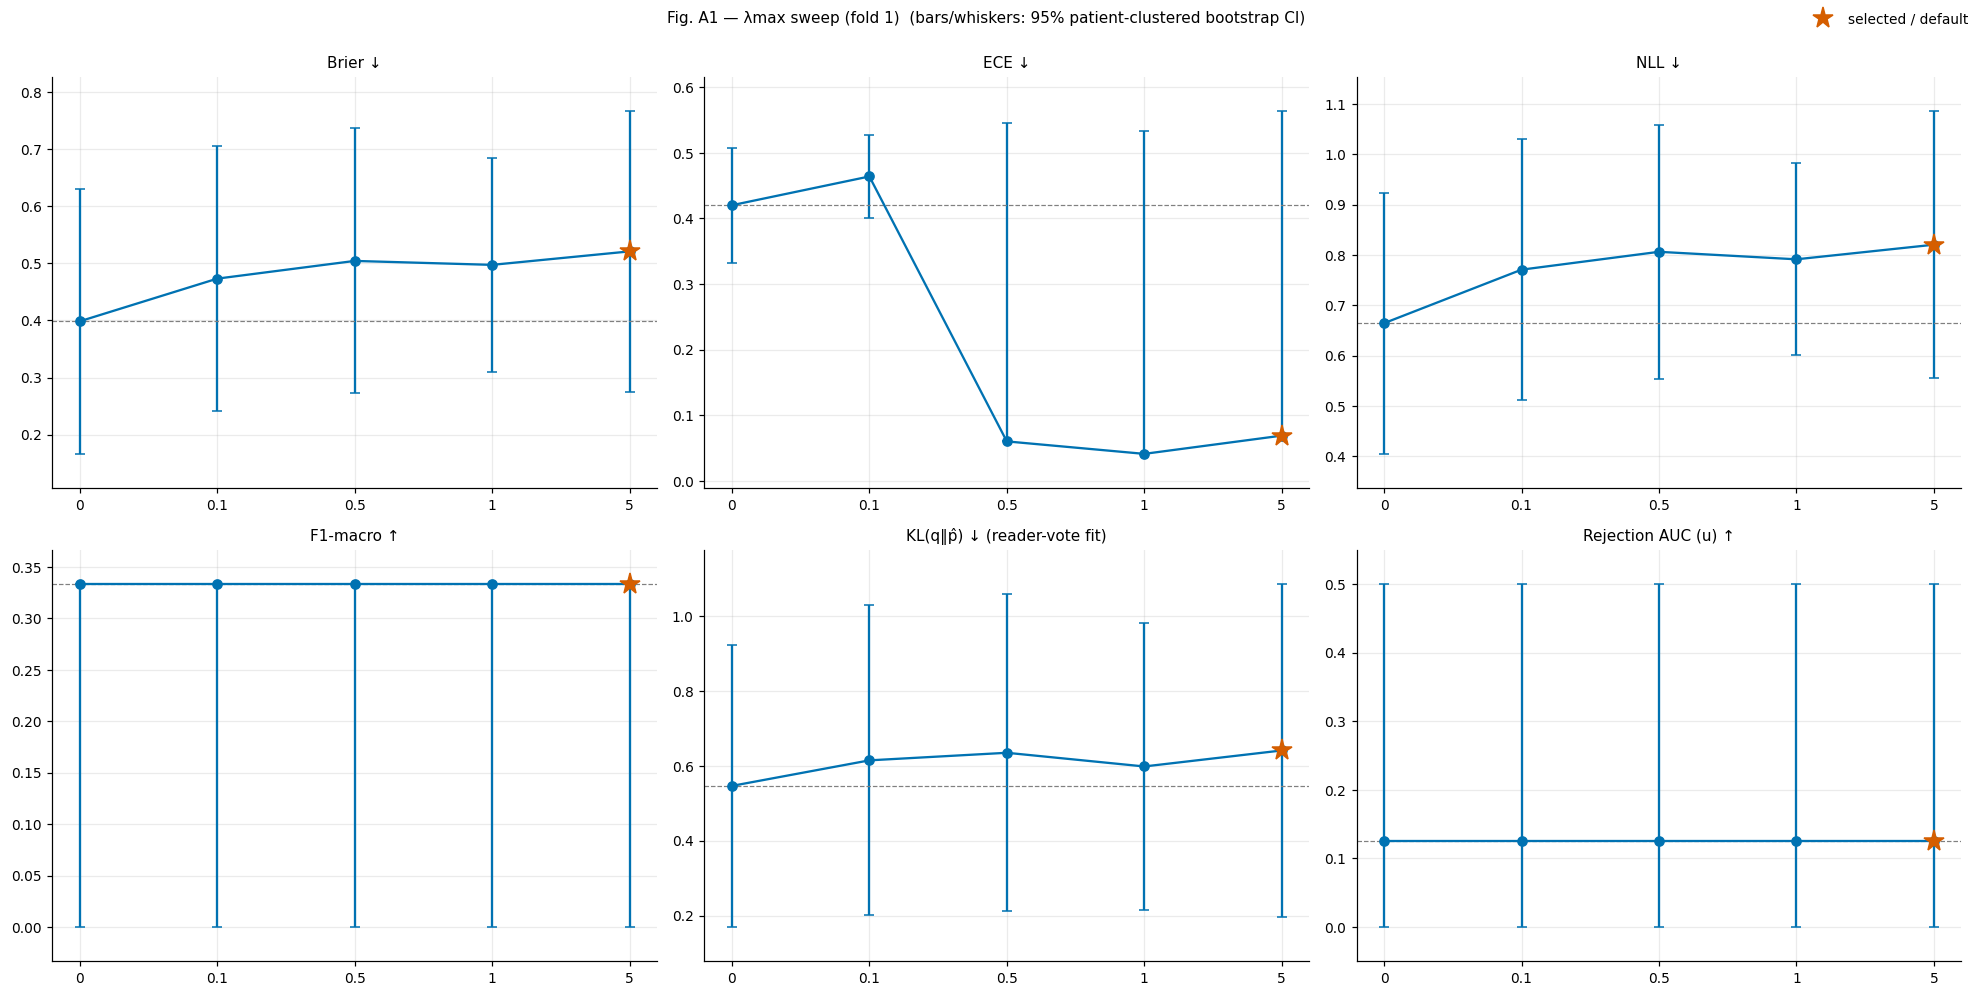

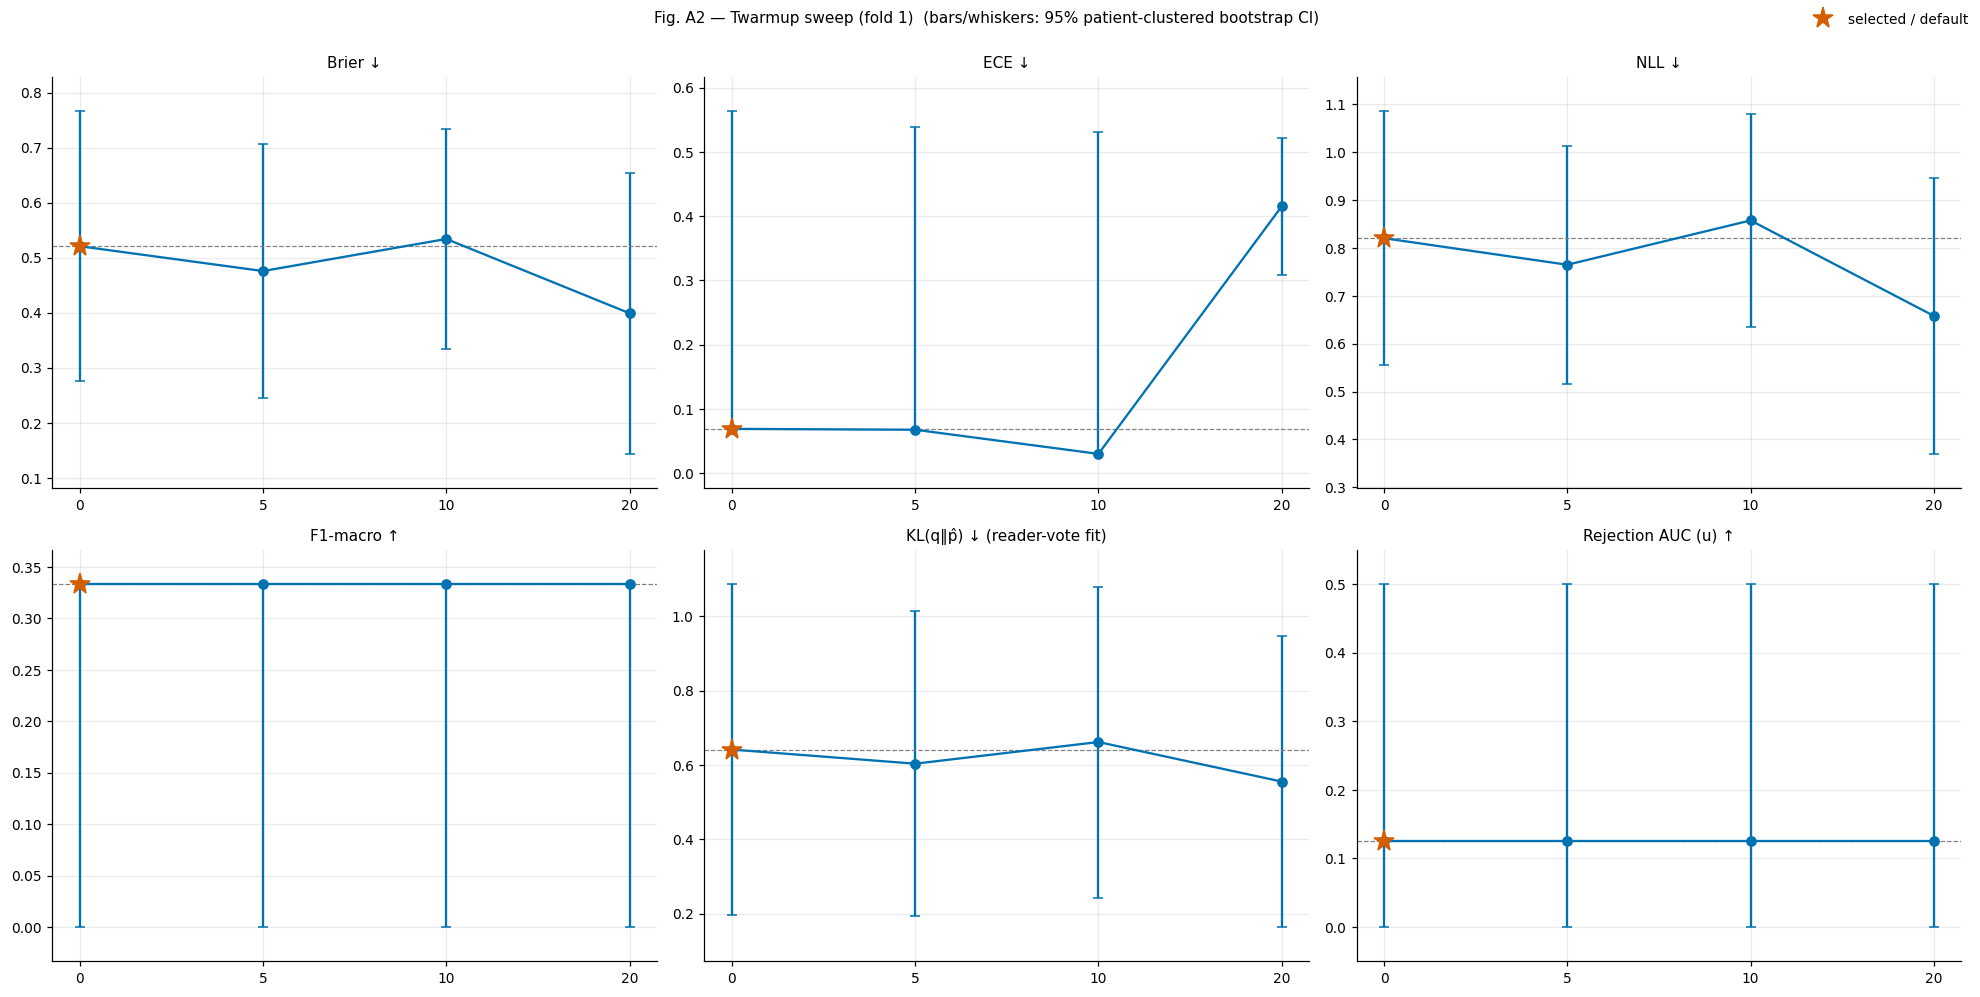

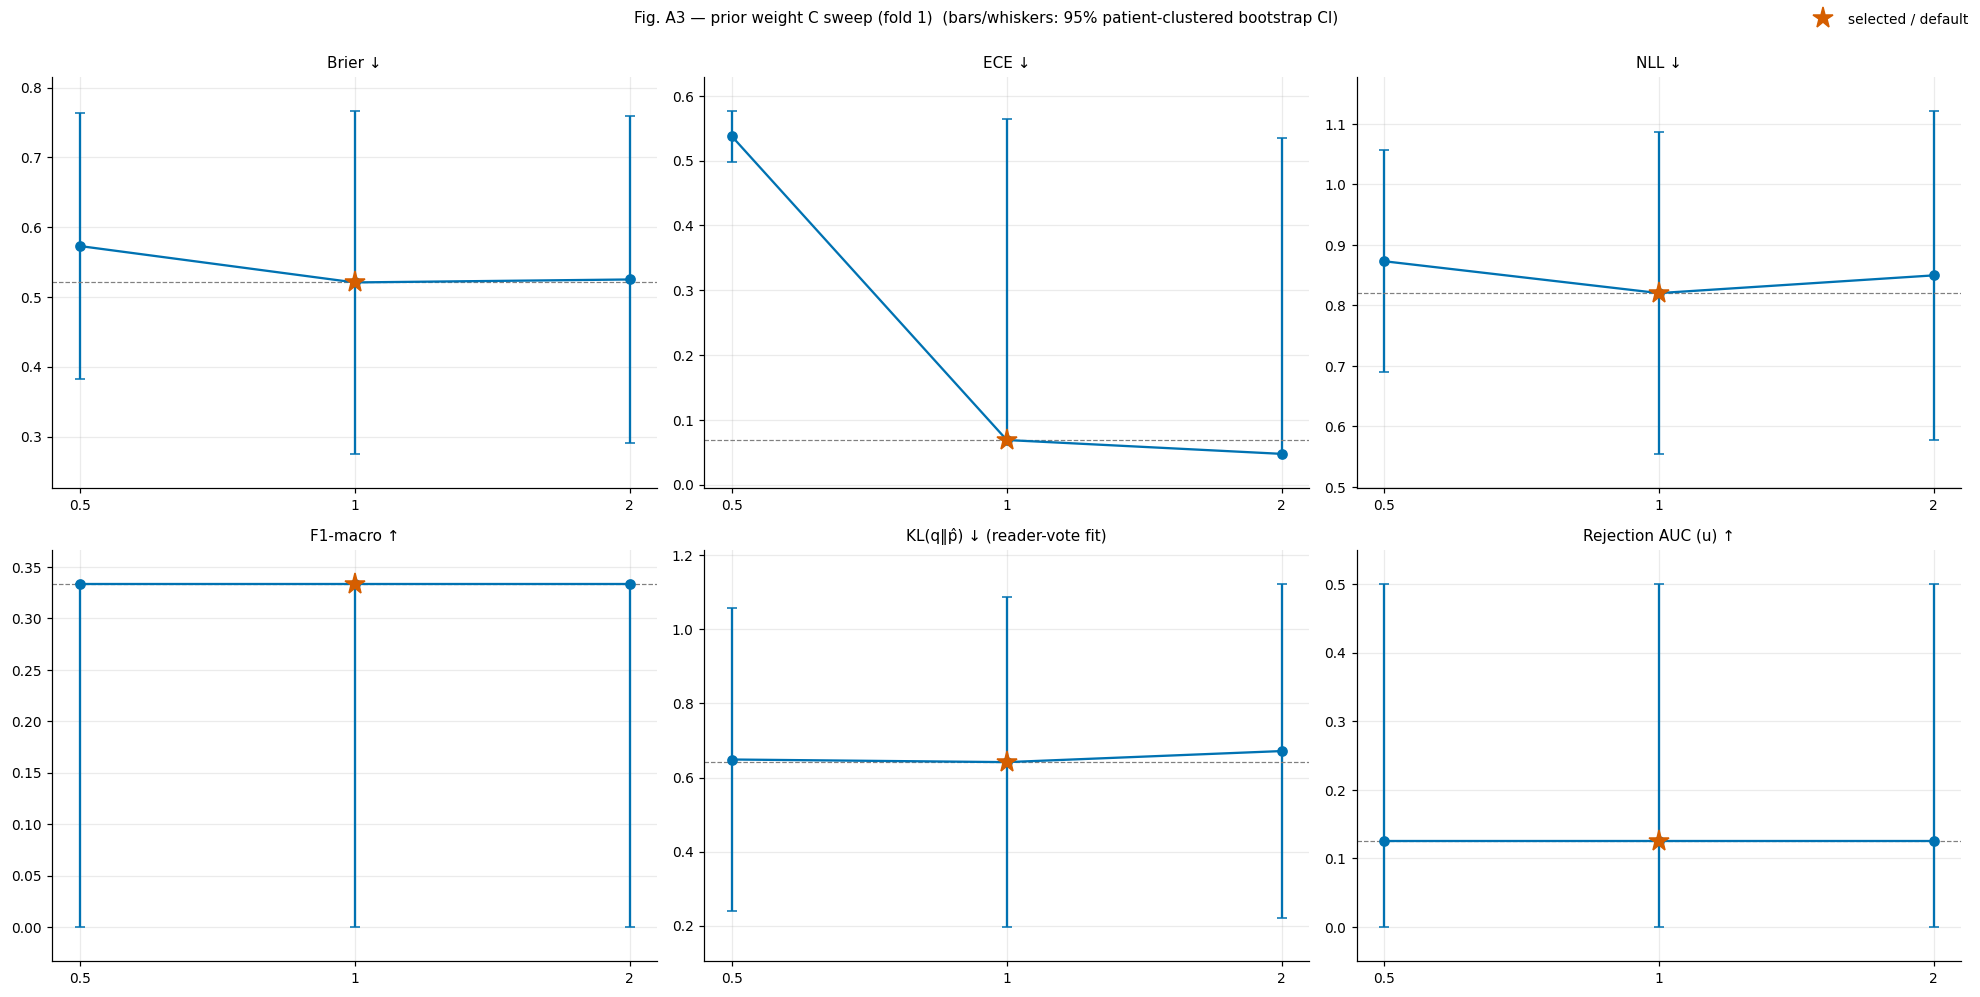

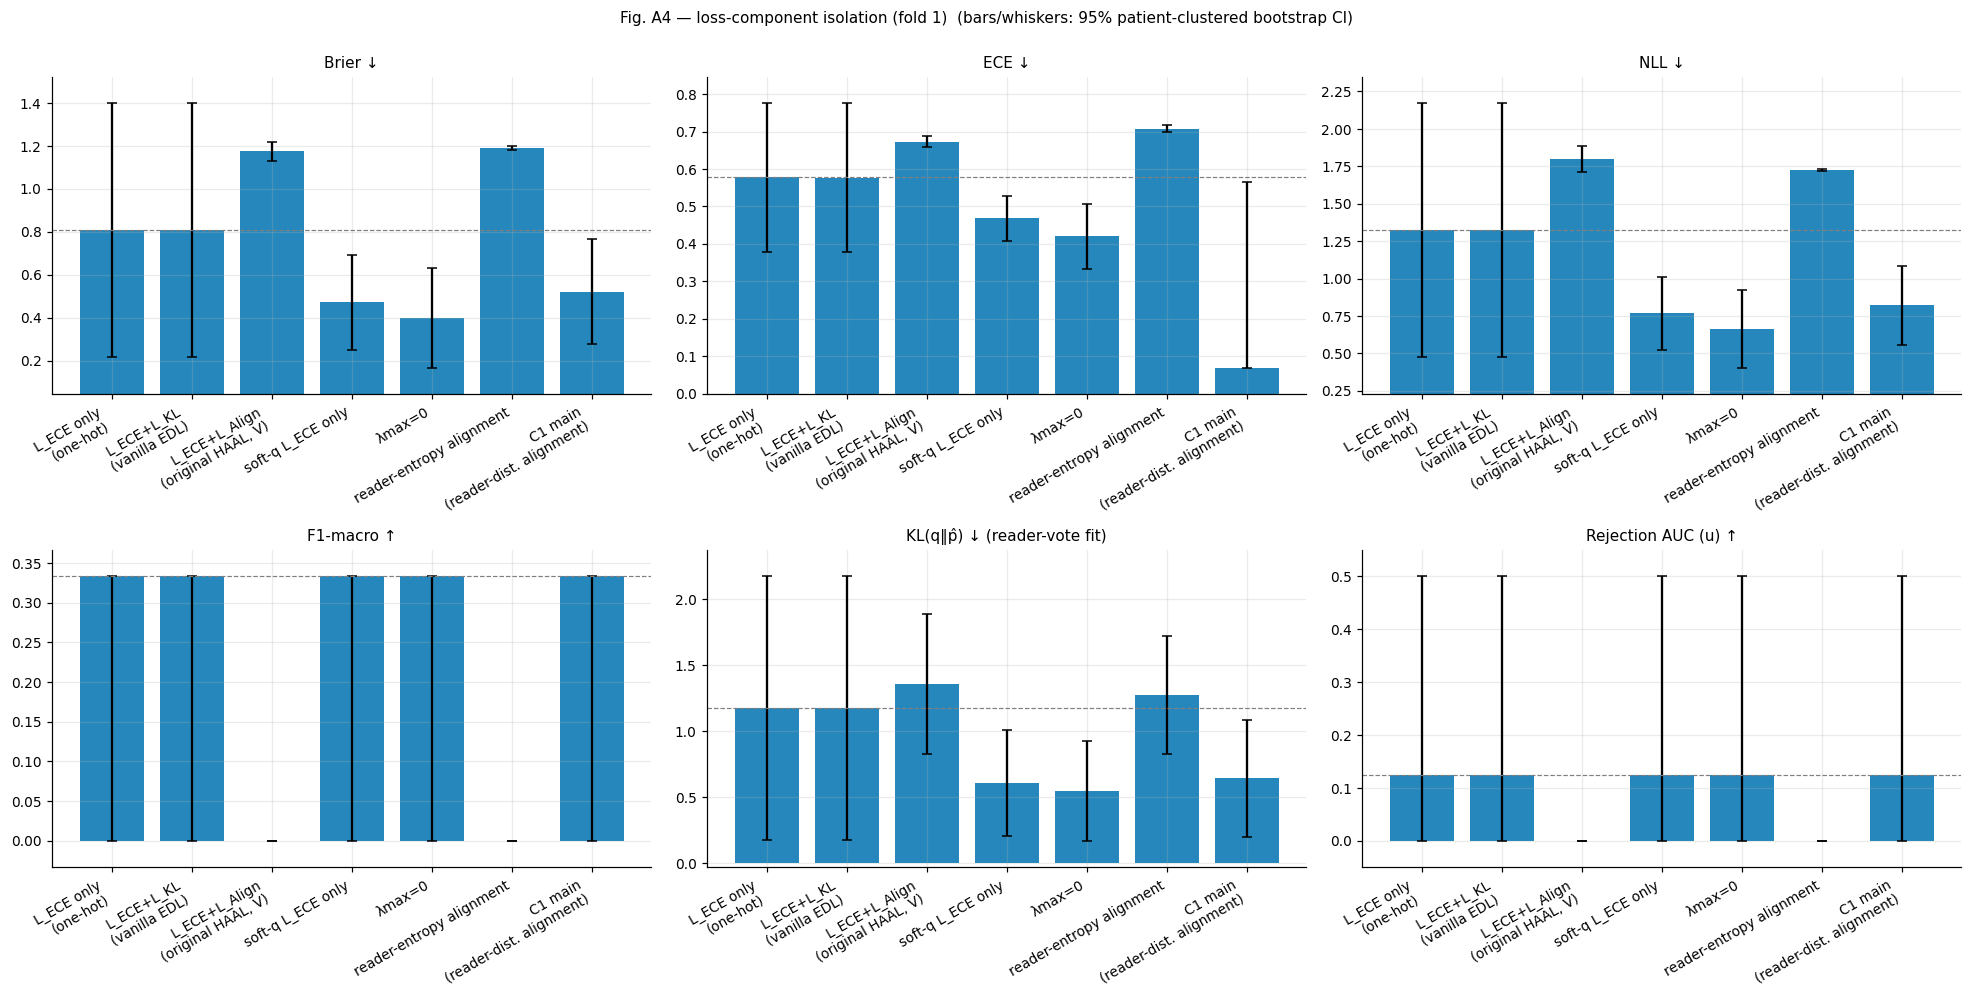

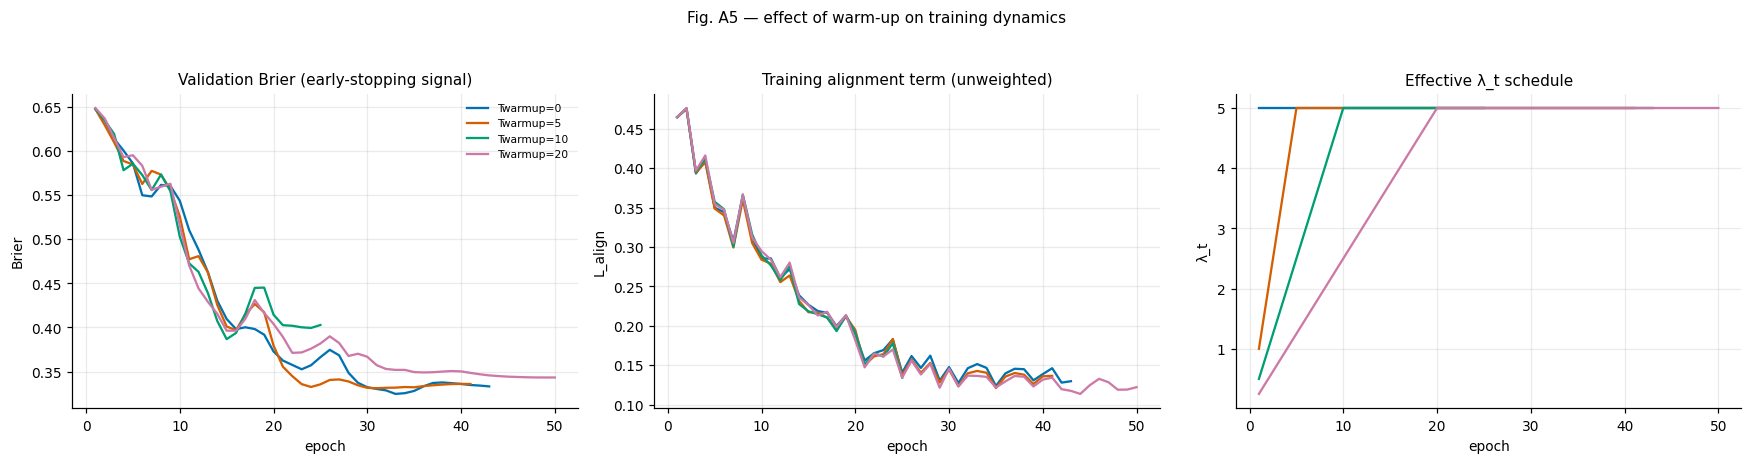

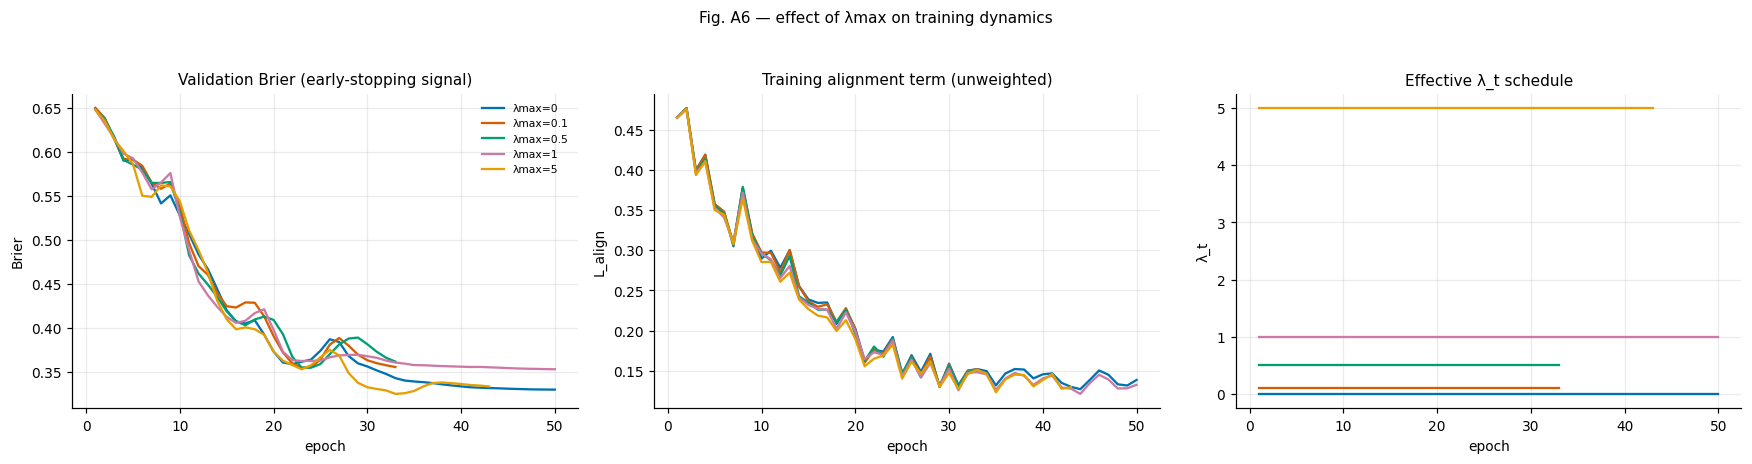

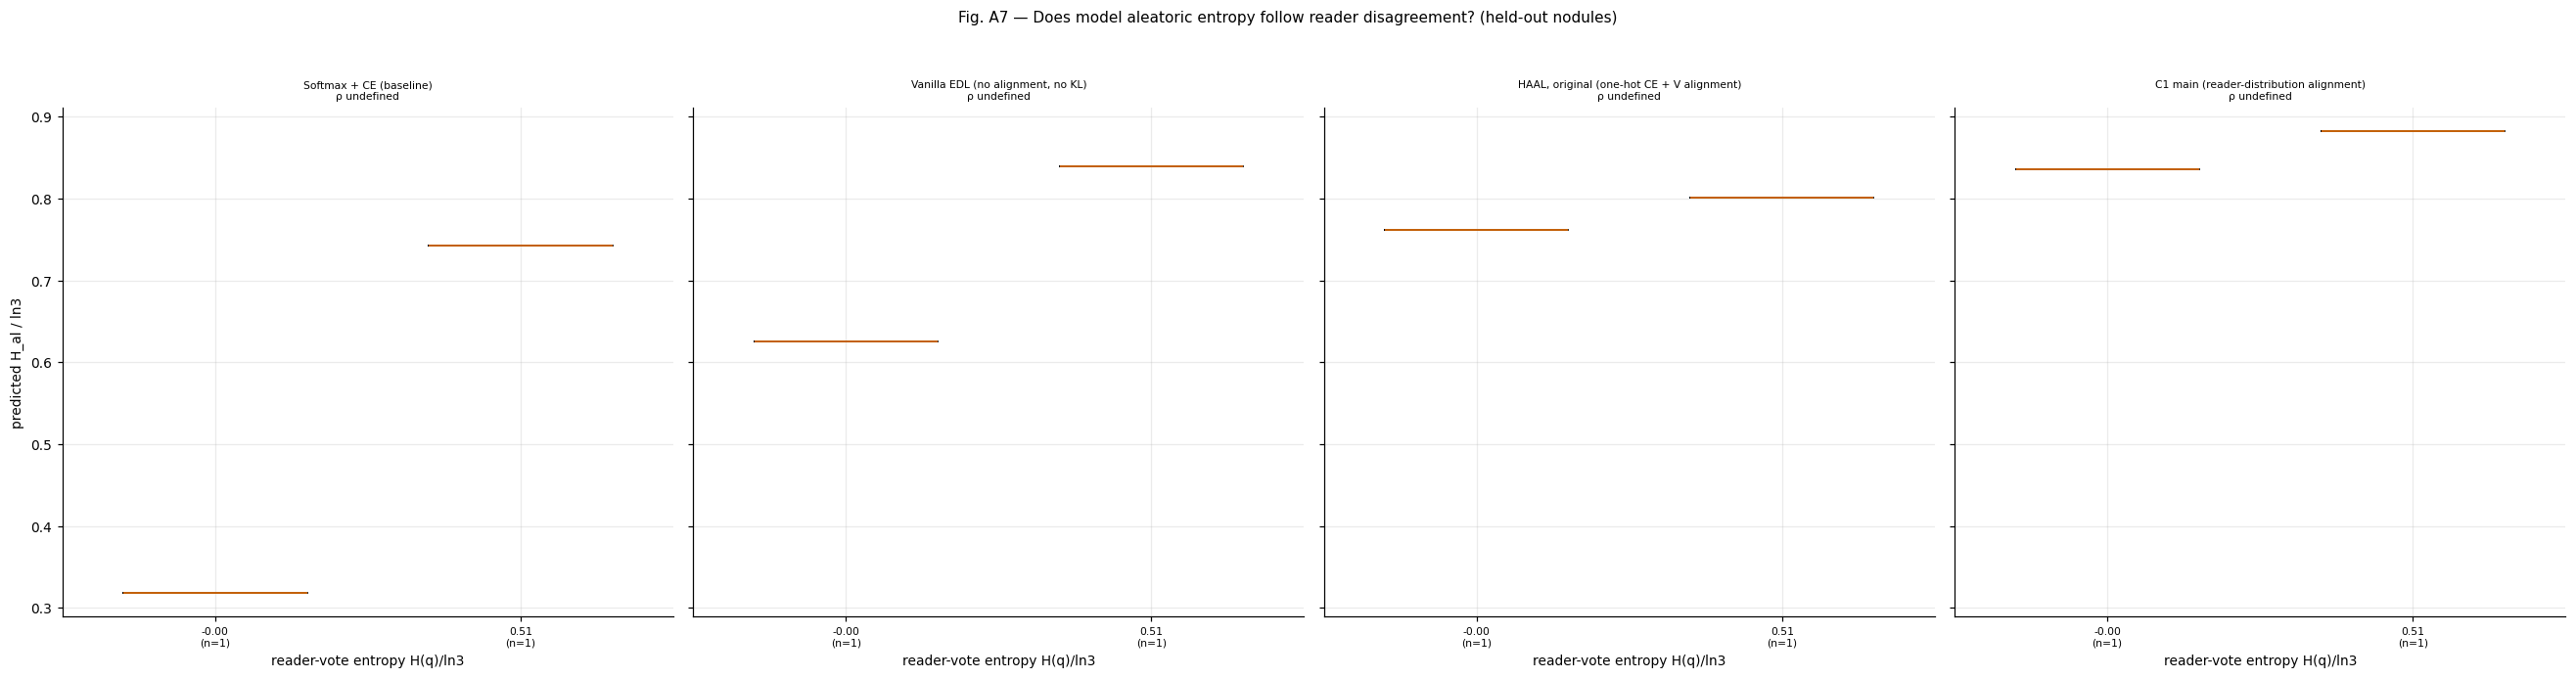

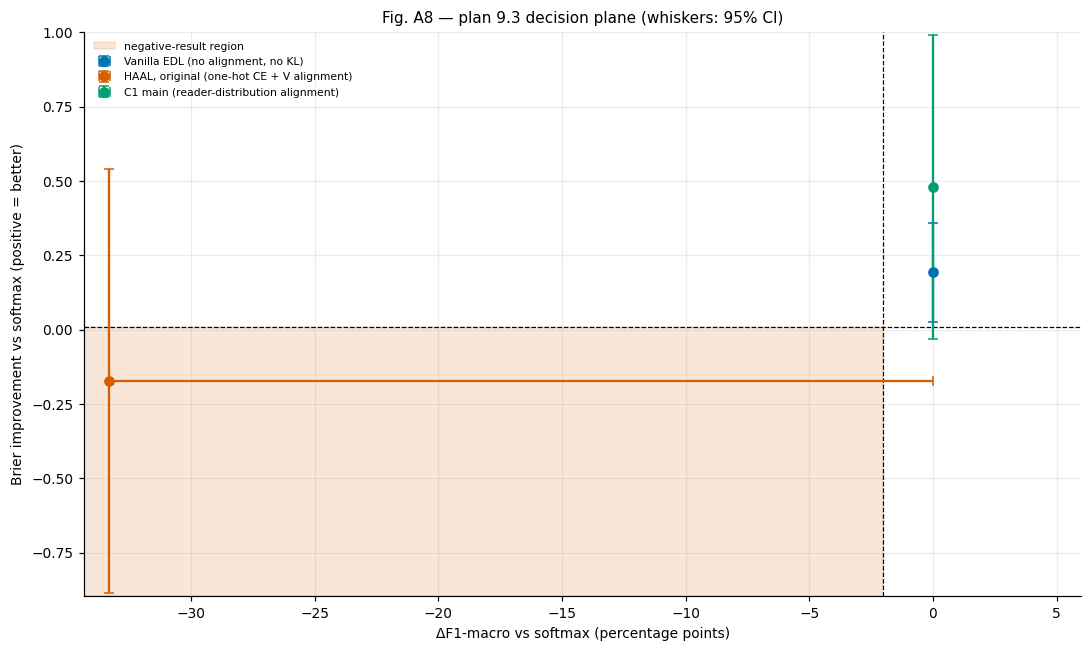

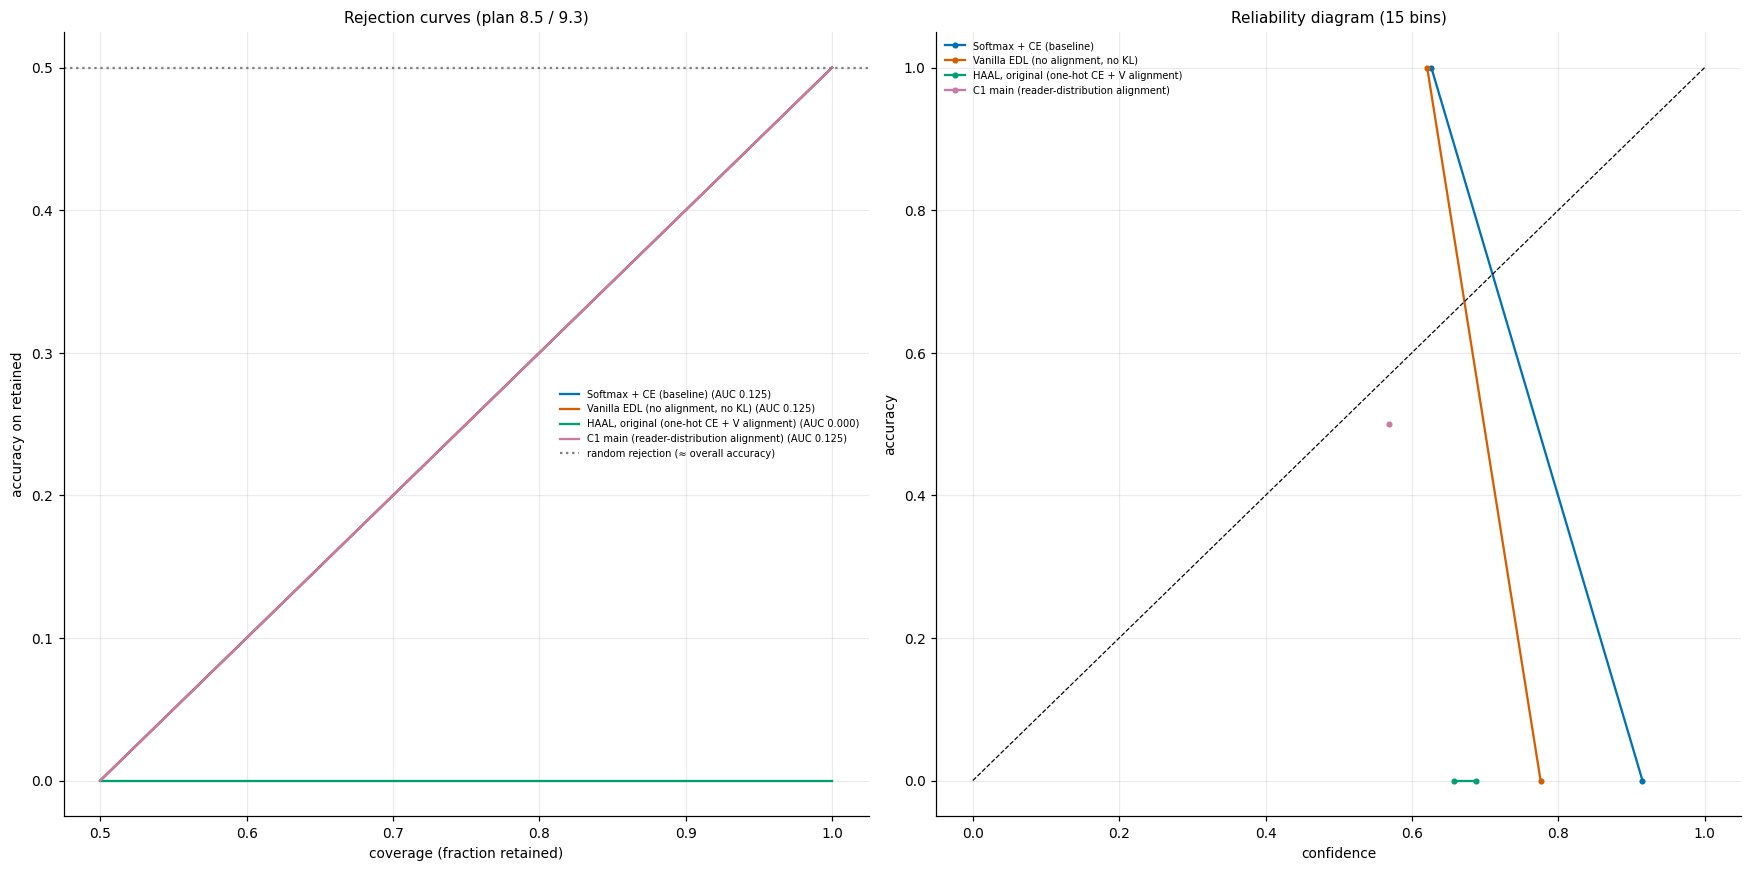

In [25]:

plt.rcParams.update({"font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9, "figure.dpi": 110, "savefig.dpi": 300,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25,
                     "font.family": "DejaVu Sans"})
PAL = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#555555"]

def savefig(fig, name):
    for ext in ("png", "pdf"): fig.savefig(ABL_DIRS["figures"]/f"{name}.{ext}", bbox_inches="tight")
    plt.show(); plt.close(fig)

PANELS = [("brier_score","Brier ↓"),("ece_15","ECE ↓"),("nll","NLL ↓"),("f1_macro","F1-macro ↑"),
          ("mean_KL_q_p","KL(q‖p̂) ↓ (reader-vote fit)"),("rejection_auc_uncertainty","Rejection AUC (u) ↑")]

def sweep_figure(names, xlabels, title, fname, mark=None, bars=False, ref=None):
    fig, axes = plt.subplots(2, 3, figsize=(18, 9)); x = np.arange(len(names))
    for ax, (m, ttl) in zip(axes.ravel(), PANELS):
        c = np.array([ci(n, m) for n in names]); e, lo, hi = c[:, 0], c[:, 1], c[:, 2]
        yerr = np.vstack([e - lo, hi - e])
        if bars: ax.bar(x, e, yerr=yerr, capsize=3, color=PAL[0], alpha=.85)
        else:    ax.errorbar(x, e, yerr=yerr, marker="o", capsize=3, color=PAL[0], lw=1.5)
        if mark in names:
            k = names.index(mark); ax.plot([k], [e[k]], marker="*", ms=14, color=PAL[1], zorder=5, ls="none", label="selected / default")
        if ref in names: ax.axhline(e[names.index(ref)], color="grey", ls="--", lw=.8)
        ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=0 if not bars else 30, ha="center" if not bars else "right")
        ax.set_title(ttl)
        lim = (min(lo), max(hi)); pad = .1*(lim[1]-lim[0] + 1e-9); ax.set_ylim(lim[0]-pad, lim[1]+pad)
    h, l = axes.ravel()[0].get_legend_handles_labels()
    if h: fig.legend(h, l, loc="upper right", frameon=False)
    fig.suptitle(title + "  (bars/whiskers: 95% patient-clustered bootstrap CI)", y=1.0, fontsize=10)
    fig.tight_layout(); savefig(fig, fname)

sweep_figure(GROUPS["lambda"], [f"{v:g}" for v in ABL["lambda_values"]], f"Fig. A1 — λmax sweep (fold {ABL['fold']})", "fig_A1_lambda_sweep",
             mark=f"lam_{SEL_LAM:g}", ref="lam_0")
sweep_figure(GROUPS["warmup"], [str(v) for v in ABL["warmup_values"]], f"Fig. A2 — Twarmup sweep (fold {ABL['fold']})", "fig_A2_warmup_sweep",
             mark=f"warm_{SEL_WARM}", ref="warm_0")
sweep_figure(GROUPS["prior_c"], [f"{v:g}" for v in ABL["prior_c_values"]], f"Fig. A3 — prior weight C sweep (fold {ABL['fold']})", "fig_A3_prior_c_sweep",
             mark=f"C_{BASE_C:g}", ref=f"C_{BASE_C:g}")
sweep_figure(GROUPS["isolation"], [LABELS.get(n, n).replace(" (", "\n(") for n in GROUPS["isolation"]],
             f"Fig. A4 — loss-component isolation (fold {ABL['fold']})", "fig_A4_loss_isolation", bars=True, ref="iso_hard_ce")

def curves(names, labels, fname, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for i, (n, lb) in enumerate(zip(names, labels)):
        try: h = pd.read_csv(ABL_RUNS[n]["hist_path"])
        except Exception: continue
        axes[0].plot(h.epoch, h.val_brier, color=PAL[i % 7], label=lb); axes[1].plot(h.epoch, h.train_alignment, color=PAL[i % 7])
        axes[2].plot(h.epoch, h.lambda_t, color=PAL[i % 7])
    for a, t, yl in zip(axes, ["Validation Brier (early-stopping signal)", "Training alignment term (unweighted)", "Effective λ_t schedule"], ["Brier", "L_align", "λ_t"]):
        a.set_title(t); a.set_xlabel("epoch"); a.set_ylabel(yl)
    axes[0].legend(frameon=False, fontsize=7); fig.suptitle(title, y=1.04, fontsize=10); fig.tight_layout(); savefig(fig, fname)
curves(GROUPS["warmup"], [f"Twarmup={w}" for w in ABL["warmup_values"]], "fig_A5_warmup_dynamics", "Fig. A5 — effect of warm-up on training dynamics")
curves([n for n in GROUPS["lambda"]], [f"λmax={v:g}" for v in ABL["lambda_values"]], "fig_A6_lambda_dynamics", "Fig. A6 — effect of λmax on training dynamics")

# ---- Fig A7: mechanism proof — does predicted aleatoric entropy actually track reader disagreement? ----
def mechanism(names, fname):
    fig, axes = plt.subplots(1, len(names), figsize=(6*len(names), 6), sharey=True)
    for ax, n in zip(np.atleast_1d(axes), names):
        d = PRED[n]; lv = np.sort(d.reader_vote_entropy_normalized.round(3).unique())
        data = [d.loc[d.reader_vote_entropy_normalized.round(3) == v, "H_al_normalized"].values for v in lv]
        ax.boxplot(data, positions=range(len(lv)), widths=.6, showfliers=False)
        ax.set_xticks(range(len(lv))); ax.set_xticklabels([f"{v:.2f}\n(n={len(g)})" for v, g in zip(lv, data)], fontsize=7)
        rho = ABL_RUNS[n]["spearman_Hal_Hq"]; ax.set_title(f"{lab93(n)}\nρ={rho:.3f}" if np.isfinite(rho) else f"{lab93(n)}\nρ undefined", fontsize=7)
        ax.set_xlabel("reader-vote entropy H(q)/ln3")
    np.atleast_1d(axes)[0].set_ylabel("predicted H_al / ln3")
    fig.suptitle("Fig. A7 — Does model aleatoric entropy follow reader disagreement? (held-out nodules)", y=1.04, fontsize=10)
    fig.tight_layout(); savefig(fig, fname)
mechanism(GROUPS["assumption"], "fig_A7_mechanism_entropy_vs_disagreement")

# ---- Fig A8: ΔF1 vs Brier gain----
def decision_plane(fname):
    fig, ax = plt.subplots(figsize=(10, 6)); pts = []
    for alt in ["iso_hard_ce", "iso_haal_orig", "C1_main"]:
        f1_pp = (POINT[alt][3]-POINT["softmax_ce"][3])*100; bg = POINT["softmax_ce"][0]-POINT[alt][0]
        _, flo, fhi, _ = delta("softmax_ce", alt, "f1_macro"); _, blo, bhi, _ = delta("softmax_ce", alt, "brier_score")
        pts.append((alt, f1_pp, bg, flo*100, fhi*100, -bhi, -blo))
    xlo = min([-ABL["neg_f1_drop_pp"]-3] + [p[3] for p in pts]) - 1; xhi = max([ABL["neg_f1_drop_pp"]+3] + [p[4] for p in pts]) + 1
    ylo = min([-ABL["neg_brier_gain"]*3] + [p[5] for p in pts]) - .01; yhi = max([ABL["neg_brier_gain"]*3] + [p[6] for p in pts]) + .01
    ax.fill_betweenx([ylo, ABL["neg_brier_gain"]], xlo, -ABL["neg_f1_drop_pp"], color="#D55E00", alpha=.15, label="negative-result region")
    ax.axvline(-ABL["neg_f1_drop_pp"], color="k", ls="--", lw=.8); ax.axhline(ABL["neg_brier_gain"], color="k", ls="--", lw=.8)
    for i, (alt, f1_pp, bg, xl, xh, yl, yh) in enumerate(pts):
        ax.errorbar([f1_pp], [bg], xerr=[[max(f1_pp-xl, 0)], [max(xh-f1_pp, 0)]], yerr=[[max(bg-yl, 0)], [max(yh-bg, 0)]],
                    fmt="o", color=PAL[i], capsize=3, label=lab93(alt))
    ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
    ax.set_xlabel("ΔF1-macro vs softmax (percentage points)"); ax.set_ylabel("Brier improvement vs softmax (positive = better)")
    ax.set_title("Fig. A8 — plan 9.3 decision plane (whiskers: 95% CI)"); ax.legend(frameon=False, fontsize=7, loc="best"); fig.tight_layout(); savefig(fig, fname)
decision_plane("fig_A8_alignment_decision_plane")

# ---- Fig A9: rejection curves + reliability diagrams ----
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for i, n in enumerate(GROUPS["assumption"]):
    d = PRED[n]; y_ = d.y_true.values.astype(int); P_ = d[PROB_COLS].values
    rc = rejection_curve(y_, P_, d["u"].values); axes[0].plot(rc.coverage, rc.accuracy, color=PAL[i], label=f"{lab93(n)} (AUC {rejection_auc(rc):.3f})")
    _, tab = ece_score(P_, y_, CONFIG["ece_bins"]); t = tab.dropna(); axes[1].plot(t.confidence, t.accuracy, marker="o", ms=3, color=PAL[i], label=lab93(n))
base = (PRED["softmax_ce"][PROB_COLS].values.argmax(1) == PRED["softmax_ce"].y_true.values).mean()
axes[0].axhline(base, color="grey", ls=":", label="random rejection (≈ overall accuracy)")
axes[0].set_xlabel("coverage (fraction retained)"); axes[0].set_ylabel("accuracy on retained"); axes[0].set_title("Rejection curves (plan 8.5 / 9.3)")
axes[1].plot([0, 1], [0, 1], "k--", lw=.8); axes[1].set_xlabel("confidence"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Reliability diagram (15 bins)")
axes[0].legend(frameon=False, fontsize=6.5); axes[1].legend(frameon=False, fontsize=6.5); fig.tight_layout(); savefig(fig, "fig_A9_rejection_and_reliability")

### 17.6 ESM target-scalar ablation (∂u vs ∂H_al vs Grad-CAM)


Ablation 9.2: ESM target scalar vs Grad-CAM (fold 1). Gains are paired differences to the control map computed on the same output function f (positive = better than control); CI = patient-clustered bootstrap.
             Method  n cases insertion gain vs random [95% CI] deletion gain vs random [95% CI] ins+del gain vs random [95% CI] insertion gain vs centre prior [95% CI] deletion gain vs centre prior [95% CI] ins+del gain vs centre prior [95% CI] Insertion AUC Deletion AUC mean peak dist. to centre (px) peak on border
 Grad-CAM (∂p_c/∂A)        2        +0.0284 [+0.0005, +0.0563]       +0.0271 [+0.0049, +0.0492]      +0.0555 [+0.0497, +0.0612]              +0.0377 [+0.0180, +0.0573]             +0.0298 [+0.0264, +0.0333]            +0.0675 [+0.0444, +0.0906]        0.5757       0.5265                           51.5          0.000
      ESM-u (∂u/∂A)        2        -0.0163 [-0.0188, -0.0139]       +0.0192 [+0.0113, +0.0270]      +0.0028 [-0.0026, +0.0082]              +0.0046 [-0.0

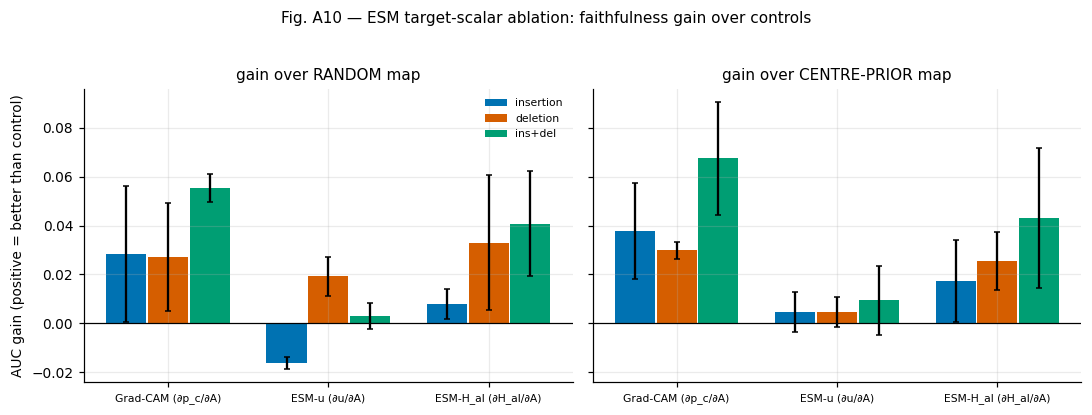

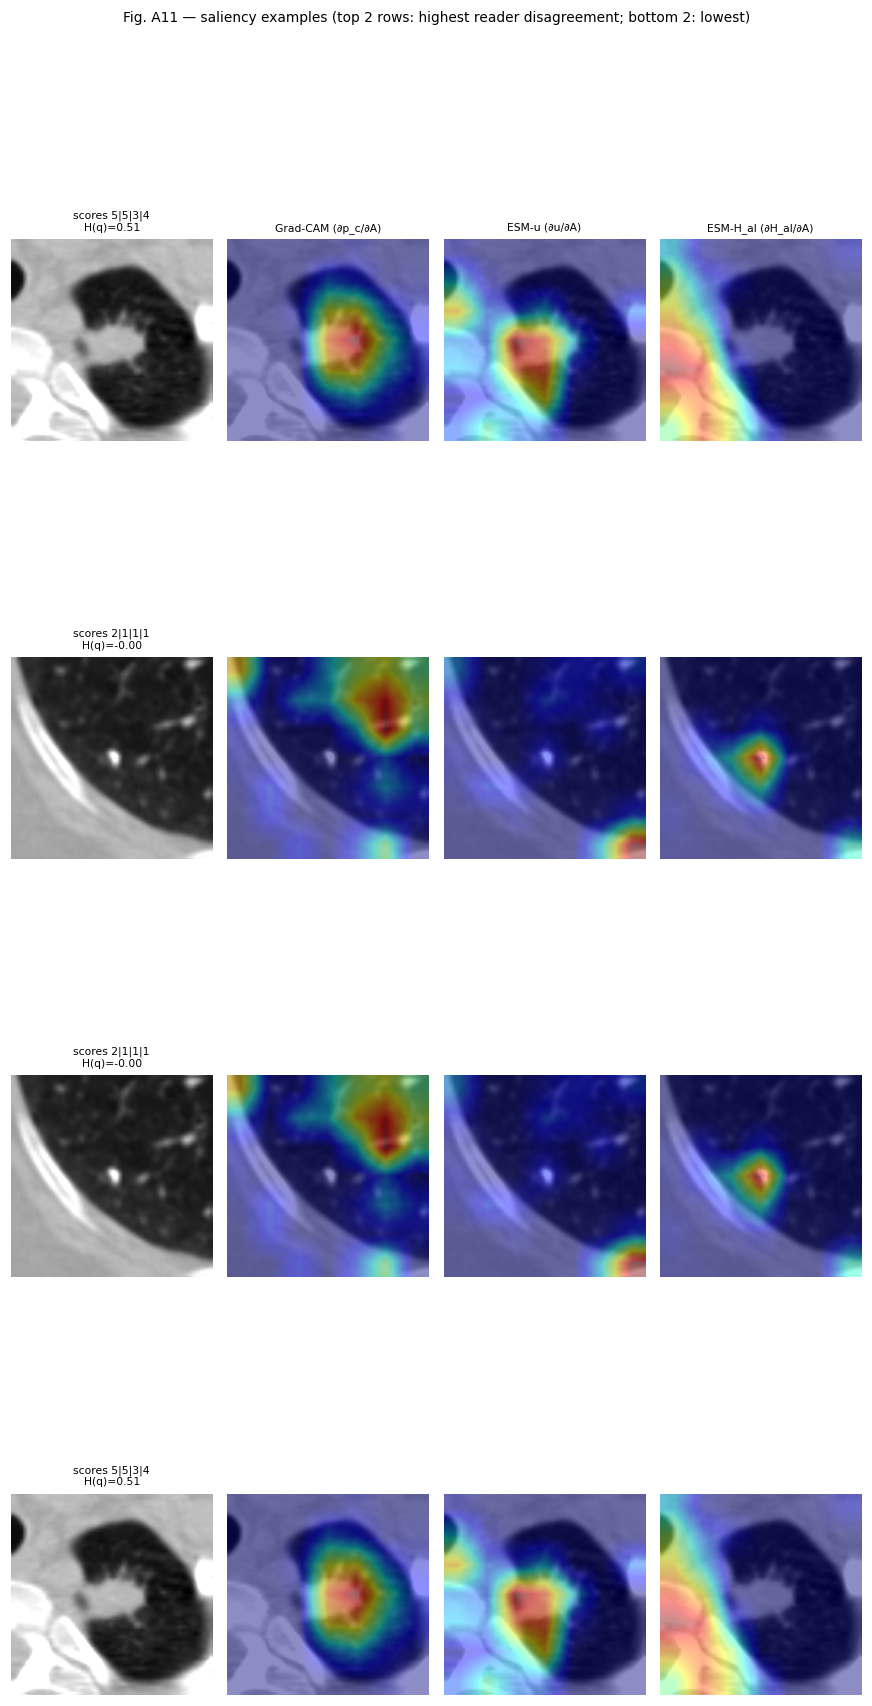

In [26]:
# ============================================================
# 17.6  ESM target-scalar ablation: dA/du  vs  dH_al/dA  vs  Grad-CAM dp_c/dA
# Re-uses the insertion/deletion CSV written by the XAI cell (no retraining). Controls: random map, centre prior.
# ============================================================
xf = CONFIG["xai_fold"]
_idp = DIRS["metrics_xai"]/f"insertion_deletion_fold_{xf}.csv"
XAI_OK = _idp.exists()
if not XAI_OK:
    print("XAI CSV not found -> run the XAI cell (section 14b) first:", _idp)
else:
    xai_df = pd.read_csv(_idp)
    pid_of = meta.set_index("array_index")["patient_id"].astype(str)
    METHODS = [("gradcam","prob","Grad-CAM (∂p_c/∂A)"), ("esm_vacuity","vacuity","ESM-u (∂u/∂A)"), ("esm_aleatoric","aleatoric","ESM-H_al (∂H_al/∂A)")]

    def cluster_mean_ci(v, groups, B=2000, seed=0):
        v = np.asarray(v, float); g = pd.Series(groups).astype(str).values; ug = np.unique(g)
        s = np.array([v[g == k].sum() for k in ug]); c = np.array([(g == k).sum() for k in ug]); rng = np.random.RandomState(seed)
        ix = rng.randint(0, len(ug), (B, len(ug))); bs = s[ix].sum(1)/c[ix].sum(1)
        return float(v.mean()), float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))

    rows = []; prow_ = []; GAINS = {}
    for key, f, lab in METHODS:
        sub = xai_df[xai_df.scalar_f == f]
        wide = {m: sub[sub["map"] == m].drop_duplicates("array_index").set_index("array_index")[["insertion_auc","deletion_auc"]]
                for m in [key, "random_control", "center_prior_control"]}
        idx = wide[key].index.intersection(wide["random_control"].index).intersection(wide["center_prior_control"].index)
        if len(idx) == 0: continue
        grp = pid_of.reindex(idx).values
        r = {"Method": lab, "n cases": len(idx)}; rp = {"Method": lab}
        for ctl, ctl_name in [("random_control","random"), ("center_prior_control","centre prior")]:
            gi = (wide[key].loc[idx,"insertion_auc"] - wide[ctl].loc[idx,"insertion_auc"]).values      # >0 better
            gd = (wide[ctl].loc[idx,"deletion_auc"] - wide[key].loc[idx,"deletion_auc"]).values        # >0 better
            gs = gi + gd                                                                               # combined fidelity gain
            GAINS[(key, ctl)] = {"ins": gi, "del": gd, "comb": gs, "grp": grp}
            for nm, arr in [("insertion", gi), ("deletion", gd), ("ins+del", gs)]:
                e, lo, hi = cluster_mean_ci(arr, grp)
                try: pw = float(wilcoxon(arr, alternative="two-sided").pvalue) if np.any(arr != 0) else 1.0
                except Exception: pw = float("nan")
                r[f"{nm} gain vs {ctl_name} [95% CI]"] = f"{e:+.4f} [{lo:+.4f}, {hi:+.4f}]"
                rp[f"{nm} vs {ctl_name}"] = f"{pw:.2g}"
        r["Insertion AUC"] = f"{wide[key].loc[idx,'insertion_auc'].mean():.4f}"; r["Deletion AUC"] = f"{wide[key].loc[idx,'deletion_auc'].mean():.4f}"
        pk = xai_df[(xai_df["map"] == key)]
        r["mean peak dist. to centre (px)"] = f"{pk.peak_dist_center.mean():.1f}"; r["peak on border"] = f"{pk.peak_on_border.astype(float).mean():.3f}"
        rows.append(r); prow_.append(rp)
    T_ESM = save_table(pd.DataFrame(rows), "table_9_2b_esm_target_scalar",
        f"Ablation 9.2: ESM target scalar vs Grad-CAM (fold {xf}). Gains are paired differences to the control map computed on the same output function f (positive = better than control); CI = patient-clustered bootstrap.")

    save_table(pd.DataFrame(prow_), "table_9_2b_esm_wilcoxon_p", "ESM ablation: two-sided Wilcoxon signed-rank p-values of the paired gains (per-case; cases from one patient are not independent, so prefer the clustered CIs).")

    # ---- Pointing Game (only when masks were provided to the XAI cell) ----
    pbp = DIRS["metrics_xai"]/f"pointing_boundary_fold_{xf}.csv"
    if pbp.exists():
        pb = pd.read_csv(pbp); pb["pid"] = pb.array_index.map(pid_of); out = []
        ctr = pb[pb["map"] == "center_prior_control"].set_index("array_index")["hit"].astype(float)
        for mname in ["gradcam","esm_vacuity","esm_aleatoric","random_control","center_prior_control"]:
            s = pb[pb["map"] == mname].drop_duplicates("array_index").set_index("array_index")
            e, lo, hi = cluster_mean_ci(s["hit"].astype(float).values, s["pid"].values)
            dd = (s["hit"].astype(float) - ctr.reindex(s.index)).dropna(); de, dlo, dhi = cluster_mean_ci(dd.values, s.loc[dd.index, "pid"].values)
            out.append({"Map": mname, "Pointing Game hit rate [95% CI]": f"{e:.3f} [{lo:.3f}, {hi:.3f}]",
                        "Δ vs centre prior [95% CI]": f"{de:+.3f} [{dlo:+.3f}, {dhi:+.3f}]",
                        "mean signed boundary dist. (norm.)": f"{s.signed_boundary_dist_norm.mean():+.3f}", "n": len(s)})
        T_PG = save_table(pd.DataFrame(out), "table_9_2c_pointing_game", "Pointing Game and signed boundary distance (negative = inside the nodule).")
    else:
        print("Pointing Game not available: CONFIG['masks_npy'] was not set when the XAI cell ran (plan 8.3 needs radiologist contours).")

    # ---- Fig A10: gains over controls ----
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
    for ax, ctl, ttl in zip(axes, ["random_control", "center_prior_control"], ["gain over RANDOM map", "gain over CENTRE-PRIOR map"]):
        for j, (key, f, lab) in enumerate(METHODS):
            if (key, ctl) not in GAINS: continue
            for k, (nm, col) in enumerate([("ins","insertion"), ("del","deletion"), ("comb","ins+del")]):
                a = GAINS[(key, ctl)][nm]; e, lo, hi = cluster_mean_ci(a, GAINS[(key, ctl)]["grp"])
                ax.bar(j + (k-1)*0.26, e, width=.25, color=PAL[k], yerr=[[e-lo], [hi-e]], capsize=2, label=col if j == 0 else None)
        ax.axhline(0, color="k", lw=.8); ax.set_xticks(range(len(METHODS))); ax.set_xticklabels([m[2] for m in METHODS], fontsize=7); ax.set_title(ttl)
    axes[0].set_ylabel("AUC gain (positive = better than control)"); axes[0].legend(frameon=False, fontsize=7)
    fig.suptitle("Fig. A10 — ESM target-scalar ablation: faithfulness gain over controls", y=1.03, fontsize=10);
    fig.tight_layout();
    savefig(fig, "fig_A10_esm_scalar_ablation")

    # ---- Fig A11: qualitative examples (high vs low reader disagreement) ----
    mp = DIRS["metrics_xai"]/f"maps_fold_{xf}_gradcam_esmvac_esmale_fp16.npy"; ip = DIRS["metrics_xai"]/f"maps_fold_{xf}_index.csv"
    if mp.exists() and ip.exists():
        maps = np.load(mp, mmap_mode="r"); ids = pd.read_csv(ip).array_index.values
        mm = meta.set_index("array_index").loc[ids]; hq_ = mm.reader_vote_entropy_normalized.values
        pick = list(np.argsort(-hq_)[:2]) + list(np.argsort(hq_)[:2]); imgs = np.load(ap(CONFIG["images_npy"]), mmap_mode="r")
        fig, axes = plt.subplots(len(pick), 4, figsize=(8, 4.2*len(pick)))
        for r_, k in enumerate(pick):
            ai = int(ids[k]); axes[r_, 0].imshow(imgs[ai], cmap="gray", vmin=0, vmax=1)
            axes[r_, 0].set_title(f"scores {mm.iloc[k]['malignancy_scores']}\nH(q)={hq_[k]:.2f}", fontsize=7)
            for c_, (key, f, lab) in enumerate(METHODS, start=1):
                axes[r_, c_].imshow(imgs[ai], cmap="gray", vmin=0, vmax=1); axes[r_, c_].imshow(np.asarray(maps[k, c_-1], dtype=np.float32), cmap="jet", alpha=.45, vmin=0, vmax=1)
                if r_ == 0: axes[r_, c_].set_title(lab, fontsize=7)
            for a in axes[r_]: a.axis("off")
        fig.suptitle("Fig. A11 — saliency examples (top 2 rows: highest reader disagreement; bottom 2: lowest)", y=1.01, fontsize=9);
        fig.tight_layout();
        savefig(fig, "fig_A11_saliency_examples")

### 17.7 5-fold confirmation of large effects

16 single-fold comparison(s) exceed the large-effect threshold:
     group            reference                      alternative  d_brier_score  d_f1_macro  effect_ratio
assumption         Softmax + CE C1 main (reader-dist. alignment)        -0.4801      0.0000       48.0079
 isolation L_ECE only (one-hot) C1 main (reader-dist. alignment)        -0.2873      0.0000       28.7319
assumption         Softmax + CE             L_ECE only (one-hot)        -0.1928      0.0000       19.2760
assumption         Softmax + CE L_ECE+L_Align (original HAAL, V)         0.1739     -0.3333       17.3896
    lambda               λmax=0                           λmax=5         0.1223      0.0000       12.2291
    lambda               λmax=0                         λmax=0.5         0.1056      0.0000       10.5635
    lambda               λmax=0                           λmax=1         0.0987      0.0000        9.8721
    lambda               λmax=0                         λmax=0.1         0.0746      0.0

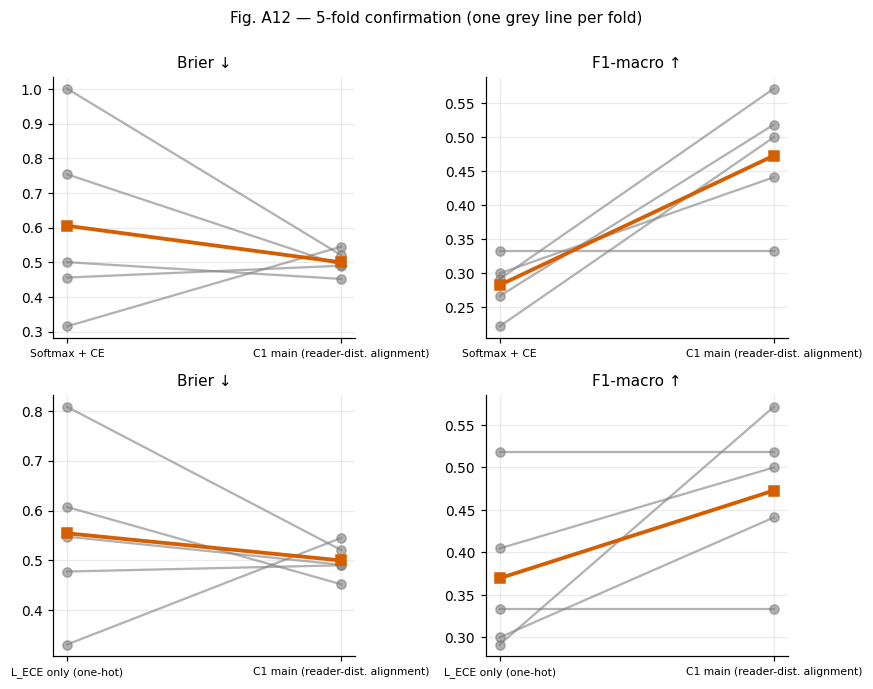

In [27]:
# ============================================================
# 17.7  Confirmation of LARGE effects on the full 5-fold protocol
# Large effect = |ΔBrier| >= large_effect_brier  or  |ΔF1| >= large_effect_f1 on the single-fold run (thresholds in ABL).
# ============================================================
def _flag(r):
    sb = abs(r["d_brier_score"]) / ABL["large_effect_brier"]; sf = abs(r["d_f1_macro"]) / ABL["large_effect_f1"]
    return max(sb, sf)
cand = DELTA.copy(); cand["effect_ratio"] = cand.apply(_flag, axis=1)
cand = cand[(cand.effect_ratio >= 1.0)].sort_values("effect_ratio", ascending=False)
cand = cand.drop_duplicates(["ref_key","alt_key"])
_GORD = {"assumption": 1, "lambda": 2, "warmup": 3, "isolation": 4, "prior_c": 5}
_KEY = {("softmax_ce","C1_main"), ("iso_hard_ce","C1_main")}
cand["prio"] = [0 if (a, b) in _KEY else _GORD.get(g, 9) for g, a, b in zip(cand.group, cand.ref_key, cand.alt_key)]
cand = cand.sort_values(["prio", "effect_ratio"], ascending=[True, False])
if ABL.get("confirm_pairs"):                         # optional manual override: list of (ref_key, alt_key)
    cand = cand[[ (a, b) in set(map(tuple, ABL["confirm_pairs"])) for a, b in zip(cand.ref_key, cand.alt_key)]]
print(f"{len(cand)} single-fold comparison(s) exceed the large-effect threshold:")
print(cand[["group","reference","alternative","d_brier_score","d_f1_macro","effect_ratio"]].round(4).to_string(index=False))

CONFIRM = []
if ABL["confirm_5fold"] and len(cand):
    chosen = cand.head(ABL["confirm_max_comparisons"])
    need = sorted({(n, k) for r in chosen.itertuples() for n in (r.ref_key, r.alt_key) for k in range(1, 6)
                   if n != "C1_main" and SPECS.get(n, {}).get("alias") != "C1_main"
                   and not (ABL_DIRS["runs"]/f"{n}_f{k}.json").exists() and not (k == ABL["fold"])})
    print(f"\nConfirming {len(chosen)} comparison(s) on all 5 folds -> {len(need)} additional training runs (cached & resumable).")
    for r in chosen.itertuples():
        per = []
        for k in range(1, 6):
            a, b = run_config(r.ref_key, k), run_config(r.alt_key, k)
            per.append({"fold": k, **{f"ref_{m}": a[m] for m in ["brier_score","f1_macro","ece_15","nll","rejection_auc_uncertainty"]},
                                   **{f"alt_{m}": b[m] for m in ["brier_score","f1_macro","ece_15","nll","rejection_auc_uncertainty"]}})
        per = pd.DataFrame(per); per.to_csv(ABL_DIRS["tables"]/f"confirm_5fold_{r.ref_key}_vs_{r.alt_key}_per_fold.csv", index=False)
        row = {"Comparison": f"{LABELS.get(r.alt_key, r.alt_key)}  vs  {LABELS.get(r.ref_key, r.ref_key)}", "single-fold ΔBrier": f"{r.d_brier_score:+.4f}",
               "single-fold ΔF1": f"{r.d_f1_macro:+.4f}"}
        for m, nm in [("brier_score","Brier"), ("f1_macro","F1-macro"), ("ece_15","ECE"), ("nll","NLL"), ("rejection_auc_uncertainty","Rej-AUC(u)")]:
            d = (per[f"alt_{m}"] - per[f"ref_{m}"]).values
            try: p = float(wilcoxon(d).pvalue) if np.any(d != 0) else 1.0
            except Exception: p = float("nan")
            row[f"5-fold Δ{nm} mean±sd"] = f"{d.mean():+.4f} ± {d.std(ddof=1):.4f}"; row[f"Δ{nm} folds improved (of 5)"] = int((d < 0).sum() if m in ("brier_score","ece_15","nll") else (d > 0).sum())
            row[f"Δ{nm} Wilcoxon p (exact, n=5)"] = f"{p:.4f}"
        # pooled out-of-fold, patient-clustered bootstrap (Wilcoxon with n=5 cannot go below p=0.0625)
        pa = pd.concat([load_pred(r.ref_key, k).assign(_fold=k) for k in range(1, 6)], ignore_index=True)
        pbb = pd.concat([load_pred(r.alt_key, k).assign(_fold=k) for k in range(1, 6)], ignore_index=True)
        pa = pa.sort_values("nodule_id").reset_index(drop=True); pbb = pbb.sort_values("nodule_id").reset_index(drop=True)
        assert (pa.nodule_id.values == pbb.nodule_id.values).all()
        pid = pa.patient_id.astype(str).values; up = np.unique(pid); rows_by = {p: np.where(pid == p)[0] for p in up}
        y = pa.y_true.values.astype(int); Q = pa[Q_COLS].values; rng = np.random.RandomState(CONFIG["seed"]); dB = []; dF = []
        for _ in range(ABL["bootstrap_n"]):
            ix = np.concatenate([rows_by[p] for p in up[rng.randint(0, len(up), len(up))]])
            va = metric_vector(y[ix], pa[PROB_COLS].values[ix], pa.u.values[ix], Q[ix]); vb = metric_vector(y[ix], pbb[PROB_COLS].values[ix], pbb.u.values[ix], Q[ix])
            dB.append(vb[0]-va[0]); dF.append(vb[3]-va[3])
        row["pooled-OOF ΔBrier [95% CI]"] = "{:+.4f} [{:+.4f}, {:+.4f}]".format(np.mean(dB), *np.percentile(dB, [2.5, 97.5]))
        row["pooled-OOF ΔF1 [95% CI]"] = "{:+.4f} [{:+.4f}, {:+.4f}]".format(np.mean(dF), *np.percentile(dF, [2.5, 97.5]))
        row["effect confirmed?"] = "yes" if (np.percentile(dB, 97.5) < 0 or np.percentile(dB, 2.5) > 0) and np.sign(np.mean(dB)) == np.sign(r.d_brier_score) else "not confirmed (CI spans 0 or sign flips)"
        CONFIRM.append((r, per, row))
    T_CONF = save_table(pd.DataFrame([c[2] for c in CONFIRM]), "table_9_4_five_fold_confirmation",
        "Ablation confirmation on the full 5-fold protocol (per-fold paired differences; exact Wilcoxon p has a floor of 0.0625 at n=5, so the pooled patient-clustered bootstrap is the primary test).")
    fig, axes = plt.subplots(len(CONFIRM), 2, figsize=(8, 3.1*len(CONFIRM)), squeeze=False)
    for i, (r, per, _) in enumerate(CONFIRM):
        for j, (m, ttl) in enumerate([("brier_score", "Brier ↓"), ("f1_macro", "F1-macro ↑")]):
            ax = axes[i, j]
            for k in range(5): ax.plot([0, 1], [per.loc[k, f"ref_{m}"], per.loc[k, f"alt_{m}"]], marker="o", color="grey", alpha=.6)
            ax.plot([0, 1], [per[f"ref_{m}"].mean(), per[f"alt_{m}"].mean()], marker="s", color=PAL[1], lw=2.5, label="mean")
            ax.set_xticks([0, 1]); ax.set_xticklabels([LABELS.get(r.ref_key, r.ref_key), LABELS.get(r.alt_key, r.alt_key)], fontsize=7); ax.set_title(ttl)
    fig.suptitle("Fig. A12 — 5-fold confirmation (one grey line per fold)", y=1.0, fontsize=10); fig.tight_layout(); savefig(fig, "fig_A12_five_fold_confirmation")
else:
    print("5-fold confirmation skipped (disabled or no effect exceeded the pre-registered thresholds).")

### 17.8 Evidence bundle: findings, integrity checks, SHA-256 manifest, zip

In [28]:
# ============================================================
# 17.8  Evidence bundle: automatic findings, integrity checks, SHA-256 manifest
# ============================================================
def _sig(ref, alt, m="brier_score"):
    e, lo, hi, p = delta(ref, alt, m); return e, lo, hi, (lo > 0 or hi < 0)

def _sentence(ref, alt, m="brier_score", better_low=True):
    e, lo, hi, s = _sig(ref, alt, m); good = (e < 0) == better_low
    return (f"{LABELS.get(alt, alt)} vs {LABELS.get(ref, ref)}: Δ{m}={e:+.4f} (95% CI {lo:+.4f}, {hi:+.4f}) → "
            f"{'improvement' if good else 'deterioration'}, CI {'excludes' if s else 'includes'} 0.")

FL = [f"# Auto-generated ablation findings (fold {ABL['fold']}, ConvNeXt V2-T)\n",
     "All statements are descriptive; CIs are patient-clustered bootstrap (single training seed per configuration). "
     "Use the 5-fold confirmation table before claiming an effect.\n"]
FL.append("## 9.1 λmax (reference: λmax=0, alignment off)")
FL += ["- " + _sentence("lam_0", n) for n in GROUPS["lambda"] if n != "lam_0"]
FL += ["- " + _sentence("lam_0", n, "f1_macro", better_low=False) for n in GROUPS["lambda"] if n != "lam_0"]
FL.append("\n## 9.1 Twarmup (reference: Twarmup=0, full alignment from epoch 1)")
FL += ["- " + _sentence("warm_0", n) for n in GROUPS["warmup"] if n != "warm_0"]
FL.append("\n## 9.1 Prior weight C (reference: default C)")
FL += ["- " + _sentence(f"C_{BASE_C:g}", n) for n in GROUPS["prior_c"] if n != f"C_{BASE_C:g}"]
FL.append("\n## 9.2 Loss isolation (reference: L_ECE only)")
FL += ["- " + _sentence("iso_hard_ce", n) for n in ["iso_hard_kl", "iso_haal_orig", "C1_main"]]
FL.append("\n## 9.3 Alignment-assumption test")
for alt in ["iso_hard_ce", "iso_haal_orig", "C1_main"]:
    f1_pp, bg, v = decide("softmax_ce", alt); FL.append(f"- {lab93(alt)}: ΔF1={f1_pp:+.2f} pp, Brier gain={bg:+.4f} → **{v}**")
FL.append("\n## Mechanism check: Spearman(H_al, H(q)) on held-out nodules")
FL += [f"- {LABELS.get(n, n)}: ρ={ABL_RUNS[n]['spearman_Hal_Hq']:.3f}" if np.isfinite(ABL_RUNS[n]["spearman_Hal_Hq"]) else f"- {LABELS.get(n, n)}: ρ undefined" for n in GROUPS["assumption"]]
if CONFIRM:
    FL.append("\n## 5-fold confirmation")
    FL += [f"- {c[2]['Comparison']}: pooled-OOF ΔBrier {c[2]['pooled-OOF ΔBrier [95% CI]']}; confirmed = {c[2]['effect confirmed?']}" for c in CONFIRM]
FIND = "\n".join(FL); (ABL_DIRS["evidence"]/"ablation_findings.md").write_text(FIND, encoding="utf-8"); print(FIND)

# ---- integrity checks ----
CHECKS = {}
for n in RUN_NAMES:
    d = PRED[n]; m = metrics(d.y_true.values.astype(int), d[PROB_COLS].values)
    CHECKS[n] = {"brier_csv_vs_reported": abs(m["brier_score"] - float(ABL_RUNS[n]["brier_score"])) < 1e-6,
                 "f1_csv_vs_reported": abs(m["f1_macro"] - float(ABL_RUNS[n]["f1_macro"])) < 1e-6,
                 "probs_sum_to_1": bool(np.allclose(d[PROB_COLS].sum(axis=1), 1.0, atol=1e-5)),
                 "q_sums_to_1": bool(np.allclose(d[Q_COLS].sum(axis=1), 1.0, atol=1e-5)),
                 "no_nan_probs": bool(np.isfinite(d[PROB_COLS].values).all())}
bad = {n: [k for k, v in c.items() if not v] for n, c in CHECKS.items() if not all(c.values())}
print("\nIntegrity checks:", "ALL PASS" if not bad else f"FAILED -> {bad}")

def _sha(p): return hashlib.sha256(Path(p).read_bytes()).hexdigest()
import platform
manifest = {
    "created": datetime.now().isoformat(timespec="seconds"), "experiment": EXPERIMENT_ID, "ablation_fold": ABL["fold"],
    "fold_assignments_sha256": actual_hash, "selected_hyperparameters": selected, "ablation_settings": _jsonable(ABL),
    "seed": CONFIG["seed"], "device": str(DEVICE),
    "versions": {"python": platform.python_version(), "torch": torch.__version__, "timm": timm.__version__, "numpy": np.__version__, "pandas": pd.__version__},
    "runs": {n: {"label": LABELS.get(n, n), "source": ABL_RUNS[n].get("source"), "epochs_run": ABL_RUNS[n].get("epochs_run"),
                 "prediction_file": ABL_RUNS[n]["pred_path"], "prediction_sha256": _sha(ABL_RUNS[n]["pred_path"]), "integrity": CHECKS[n]} for n in RUN_NAMES},
    "tables": {p.name: _sha(p) for p in sorted(ABL_DIRS["tables"].glob("*"))},
    "figures": {p.name: _sha(p) for p in sorted(ABL_DIRS["figures"].glob("*"))},
    "integrity_all_pass": not bad,
}
(ABL_DIRS["evidence"]/"ablation_manifest.json").write_text(json.dumps(_jsonable(manifest), indent=2), encoding="utf-8")
zip_path = shutil.make_archive(str(DIRS["reports"]/"ablation_evidence_bundle"), "zip", root_dir=ABL_ROOT)
print("\nTables :", ABL_DIRS["tables"]); print("Figures:", ABL_DIRS["figures"]); print("Manifest:", ABL_DIRS["evidence"]/"ablation_manifest.json"); print("Bundle :", zip_path)

# Auto-generated ablation findings (fold 1, ConvNeXt V2-T)

All statements are descriptive; CIs are patient-clustered bootstrap (single training seed per configuration). Use the 5-fold confirmation table before claiming an effect.

## 9.1 λmax (reference: λmax=0, alignment off)
- λmax=0.1 vs λmax=0: Δbrier_score=+0.0746 (95% CI +0.0744, +0.0749) → deterioration, CI excludes 0.
- λmax=0.5 vs λmax=0: Δbrier_score=+0.1056 (95% CI +0.1054, +0.1059) → deterioration, CI excludes 0.
- λmax=1 vs λmax=0: Δbrier_score=+0.0987 (95% CI +0.0543, +0.1432) → deterioration, CI excludes 0.
- λmax=5 vs λmax=0: Δbrier_score=+0.1223 (95% CI +0.1086, +0.1360) → deterioration, CI excludes 0.
- λmax=0.1 vs λmax=0: Δf1_macro=+0.0000 (95% CI +0.0000, +0.0000) → improvement, CI includes 0.
- λmax=0.5 vs λmax=0: Δf1_macro=+0.0000 (95% CI +0.0000, +0.0000) → improvement, CI includes 0.
- λmax=1 vs λmax=0: Δf1_macro=+0.0000 (95% CI +0.0000, +0.0000) → improvement, CI includes 0.
- λmax=5 vs λmax=0: Δf1_macro=+0.00